In [112]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_112():
    idx = 112
    name = 'IRASA spectral decomposition'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    f0, p0, fract, osc = _irasa_channel(0)
    __plot_spec = ('summary', np.vstack([p0, fract, osc]), name, None, '', 'value')
    return ({'frequency_bins': len(f0)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_112,_plot_spec=_compute_method_112()
print('IRASA spectral decomposition')
if isinstance(result_112,dict):
    for _k,_v in result_112.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_112)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_112)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'IRASA spectral decomposition',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'IRASA spectral decomposition',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('IRASA spectral decomposition',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


IRASA spectral decomposition
  frequency_bins: 226


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">113. Fractal/oscillatory separation using IRASA</h3>
<p>IRASA resamples by noninteger factors \(h\) and \(1/h\); oscillatory peaks shift while scale-free structure rescales predictably. The median geometric mean \(\sqrt{P_h(f)P_{1/h}(f)}\) estimates the fractal spectrum, and the nonnegative residual estimates oscillatory power.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Fractal/oscillatory separation using IRASA
  fractal_power_fraction: 0.9991434238092333
  oscillatory_power_fraction: 0.04457412169831913


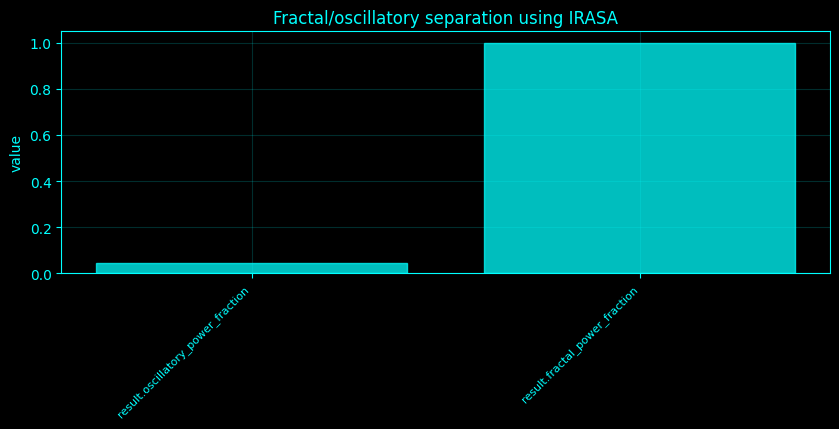

In [113]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_113():
    idx = 113
    name = 'Fractal/oscillatory separation using IRASA'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    f0, p0, fract, osc = _irasa_channel(0)
    return ({'fractal_power_fraction': float(np.trapz(fract, f0) / (np.trapz(p0, f0) + EPS)), 'oscillatory_power_fraction': float(np.trapz(osc, f0) / (np.trapz(p0, f0) + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_113,_plot_spec=_compute_method_113()
print('Fractal/oscillatory separation using IRASA')
if isinstance(result_113,dict):
    for _k,_v in result_113.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_113)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_113)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Fractal/oscillatory separation using IRASA',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Fractal/oscillatory separation using IRASA',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Fractal/oscillatory separation using IRASA',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">114. IRASA aperiodic exponent</h3>
<p>IRASA aperiodic exponent fits the log-log slope to the IRASA fractal component rather than the raw PSD.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [114]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_114():
    idx = 114
    name = 'IRASA aperiodic exponent'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    f0, p0, fract, osc = _irasa_channel(0)
    _, e, _ = _aperiodic_params(fract, f0)
    return ({'IRASA_aperiodic_exponent': e}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_114,_plot_spec=_compute_method_114()
print('IRASA aperiodic exponent')
if isinstance(result_114,dict):
    for _k,_v in result_114.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_114)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_114)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'IRASA aperiodic exponent',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'IRASA aperiodic exponent',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('IRASA aperiodic exponent',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


IRASA aperiodic exponent
  IRASA_aperiodic_exponent: 1.8079899424776507


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">115. IRASA oscillatory residual spectrum</h3>
<p>The IRASA oscillatory residual is \(P_{osc}(f)=\max[P_{raw}(f)-P_{fractal}(f),0]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [115]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_115():
    idx = 115
    name = 'IRASA oscillatory residual spectrum'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    f0, p0, fract, osc = _irasa_channel(0)
    m = (f0 >= 2) & (f0 <= 45)
    return ({'oscillatory_residual_area': float(np.trapz(osc[m], f0[m]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_115,_plot_spec=_compute_method_115()
print('IRASA oscillatory residual spectrum')
if isinstance(result_115,dict):
    for _k,_v in result_115.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_115)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_115)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'IRASA oscillatory residual spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'IRASA oscillatory residual spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('IRASA oscillatory residual spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


IRASA oscillatory residual spectrum
  oscillatory_residual_area: 0.0002843464801199265


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">116. IRASA bandpower correction</h3>
<p>IRASA bandpower correction integrates only \(P_{osc}(f)\) within each conventional band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


IRASA bandpower correction
  delta: 0.0001377300197991004
  theta: 5.789150473496021e-05
  alpha: 1.6787586843902662e-05
  beta: 2.4364792049937243e-05
  gamma: 6.0689488789386225e-05


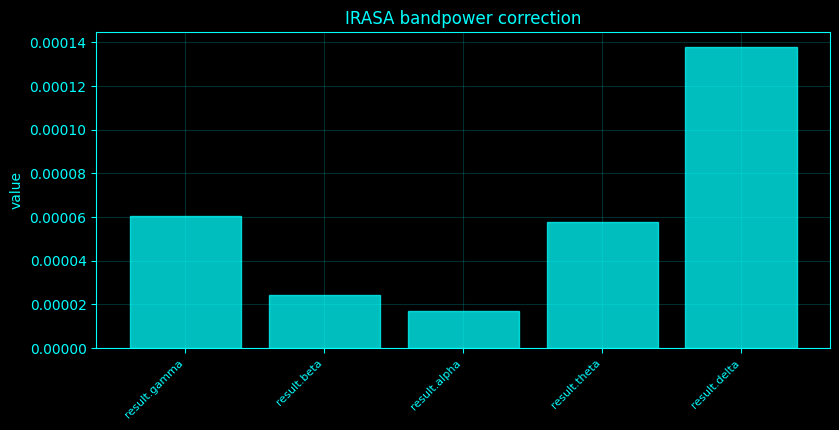

In [116]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_116():
    idx = 116
    name = 'IRASA bandpower correction'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    f0, p0, fract, osc = _irasa_channel(0)
    return ({bn: float(_band_integral(osc[:, None], f0, b)[0]) for bn, b in BANDS.items()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_116,_plot_spec=_compute_method_116()
print('IRASA bandpower correction')
if isinstance(result_116,dict):
    for _k,_v in result_116.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_116)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_116)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'IRASA bandpower correction',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'IRASA bandpower correction',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('IRASA bandpower correction',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">117. IRASA peak ranking</h3>
<p>IRASA peak ranking orders local maxima of the oscillatory residual by residual amplitude/prominence.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


IRASA peak ranking
  ranked_peaks_hz: array(5,), mean=2.63672


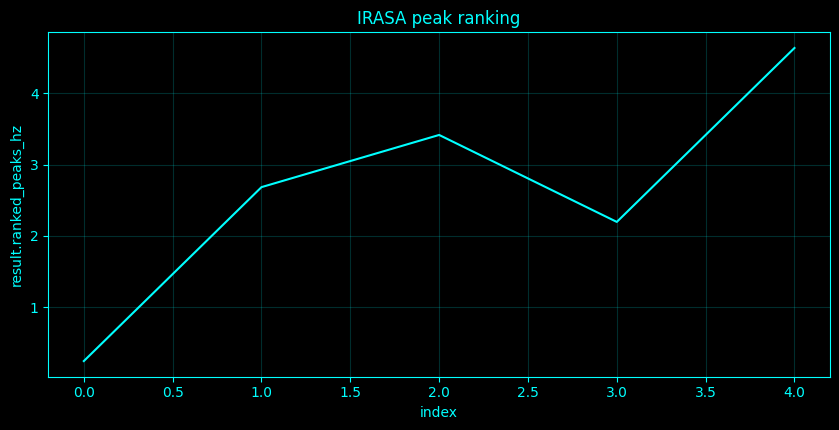

In [117]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_117():
    idx = 117
    name = 'IRASA peak ranking'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    f0, p0, fract, osc = _irasa_channel(0)
    pk, _ = signal.find_peaks(osc, prominence=max(np.std(osc) * 0.25, EPS))
    order = pk[np.argsort(osc[pk])[::-1]] if len(pk) else []
    return ({'ranked_peaks_hz': [float(f0[k]) for k in order[:8]]}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_117,_plot_spec=_compute_method_117()
print('IRASA peak ranking')
if isinstance(result_117,dict):
    for _k,_v in result_117.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_117)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_117)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'IRASA peak ranking',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'IRASA peak ranking',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('IRASA peak ranking',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">118. IRASA channel fingerprints</h3>
<p>IRASA channel fingerprints combine each channel's fractal exponent with oscillatory residual bandpower.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


IRASA channel fingerprints
  IRASA_fingerprints: array(8, 2), mean=0.772313


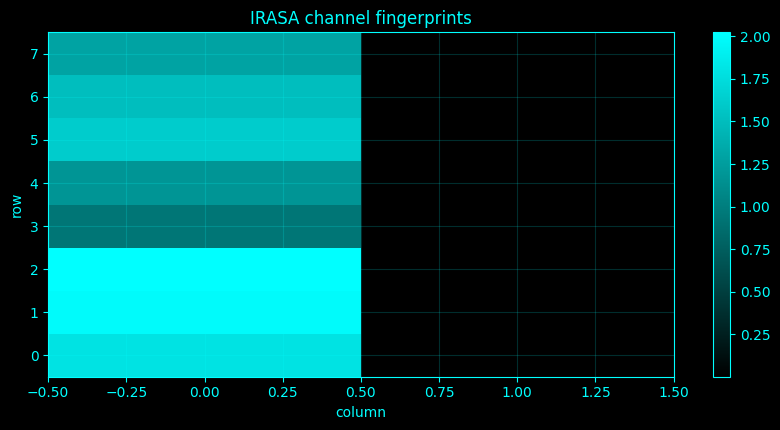

In [118]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_118():
    idx = 118
    name = 'IRASA channel fingerprints'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    f0, p0, fract, osc = _irasa_channel(0)
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        ff, pj, fj, oj = _irasa_channel(j)
        _, ej, _ = _aperiodic_params(fj, ff)
        rows.append([ej, float(_band_integral(oj[:, None], ff, BANDS['alpha'])[0])])
    return ({'IRASA_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_118,_plot_spec=_compute_method_118()
print('IRASA channel fingerprints')
if isinstance(result_118,dict):
    for _k,_v in result_118.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_118)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_118)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'IRASA channel fingerprints',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'IRASA channel fingerprints',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('IRASA channel fingerprints',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">119. IRASA time-resolved analysis</h3>
<p>Time-resolved IRASA is computationally expensive; this speed-aware implementation tracks windowed aperiodic fits and retains the full IRASA decomposition in the stationary cell.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


IRASA time-resolved analysis
  time_resolved_exponent_proxy: array(4,), mean=1.67928
  note: windowed aperiodic fits; full IRASA is used in the stationary cell


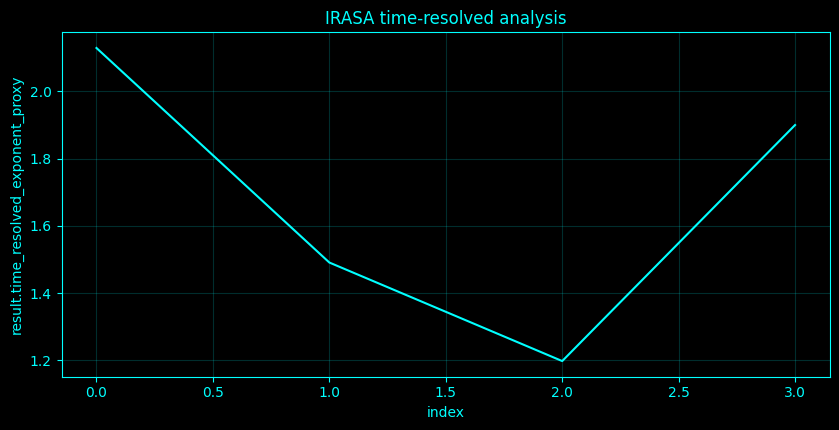

In [119]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

def _irasa_channel(ch=0):
    key = ('irasa', ch)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    y = X[:, ch]
    f0, p0 = _psd_of(y[:, None])
    p0 = p0[:, 0]
    hs = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
    geos = []
    from fractions import Fraction
    for h in hs:
        frac = Fraction(float(h)).limit_denominator(20)
        y1 = signal.resample_poly(y, frac.numerator, frac.denominator)
        y2 = signal.resample_poly(y, frac.denominator, frac.numerator)
        f1, p1 = signal.welch(y1, fs=_fs * h, nperseg=min(_SPEED['nperseg'], len(y1)))
        f2, p2 = signal.welch(y2, fs=_fs / h, nperseg=min(_SPEED['nperseg'], len(y2)))
        q1 = np.interp(f0, f1, p1)
        q2 = np.interp(f0, f2, p2)
        geos.append(np.sqrt(np.maximum(q1 * q2, 0)))
    fract = np.median(np.asarray(geos), axis=0)
    osc = np.maximum(p0 - fract, 0)
    SPEC_CACHE[key] = (f0, p0, fract, osc)
    return SPEC_CACHE[key]

# Method-specific calculation.
def _compute_method_119():
    idx = 119
    name = 'IRASA time-resolved analysis'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    off, expn, ap = _aperiodic_params(p, f)
    peaks, prom, res, ap = _peak_params(p, f)
    f0, p0, fract, osc = _irasa_channel(0)
    nwin = 4 if FAST_OPTION == 'ultra' else 8
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    vals = []
    for a, b in zip(edges[:-1], edges[1:]):
        yy = X[a:b, 0]
        ff, pp = _psd_of(yy[:, None])
        _, e, _ = _aperiodic_params(pp[:, 0], ff)
        vals.append(e)
    return ({'time_resolved_exponent_proxy': vals, 'note': 'windowed aperiodic fits; full IRASA is used in the stationary cell'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_119,_plot_spec=_compute_method_119()
print('IRASA time-resolved analysis')
if isinstance(result_119,dict):
    for _k,_v in result_119.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_119)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_119)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'IRASA time-resolved analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'IRASA time-resolved analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('IRASA time-resolved analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">120. Spectral parameterization across time windows</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Spectral parameterization across time windows
  aperiodic_exponent: array(48,), mean=1.12547
  theta_alpha_beta_gamma_peaks: array(48, 4), mean=17.0044


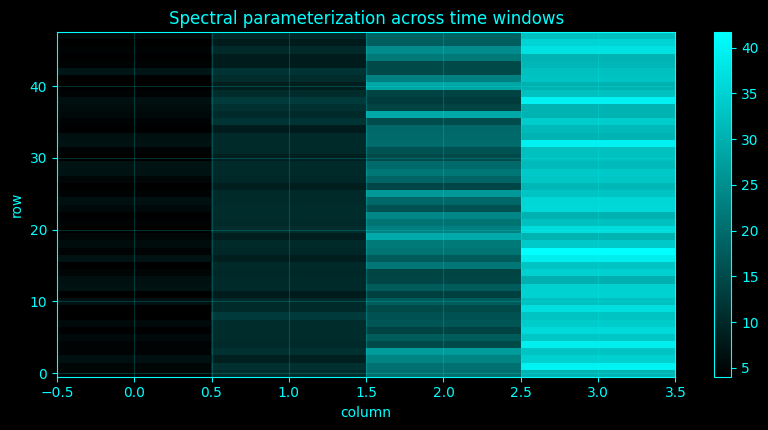

In [120]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_120():
    idx = 120
    name = 'Spectral parameterization across time windows'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    return ({'aperiodic_exponent': slopes, 'theta_alpha_beta_gamma_peaks': T}, locals().get('__plot_spec', None))
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_120,_plot_spec=_compute_method_120()
print('Spectral parameterization across time windows')
if isinstance(result_120,dict):
    for _k,_v in result_120.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_120)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_120)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral parameterization across time windows',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral parameterization across time windows',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral parameterization across time windows',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">121. Time-resolved aperiodic slope</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Time-resolved aperiodic slope
  aperiodic_exponent_trajectory: array(48,), mean=1.12547


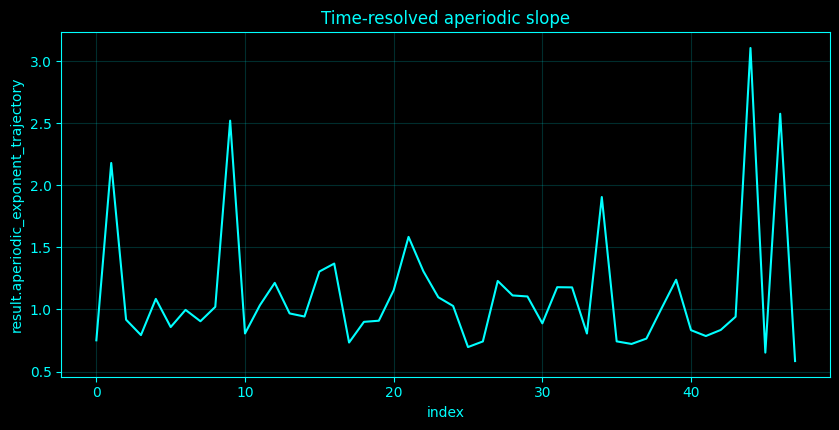

In [121]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_121():
    idx = 121
    name = 'Time-resolved aperiodic slope'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    return ({'aperiodic_exponent_trajectory': slopes}, locals().get('__plot_spec', None))
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_121,_plot_spec=_compute_method_121()
print('Time-resolved aperiodic slope')
if isinstance(result_121,dict):
    for _k,_v in result_121.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_121)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_121)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Time-resolved aperiodic slope',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Time-resolved aperiodic slope',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Time-resolved aperiodic slope',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">122. Time-resolved spectral peaks</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Time-resolved spectral peaks
  peak_trajectories_hz: array(48, 4), mean=17.0044


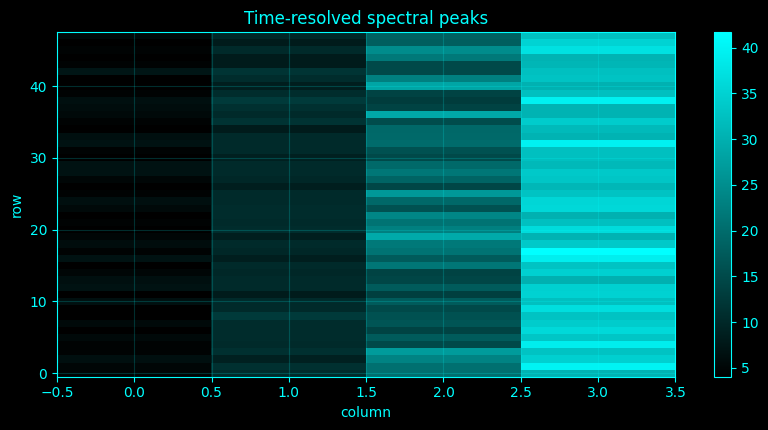

In [122]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_122():
    idx = 122
    name = 'Time-resolved spectral peaks'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    return ({'peak_trajectories_hz': T}, locals().get('__plot_spec', None))
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_122,_plot_spec=_compute_method_122()
print('Time-resolved spectral peaks')
if isinstance(result_122,dict):
    for _k,_v in result_122.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_122)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_122)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Time-resolved spectral peaks',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Time-resolved spectral peaks',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Time-resolved spectral peaks',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">123. Time-resolved alpha peak frequency</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Time-resolved alpha peak frequency
  alpha_peak_hz: array(48,), mean=10.1266


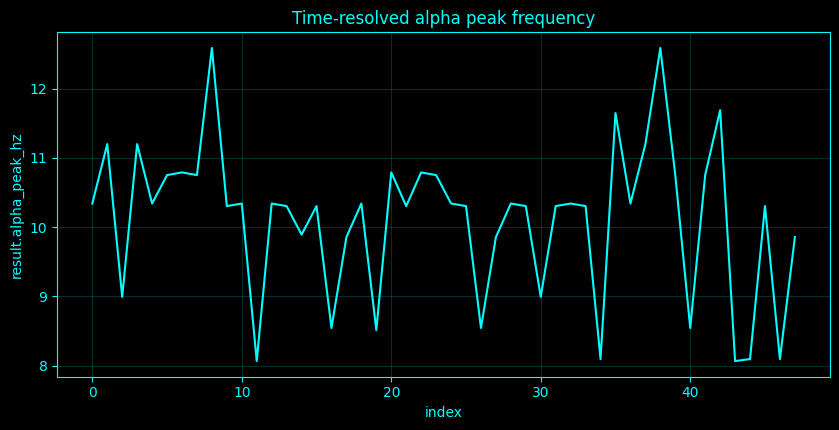

In [123]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_123():
    idx = 123
    name = 'Time-resolved alpha peak frequency'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    return ({'alpha_peak_hz': T[:, 1].tolist()}, locals().get('__plot_spec', None))
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_123,_plot_spec=_compute_method_123()
print('Time-resolved alpha peak frequency')
if isinstance(result_123,dict):
    for _k,_v in result_123.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_123)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_123)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Time-resolved alpha peak frequency',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Time-resolved alpha peak frequency',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Time-resolved alpha peak frequency',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">124. Time-resolved beta peak frequency</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Time-resolved beta peak frequency
  beta_peak_hz: array(48,), mean=19.0754


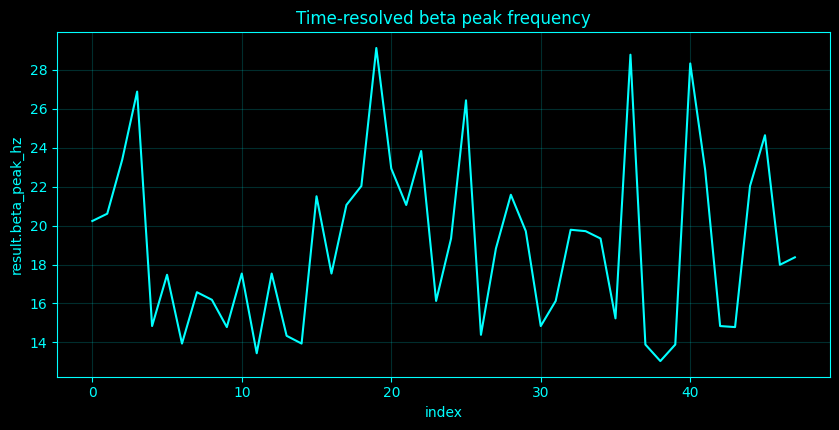

In [124]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_124():
    idx = 124
    name = 'Time-resolved beta peak frequency'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    return ({'beta_peak_hz': T[:, 2].tolist()}, locals().get('__plot_spec', None))
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_124,_plot_spec=_compute_method_124()
print('Time-resolved beta peak frequency')
if isinstance(result_124,dict):
    for _k,_v in result_124.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_124)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_124)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Time-resolved beta peak frequency',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Time-resolved beta peak frequency',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Time-resolved beta peak frequency',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">125. Time-resolved gamma peak frequency</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Time-resolved gamma peak frequency
  gamma_peak_hz: array(48,), mean=33.7564


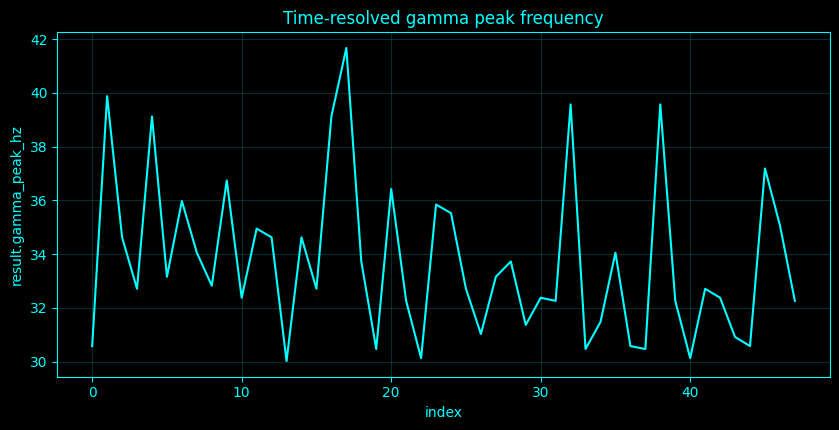

In [125]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_125():
    idx = 125
    name = 'Time-resolved gamma peak frequency'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    return ({'gamma_peak_hz': T[:, 3].tolist()}, locals().get('__plot_spec', None))
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_125,_plot_spec=_compute_method_125()
print('Time-resolved gamma peak frequency')
if isinstance(result_125,dict):
    for _k,_v in result_125.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_125)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_125)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Time-resolved gamma peak frequency',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Time-resolved gamma peak frequency',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Time-resolved gamma peak frequency',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">126. Peak-frequency trajectory analysis</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Peak-frequency trajectory analysis
  alpha_peak_trajectory: array(48,), mean=10.1266


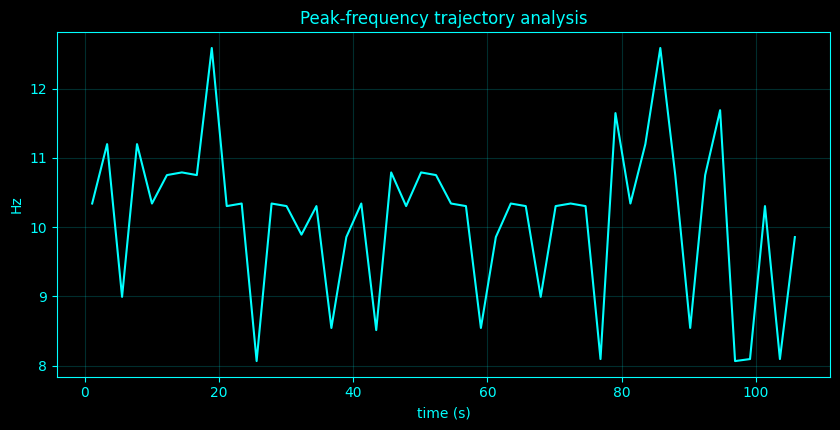

In [126]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_126():
    idx = 126
    name = 'Peak-frequency trajectory analysis'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    __plot_spec = ('summary', alpha, name, t[:len(alpha)], 'time (s)', 'Hz')
    return ({'alpha_peak_trajectory': alpha.tolist()}, locals().get('__plot_spec', None))
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_126,_plot_spec=_compute_method_126()
print('Peak-frequency trajectory analysis')
if isinstance(result_126,dict):
    for _k,_v in result_126.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_126)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_126)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Peak-frequency trajectory analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Peak-frequency trajectory analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Peak-frequency trajectory analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">127. Peak-frequency stability analysis</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Peak-frequency stability analysis
  alpha_peak_SD_hz: 1.1013629392526505
  MAD_hz: 0.44883448080245536


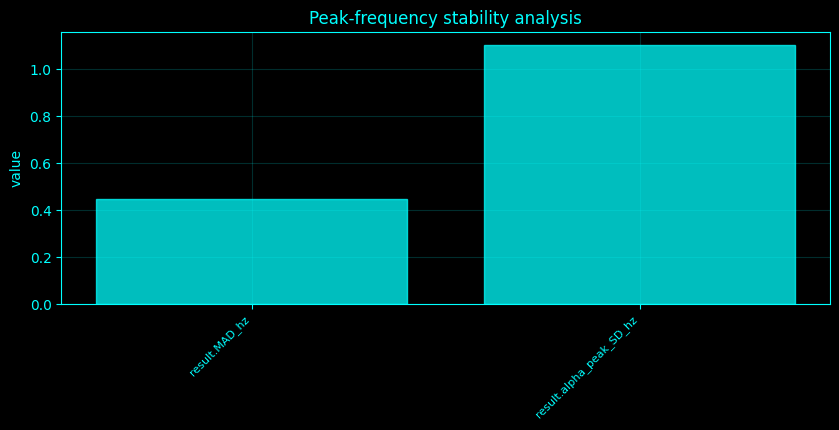

In [127]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_127():
    idx = 127
    name = 'Peak-frequency stability analysis'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    return ({'alpha_peak_SD_hz': float(np.nanstd(alpha)), 'MAD_hz': float(np.nanmedian(np.abs(alpha - np.nanmedian(alpha))))}, locals().get('__plot_spec', None))
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_127,_plot_spec=_compute_method_127()
print('Peak-frequency stability analysis')
if isinstance(result_127,dict):
    for _k,_v in result_127.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_127)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_127)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Peak-frequency stability analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Peak-frequency stability analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Peak-frequency stability analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">128. Peak-frequency drift velocity</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Peak-frequency drift velocity
  velocity_hz_per_s: array(48,), mean=0.00772322
  RMS: 0.3675919762265536


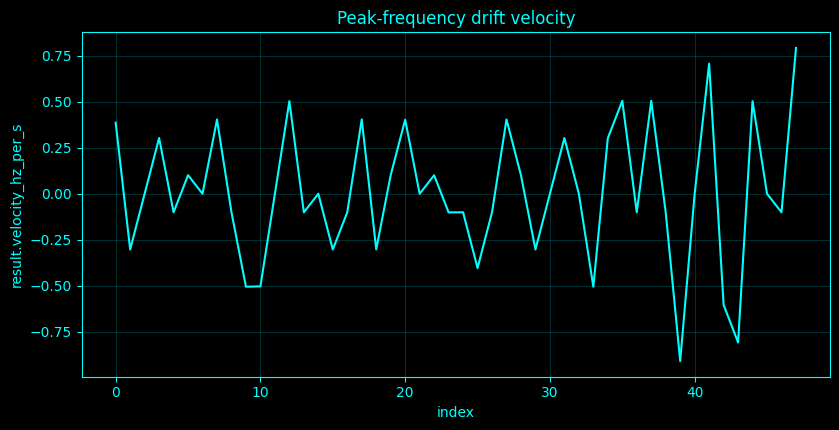

In [128]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_128():
    idx = 128
    name = 'Peak-frequency drift velocity'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    return ({'velocity_hz_per_s': v.tolist(), 'RMS': float(np.sqrt(np.nanmean(v * v)))}, locals().get('__plot_spec', None))
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_128,_plot_spec=_compute_method_128()
print('Peak-frequency drift velocity')
if isinstance(result_128,dict):
    for _k,_v in result_128.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_128)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_128)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Peak-frequency drift velocity',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Peak-frequency drift velocity',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Peak-frequency drift velocity',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">129. Peak-frequency acceleration</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Peak-frequency acceleration
  acceleration_hz_per_s2: array(48,), mean=0.00474648
  RMS: 0.15639803784952516


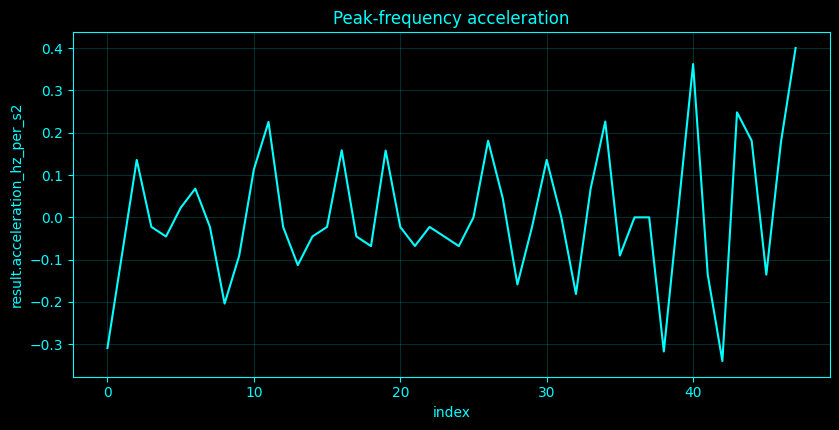

In [129]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_129():
    idx = 129
    name = 'Peak-frequency acceleration'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    return ({'acceleration_hz_per_s2': acc.tolist(), 'RMS': float(np.sqrt(np.nanmean(acc * acc)))}, locals().get('__plot_spec', None))
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_129,_plot_spec=_compute_method_129()
print('Peak-frequency acceleration')
if isinstance(result_129,dict):
    for _k,_v in result_129.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_129)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_129)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Peak-frequency acceleration',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Peak-frequency acceleration',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Peak-frequency acceleration',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">130. Peak-frequency change-point detection</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Peak-frequency change-point detection
  change_times_s: array(6,), mean=49.3853
  threshold_hz: 2.277210489672777


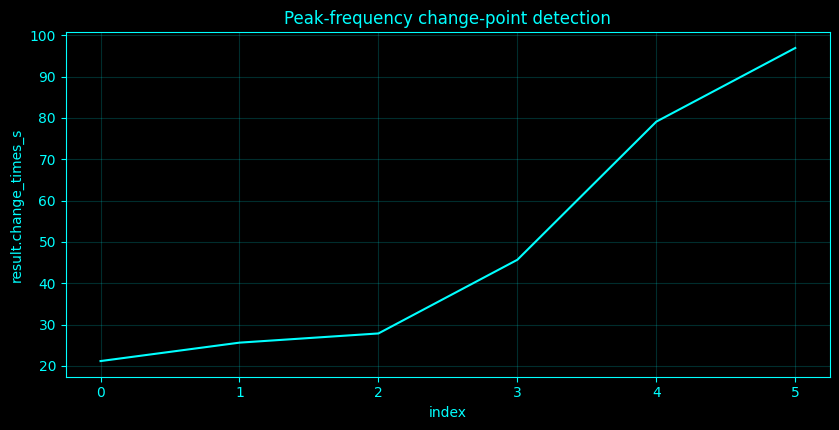

In [130]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_130():
    idx = 130
    name = 'Peak-frequency change-point detection'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    d = np.abs(np.diff(alpha, prepend=alpha[0]))
    th = np.nanquantile(d, 0.9)
    return ({'change_times_s': t[d >= th].tolist(), 'threshold_hz': float(th)}, locals().get('__plot_spec', None))
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_130,_plot_spec=_compute_method_130()
print('Peak-frequency change-point detection')
if isinstance(result_130,dict):
    for _k,_v in result_130.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_130)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_130)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Peak-frequency change-point detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Peak-frequency change-point detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Peak-frequency change-point detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">131. Event-locked spectral peak shifts</h3>
<p>Windowed spectral parameterization repeats PSD fitting and band peak extraction over time. Peak trajectories \(f_p(t)\) support stability, velocity \(df_p/dt\), acceleration \(d^2f_p/dt^2\), and finite-difference change-point diagnostics. Event-locked variants compare pre/post windows and explicitly distinguish supplied events from internal demonstration events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [131]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

# Method-specific calculation.
def _compute_method_131():
    idx = 131
    name = 'Event-locked spectral peak shifts'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    ev = _event_indices()
    pre = []
    post = []
    half = int(0.75 * _fs)
    for e in ev:
        if e - half >= 0 and e + half < N:
            for arr, sl in [(pre, slice(e - half, e)), (post, slice(e, e + half))]:
                ff, pp = _psd_of(X[sl, 0, None])
                m = (ff >= 8) & (ff < 13)
                arr.append(float(ff[m][np.argmax(pp[m, 0])]) if np.any(m) else np.nan)
    return ({'mean_post_minus_pre_alpha_peak_hz': float(np.nanmean(post) - np.nanmean(pre)) if pre and post else np.nan, 'events': 'supplied' if 'SPECTRAL_EVENT_INDICES' in globals() else 'internal amplitude-event demonstration'}, locals().get('__plot_spec', None))
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_131,_plot_spec=_compute_method_131()
print('Event-locked spectral peak shifts')
if isinstance(result_131,dict):
    for _k,_v in result_131.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_131)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_131)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Event-locked spectral peak shifts',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Event-locked spectral peak shifts',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Event-locked spectral peak shifts',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Event-locked spectral peak shifts
  mean_post_minus_pre_alpha_peak_hz: nan
  events: internal amplitude-event demonstration


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">132. Individual alpha frequency analysis</h3>
<p>Individual rhythm frequency is the frequency of maximum PSD within the predefined alpha (7–13 Hz) search interval, estimated separately for each channel.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Individual alpha frequency analysis
  IAF_by_channel: array(12,), mean=9.60286
  mean: 9.602864583333334


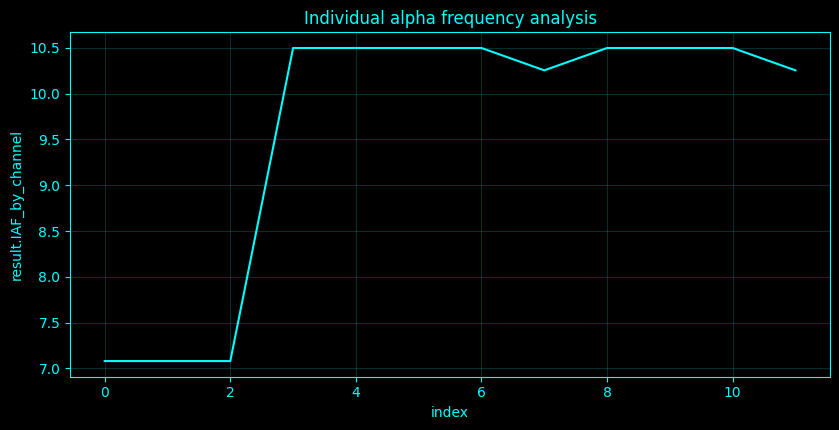

In [132]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_132():
    idx = 132
    name = 'Individual alpha frequency analysis'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    vals = [channel_peak(j, (7, 13)) for j in range(C)]
    return ({'IAF_by_channel': vals, 'mean': float(np.nanmean(vals))}, locals().get('__plot_spec', None))
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_132,_plot_spec=_compute_method_132()
print('Individual alpha frequency analysis')
if isinstance(result_132,dict):
    for _k,_v in result_132.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_132)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_132)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Individual alpha frequency analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Individual alpha frequency analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Individual alpha frequency analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">133. Individual beta frequency analysis</h3>
<p>Individual rhythm frequency is the frequency of maximum PSD within the predefined beta (13–30 Hz) search interval, estimated separately for each channel.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Individual beta frequency analysis
  IBF_by_channel: array(12,), mean=15.6047


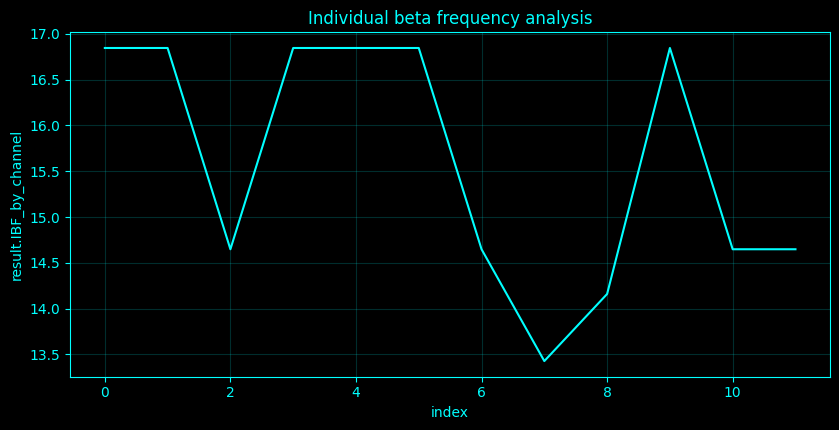

In [133]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_133():
    idx = 133
    name = 'Individual beta frequency analysis'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    return ({'IBF_by_channel': [channel_peak(j, (13, 30)) for j in range(C)]}, locals().get('__plot_spec', None))
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_133,_plot_spec=_compute_method_133()
print('Individual beta frequency analysis')
if isinstance(result_133,dict):
    for _k,_v in result_133.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_133)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_133)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Individual beta frequency analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Individual beta frequency analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Individual beta frequency analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">134. Individual theta frequency analysis</h3>
<p>Individual rhythm frequency is the frequency of maximum PSD within the predefined theta (4–8 Hz) search interval, estimated separately for each channel.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Individual theta frequency analysis
  ITF_by_channel: array(12,), mean=4.37419


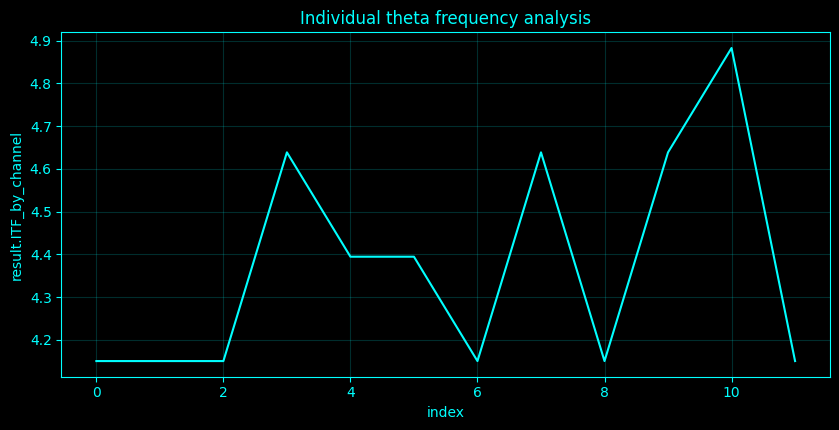

In [134]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_134():
    idx = 134
    name = 'Individual theta frequency analysis'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    return ({'ITF_by_channel': [channel_peak(j, (4, 8)) for j in range(C)]}, locals().get('__plot_spec', None))
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_134,_plot_spec=_compute_method_134()
print('Individual theta frequency analysis')
if isinstance(result_134,dict):
    for _k,_v in result_134.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_134)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_134)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Individual theta frequency analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Individual theta frequency analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Individual theta frequency analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">135. Alpha slowing index</h3>
<p>Alpha slowing is represented explicitly here by lower-alpha to upper-alpha power, \(P_{7-9}/P_{10-13}\); larger values indicate relatively more low-alpha energy.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Alpha slowing index
  lower_to_upper_alpha_power: array(12,), mean=0.495666


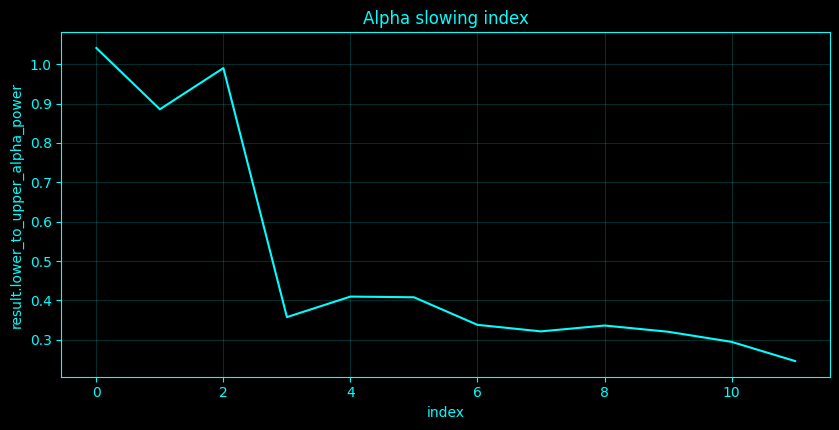

In [135]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_135():
    idx = 135
    name = 'Alpha slowing index'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    lower = _band_integral(P, f, (7, 9))
    upper = _band_integral(P, f, (10, 13))
    return ({'lower_to_upper_alpha_power': (lower / (upper + EPS)).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_135,_plot_spec=_compute_method_135()
print('Alpha slowing index')
if isinstance(result_135,dict):
    for _k,_v in result_135.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_135)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_135)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Alpha slowing index',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Alpha slowing index',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Alpha slowing index',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">136. Theta/alpha ratio</h3>
<p>This spectral ratio is \(P_\theta/P_\alpha\), computed from integrated Welch bandpowers with a small numerical denominator floor.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Theta/alpha ratio
  theta_alpha_ratio: array(12,), mean=1.4846


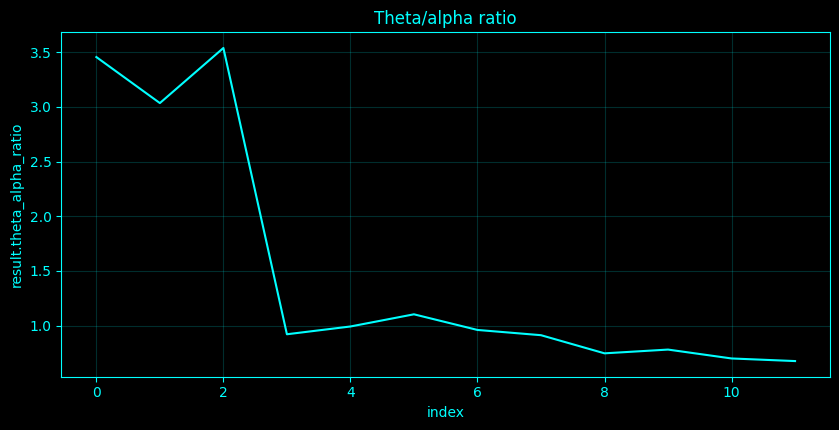

In [136]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_136():
    idx = 136
    name = 'Theta/alpha ratio'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    return ({'theta_alpha_ratio': (BP[:, bi['theta']] / (BP[:, bi['alpha']] + EPS)).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_136,_plot_spec=_compute_method_136()
print('Theta/alpha ratio')
if isinstance(result_136,dict):
    for _k,_v in result_136.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_136)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_136)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Theta/alpha ratio',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Theta/alpha ratio',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Theta/alpha ratio',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">137. Beta/alpha ratio</h3>
<p>This spectral ratio is \(P_\beta/P_\alpha\), computed from integrated Welch bandpowers with a small numerical denominator floor.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Beta/alpha ratio
  beta_alpha_ratio: array(12,), mean=0.903116


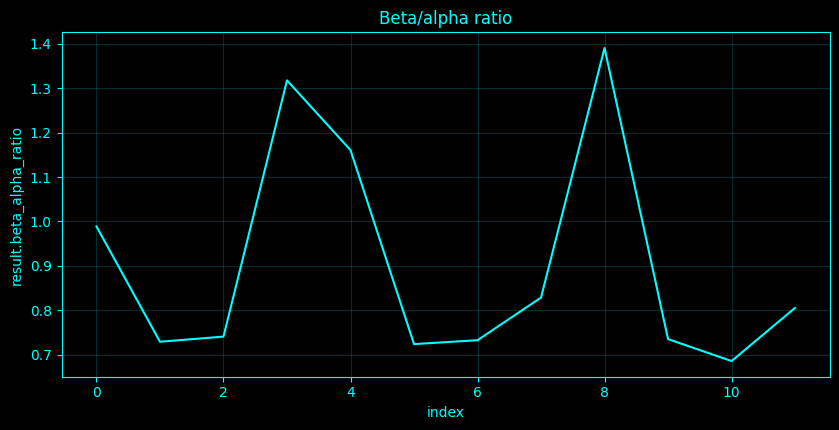

In [137]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_137():
    idx = 137
    name = 'Beta/alpha ratio'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    return ({'beta_alpha_ratio': (BP[:, bi['beta']] / (BP[:, bi['alpha']] + EPS)).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_137,_plot_spec=_compute_method_137()
print('Beta/alpha ratio')
if isinstance(result_137,dict):
    for _k,_v in result_137.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_137)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_137)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Beta/alpha ratio',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Beta/alpha ratio',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Beta/alpha ratio',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">138. Theta/beta ratio</h3>
<p>This spectral ratio is \(P_\theta/P_\beta\), computed from integrated Welch bandpowers with a small numerical denominator floor.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Theta/beta ratio
  theta_beta_ratio: array(12,), mean=1.78169


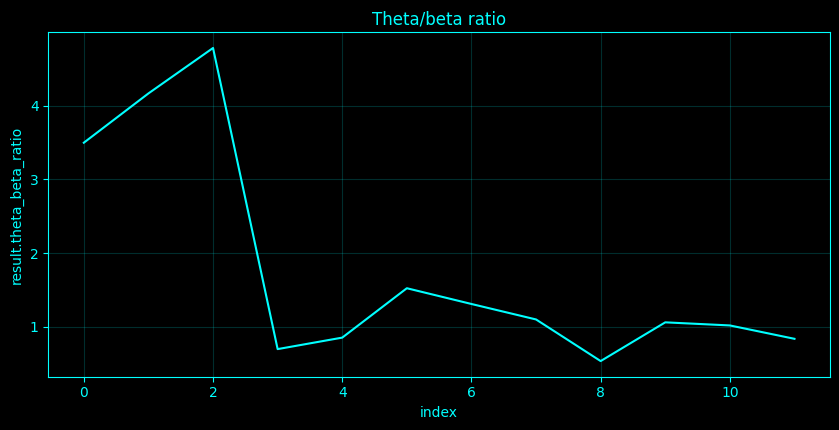

In [138]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_138():
    idx = 138
    name = 'Theta/beta ratio'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    return ({'theta_beta_ratio': (BP[:, bi['theta']] / (BP[:, bi['beta']] + EPS)).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_138,_plot_spec=_compute_method_138()
print('Theta/beta ratio')
if isinstance(result_138,dict):
    for _k,_v in result_138.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_138)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_138)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Theta/beta ratio',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Theta/beta ratio',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Theta/beta ratio',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">139. Delta/alpha ratio</h3>
<p>This spectral ratio is \(P_\delta/P_\alpha\), computed from integrated Welch bandpowers with a small numerical denominator floor.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Delta/alpha ratio
  delta_alpha_ratio: array(12,), mean=4.47538


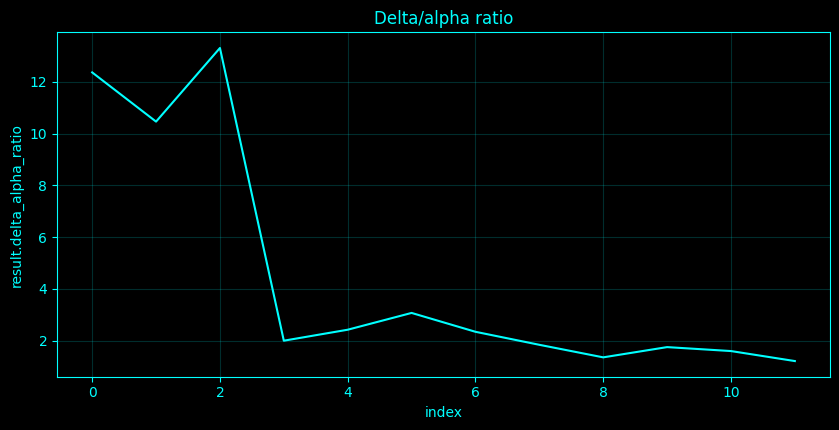

In [139]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_139():
    idx = 139
    name = 'Delta/alpha ratio'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    return ({'delta_alpha_ratio': (BP[:, bi['delta']] / (BP[:, bi['alpha']] + EPS)).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_139,_plot_spec=_compute_method_139()
print('Delta/alpha ratio')
if isinstance(result_139,dict):
    for _k,_v in result_139.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_139)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_139)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Delta/alpha ratio',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Delta/alpha ratio',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Delta/alpha ratio',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">140. Alpha reactivity index</h3>
<p>True alpha reactivity requires labeled conditions such as eyes open/closed. With one unlabeled continuous segment, this cell reports only an internal high-versus-low alpha-envelope state contrast and labels it as a proxy.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [140]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_140():
    idx = 140
    name = 'Alpha reactivity index'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    lo = env <= np.quantile(env, 0.25)
    hi = env >= np.quantile(env, 0.75)
    return ({'internal_alpha_state_reactivity_proxy': float((np.mean(env[hi]) - np.mean(env[lo])) / (np.mean(env[lo]) + EPS)), 'note': 'not physiological eyes-open/closed reactivity without condition labels'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_140,_plot_spec=_compute_method_140()
print('Alpha reactivity index')
if isinstance(result_140,dict):
    for _k,_v in result_140.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_140)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_140)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Alpha reactivity index',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Alpha reactivity index',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Alpha reactivity index',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Alpha reactivity index
  internal_alpha_state_reactivity_proxy: 5.9245096889183895
  note: not physiological eyes-open/closed reactivity without condition labels


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">141. Posterior dominant rhythm stability</h3>
<p>Posterior dominant-rhythm stability tracks the 7–13-Hz peak of a posterior sensor average across windows and reports its temporal dispersion.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [141]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_141():
    idx = 141
    name = 'Posterior dominant rhythm stability'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    post = [CH_NAMES.index(ch) for ch in ROI['posterior'] if ch in CH_NAMES]
    if not post:
        return ({'status': 'posterior channels unavailable'}, locals().get('__plot_spec', None))
    yy = np.mean(X[:, post], axis=1)
    vals = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(yy[a:b, None])
        m = (ff >= 7) & (ff < 13)
        vals.append(float(ff[m][np.argmax(pp[m, 0])]))
    return ({'posterior_dominant_rhythm_SD_hz': float(np.std(vals))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_141,_plot_spec=_compute_method_141()
print('Posterior dominant rhythm stability')
if isinstance(result_141,dict):
    for _k,_v in result_141.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_141)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_141)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Posterior dominant rhythm stability',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Posterior dominant rhythm stability',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Posterior dominant rhythm stability',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Posterior dominant rhythm stability
  status: posterior channels unavailable


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">142. Peak alpha bandwidth</h3>
<p>Alpha-peak morphology is measured on the aperiodic-corrected 7–13-Hz residual: half-prominence bandwidth, prominence, number/separation of peaks, and double-peak detection are distinct descriptors.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [142]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

# Method-specific calculation.
def _compute_method_142():
    idx = 142
    name = 'Peak alpha bandwidth'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    p = np.mean(P, axis=1)
    _, _, res, ap = _peak_params(p, f, (7, 13))
    m = (f >= 7) & (f < 13)
    rr = res[m]
    pk, props = signal.find_peaks(rr, prominence=max(0.01, np.std(rr) * 0.25))
    if not len(pk):
        return ({'alpha_bandwidth_hz': np.nan}, locals().get('__plot_spec', None))
    k = pk[np.argmax(props['prominences'])]
    w = signal.peak_widths(rr, [k], rel_height=0.5)[0][0] * np.median(np.diff(f))
    return ({'alpha_bandwidth_hz': float(w)}, locals().get('__plot_spec', None))
    fi = f[m][pk] if len(pk) else np.array([])
    return ({'double_alpha_detected': bool(len(fi) >= 2 and np.max(fi) - np.min(fi) >= 1.0), 'peaks_hz': fi.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_142,_plot_spec=_compute_method_142()
print('Peak alpha bandwidth')
if isinstance(result_142,dict):
    for _k,_v in result_142.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_142)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_142)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Peak alpha bandwidth',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Peak alpha bandwidth',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Peak alpha bandwidth',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Peak alpha bandwidth
  alpha_bandwidth_hz: 1.3913324324323755


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">143. Alpha peak prominence</h3>
<p>Alpha-peak morphology is measured on the aperiodic-corrected 7–13-Hz residual: half-prominence bandwidth, prominence, number/separation of peaks, and double-peak detection are distinct descriptors.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [143]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

# Method-specific calculation.
def _compute_method_143():
    idx = 143
    name = 'Alpha peak prominence'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    p = np.mean(P, axis=1)
    _, _, res, ap = _peak_params(p, f, (7, 13))
    m = (f >= 7) & (f < 13)
    rr = res[m]
    pk, props = signal.find_peaks(rr, prominence=max(0.01, np.std(rr) * 0.25))
    return ({'alpha_peak_prominence': float(np.max(props['prominences'])) if len(pk) else np.nan}, locals().get('__plot_spec', None))
    fi = f[m][pk] if len(pk) else np.array([])
    return ({'double_alpha_detected': bool(len(fi) >= 2 and np.max(fi) - np.min(fi) >= 1.0), 'peaks_hz': fi.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_143,_plot_spec=_compute_method_143()
print('Alpha peak prominence')
if isinstance(result_143,dict):
    for _k,_v in result_143.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_143)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_143)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Alpha peak prominence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Alpha peak prominence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Alpha peak prominence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Alpha peak prominence
  alpha_peak_prominence: 0.6963329011439954


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">144. Alpha peak splitting</h3>
<p>Alpha-peak morphology is measured on the aperiodic-corrected 7–13-Hz residual: half-prominence bandwidth, prominence, number/separation of peaks, and double-peak detection are distinct descriptors.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Alpha peak splitting
  alpha_peak_count: 2
  splitting_hz: 2.44140625


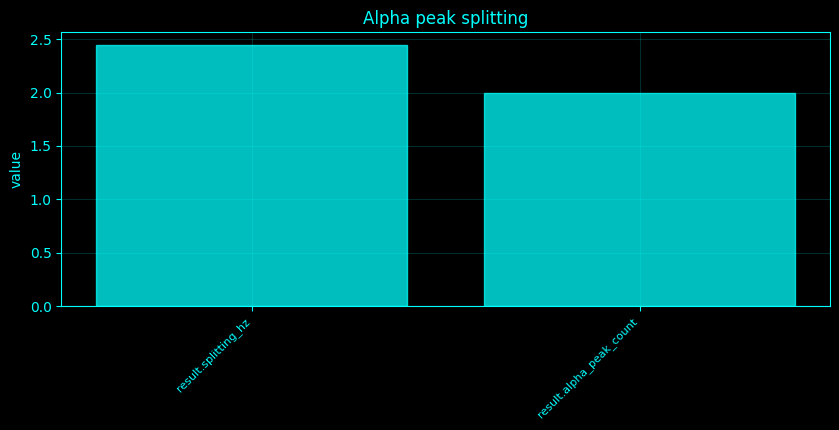

In [144]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

# Method-specific calculation.
def _compute_method_144():
    idx = 144
    name = 'Alpha peak splitting'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    p = np.mean(P, axis=1)
    _, _, res, ap = _peak_params(p, f, (7, 13))
    m = (f >= 7) & (f < 13)
    rr = res[m]
    pk, props = signal.find_peaks(rr, prominence=max(0.01, np.std(rr) * 0.25))
    fi = f[m][pk] if len(pk) else np.array([])
    return ({'alpha_peak_count': int(len(fi)), 'splitting_hz': float(np.max(fi) - np.min(fi)) if len(fi) >= 2 else 0.0}, locals().get('__plot_spec', None))
    return ({'double_alpha_detected': bool(len(fi) >= 2 and np.max(fi) - np.min(fi) >= 1.0), 'peaks_hz': fi.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_144,_plot_spec=_compute_method_144()
print('Alpha peak splitting')
if isinstance(result_144,dict):
    for _k,_v in result_144.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_144)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_144)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Alpha peak splitting',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Alpha peak splitting',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Alpha peak splitting',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">145. Double-alpha peak detection</h3>
<p>Alpha-peak morphology is measured on the aperiodic-corrected 7–13-Hz residual: half-prominence bandwidth, prominence, number/separation of peaks, and double-peak detection are distinct descriptors.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Double-alpha peak detection
  double_alpha_detected: True
  peaks_hz: array(2,), mean=9.27734


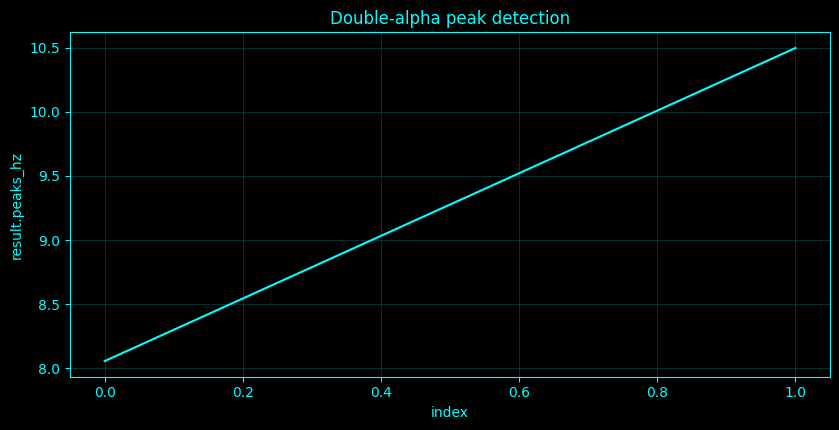

In [145]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

def _peak_params(psd=None, f=None, band=(4, 30)):
    if f is None or psd is None:
        f, P = _welch_all()
        psd = np.mean(P, axis=1)
    _, _, ap = _aperiodic_params(psd, f)
    res = np.log10(psd + EPS) - np.log10(ap + EPS)
    m = (f >= band[0]) & (f <= band[1])
    peaks, props = signal.find_peaks(res[m], prominence=max(0.02, np.std(res[m]) * 0.3))
    fi = f[m][peaks]
    prom = props.get('prominences', np.array([]))
    return (fi, prom, res, ap)

# Method-specific calculation.
def _compute_method_145():
    idx = 145
    name = 'Double-alpha peak detection'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    p = np.mean(P, axis=1)
    _, _, res, ap = _peak_params(p, f, (7, 13))
    m = (f >= 7) & (f < 13)
    rr = res[m]
    pk, props = signal.find_peaks(rr, prominence=max(0.01, np.std(rr) * 0.25))
    fi = f[m][pk] if len(pk) else np.array([])
    return ({'double_alpha_detected': bool(len(fi) >= 2 and np.max(fi) - np.min(fi) >= 1.0), 'peaks_hz': fi.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_145,_plot_spec=_compute_method_145()
print('Double-alpha peak detection')
if isinstance(result_145,dict):
    for _k,_v in result_145.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_145)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_145)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Double-alpha peak detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Double-alpha peak detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Double-alpha peak detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">146. Regional alpha frequency gradients</h3>
<p>Regional alpha-frequency gradient is the least-squares slope of channel alpha-peak frequency versus anterior-posterior electrode coordinate.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [146]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_146():
    idx = 146
    name = 'Regional alpha frequency gradients'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    vals = np.array([channel_peak(j, (7, 13)) for j in range(C)])
    ycoord = np.array([ELECTRODE_XY.get(ch, (0, 0))[1] for ch in CH_NAMES])
    return ({'posterior_anterior_IAF_gradient_hz_per_unit': float(np.polyfit(ycoord, vals, 1)[0])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_146,_plot_spec=_compute_method_146()
print('Regional alpha frequency gradients')
if isinstance(result_146,dict):
    for _k,_v in result_146.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_146)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_146)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Regional alpha frequency gradients',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Regional alpha frequency gradients',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Regional alpha frequency gradients',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Regional alpha frequency gradients
  posterior_anterior_IAF_gradient_hz_per_unit: -4.4336218872196005


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">147. Left-right alpha frequency asymmetry</h3>
<p>Left-right alpha-frequency asymmetry is the difference in alpha peak frequency between homologous sensor pairs.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Left-right alpha frequency asymmetry
  left_minus_right_IAF_hz: array(2,), mean=0
  mean: 0.0


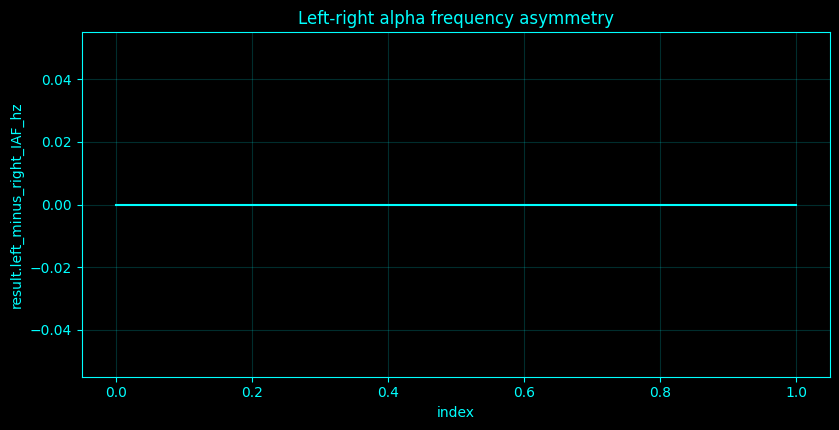

In [147]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_147():
    idx = 147
    name = 'Left-right alpha frequency asymmetry'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    pairs = [('Fp1', 'Fp2'), ('F3', 'F4'), ('C3', 'C4'), ('P3', 'P4'), ('O1', 'O2')]
    d = []
    for l, r in pairs:
        if l in CH_NAMES and r in CH_NAMES:
            d.append(channel_peak(CH_NAMES.index(l), (7, 13)) - channel_peak(CH_NAMES.index(r), (7, 13)))
    return ({'left_minus_right_IAF_hz': d, 'mean': float(np.mean(d)) if d else np.nan}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_147,_plot_spec=_compute_method_147()
print('Left-right alpha frequency asymmetry')
if isinstance(result_147,dict):
    for _k,_v in result_147.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_147)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_147)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Left-right alpha frequency asymmetry',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Left-right alpha frequency asymmetry',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Left-right alpha frequency asymmetry',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">148. Spectral edge frequency trajectories</h3>
<p>Spectral edge frequency SEF95 is the frequency below which 95% of in-band power accumulates; the cell tracks this quantity across windows.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Spectral edge frequency trajectories
  SEF95_trajectory_hz: array(48,), mean=33.5593


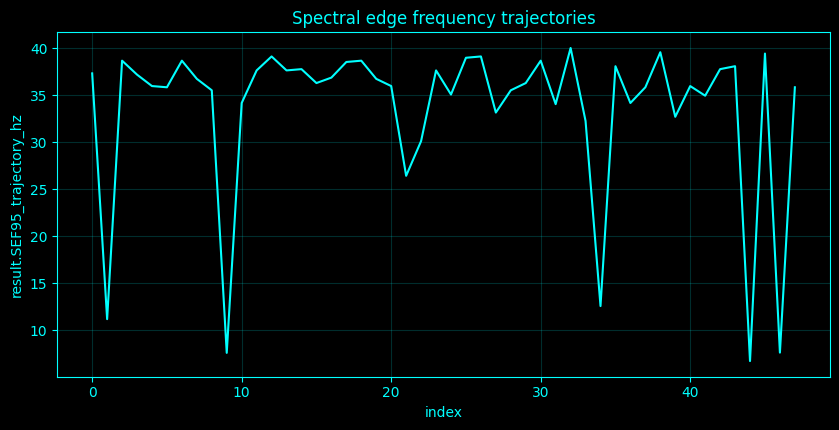

In [148]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _window_bandpower():
    if 'window_bandpower' in SPEC_CACHE:
        return SPEC_CACHE['window_bandpower']
    nwin = min(_SPEED['n_windows'], max(8, N // max(64, int(_fs))))
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    rows = []
    for a, b in zip(edges[:-1], edges[1:]):
        xx = X[a:b]
        if len(xx) < 16:
            continue
        nw = min(max(32, len(xx) // 2), int(_SPEED['nperseg']), len(xx))
        f, p = signal.welch(xx, fs=_fs, axis=0, nperseg=nw, noverlap=nw // 2)
        rows.append(np.stack([_band_integral(p, f, bb) for bb in BANDS.values()], axis=1))
    W = np.stack(rows, axis=0)
    t = (edges[:-1][:len(rows)] + edges[1:1 + len(rows)]) / (2 * _fs)
    SPEC_CACHE['window_bandpower'] = (t, W)
    return SPEC_CACHE['window_bandpower']

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _aperiodic_params(psd=None, f=None):
    if f is None or psd is None:
        f, Pa = _welch_all()
        psd = np.mean(Pa, axis=1)
    m = (f >= 2) & (f <= 45)
    x = np.log10(f[m])
    y = np.log10(psd[m] + EPS)
    coef = np.polyfit(x, y, 1)
    offset, exponent = (float(coef[1]), float(-coef[0]))
    fit = 10 ** (offset - exponent * np.log10(f + EPS))
    return (offset, exponent, fit)

# Method-specific calculation.
def _compute_method_148():
    idx = 148
    name = 'Spectral edge frequency trajectories'
    __plot_spec = None
    t, W = _window_bandpower()
    nwin = len(t)
    edges = np.linspace(0, N, nwin + 1, dtype=int)
    trajectories = []
    slopes = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]], nperseg=min(_SPEED['nperseg'], b - a))
        p0 = pp[:, 0]
        _, e, _ = _aperiodic_params(p0, ff)
        slopes.append(e)

        def peak_band(band):
            m = (ff >= band[0]) & (ff < min(band[1], 0.49 * _fs))
            return float(ff[m][np.argmax(p0[m])]) if np.any(m) else np.nan
        trajectories.append([peak_band(BANDS['theta']), peak_band(BANDS['alpha']), peak_band(BANDS['beta']), peak_band(BANDS['gamma'])])
    T = np.asarray(trajectories)
    alpha = T[:, 1]
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1.0
    v = np.gradient(alpha, dt)
    acc = np.gradient(v, dt)
    f, P = _welch_all()

    def channel_peak(j, band):
        m = (f >= band[0]) & (f < min(band[1], 0.49 * _fs))
        return float(f[m][np.argmax(P[m, j])]) if np.any(m) else np.nan
    _, BP = _bandpower_matrix()
    bi = {k: i for i, k in enumerate(BANDS)}
    vals = []
    for a, b in zip(edges[:-1], edges[1:]):
        ff, pp = _psd_of(X[a:b, [0]])
        q = pp[:, 0]
        mask = (ff >= 1) & (ff <= 45)
        cdf = np.cumsum(q[mask])
        cdf /= cdf[-1] + EPS
        vals.append(float(ff[mask][np.searchsorted(cdf, 0.95)]))
    return ({'SEF95_trajectory_hz': vals}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_148,_plot_spec=_compute_method_148()
print('Spectral edge frequency trajectories')
if isinstance(result_148,dict):
    for _k,_v in result_148.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_148)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_148)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral edge frequency trajectories',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral edge frequency trajectories',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral edge frequency trajectories',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">149. Median frequency</h3>
<p>Median frequency \(f_{50}\) satisfies \(\int^{f_{50}}P(f)df=0.5\int P(f)df\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [149]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_149():
    idx = 149
    name = 'Median frequency'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    return ({'median_frequency_hz': float(ff[np.searchsorted(cdf, 0.5)])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_149,_plot_spec=_compute_method_149()
print('Median frequency')
if isinstance(result_149,dict):
    for _k,_v in result_149.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_149)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_149)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Median frequency',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Median frequency',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Median frequency',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Median frequency
  median_frequency_hz: 5.126953125


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">150. Mean frequency</h3>
<p>Mean frequency is the first spectral moment \(\mu_f=\int fP(f)df/\int P(f)df\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [150]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_150():
    idx = 150
    name = 'Mean frequency'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    return ({'mean_frequency_hz': mean}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_150,_plot_spec=_compute_method_150()
print('Mean frequency')
if isinstance(result_150,dict):
    for _k,_v in result_150.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_150)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_150)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Mean frequency',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Mean frequency',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Mean frequency',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Mean frequency
  mean_frequency_hz: 10.123076994109894


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">151. Spectral bandwidth</h3>
<p>Occupied spectral bandwidth is defined here as \(f_{95}-f_{05}\), the central 90% power interval.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral bandwidth
  occupied_90_percent_bandwidth_hz: 32.958984375
  low: 1.220703125
  high: 34.1796875


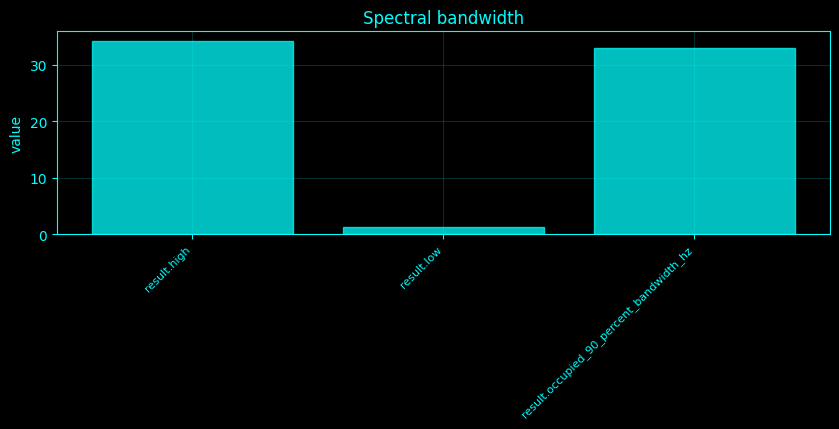

In [151]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_151():
    idx = 151
    name = 'Spectral bandwidth'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    lo = float(ff[np.searchsorted(cdf, 0.05)])
    hi = float(ff[np.searchsorted(cdf, 0.95)])
    return ({'occupied_90_percent_bandwidth_hz': hi - lo, 'low': lo, 'high': hi}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_151,_plot_spec=_compute_method_151()
print('Spectral bandwidth')
if isinstance(result_151,dict):
    for _k,_v in result_151.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_151)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_151)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral bandwidth',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral bandwidth',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral bandwidth',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">152. Spectral spread</h3>
<p>Spectral spread is the RMS deviation from mean frequency, \(\sigma_f=[\int(f-\mu_f)^2p(f)df]^{1/2}\), distinct from occupied bandwidth.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [152]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_152():
    idx = 152
    name = 'Spectral spread'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    return ({'spectral_spread_hz': float(sd)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_152,_plot_spec=_compute_method_152()
print('Spectral spread')
if isinstance(result_152,dict):
    for _k,_v in result_152.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_152)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_152)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral spread',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral spread',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral spread',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral spread
  spectral_spread_hz: 10.482633792431287


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">153. Spectral skewness</h3>
<p>Spectral skewness is the normalized third central moment \(E[((f-\mu_f)/\sigma_f)^3]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [153]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_153():
    idx = 153
    name = 'Spectral skewness'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    return ({'spectral_skewness': float(np.trapz(((ff - mean) / (sd + EPS)) ** 3 * q, ff))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_153,_plot_spec=_compute_method_153()
print('Spectral skewness')
if isinstance(result_153,dict):
    for _k,_v in result_153.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_153)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_153)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral skewness',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral skewness',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral skewness',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral skewness
  spectral_skewness: 1.4953495514961888


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">154. Spectral kurtosis</h3>
<p>Spectral kurtosis is the normalized fourth central moment \(E[((f-\mu_f)/\sigma_f)^4]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [154]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_154():
    idx = 154
    name = 'Spectral kurtosis'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    return ({'spectral_kurtosis': float(np.trapz(((ff - mean) / (sd + EPS)) ** 4 * q, ff))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_154,_plot_spec=_compute_method_154()
print('Spectral kurtosis')
if isinstance(result_154,dict):
    for _k,_v in result_154.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_154)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_154)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral kurtosis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral kurtosis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral kurtosis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral kurtosis
  spectral_kurtosis: 4.331133425590246


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">155. Spectral flatness</h3>
<p>Spectral flatness is geometric mean divided by arithmetic mean of PSD values; it approaches one for a flat spectrum and zero for strongly tonal spectra.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [155]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_155():
    idx = 155
    name = 'Spectral flatness'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    return ({'spectral_flatness': float(np.exp(np.mean(np.log(p[m] + EPS))) / (np.mean(p[m]) + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_155,_plot_spec=_compute_method_155()
print('Spectral flatness')
if isinstance(result_155,dict):
    for _k,_v in result_155.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_155)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_155)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral flatness',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral flatness',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral flatness',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral flatness
  spectral_flatness: 0.5056488162812469


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">156. Spectral rolloff</h3>
<p>Spectral rolloff \(f_{85}\) is the frequency below which 85% of in-band power accumulates.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [156]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_156():
    idx = 156
    name = 'Spectral rolloff'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    return ({'rolloff_85_hz': float(ff[np.searchsorted(cdf, 0.85)])}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_156,_plot_spec=_compute_method_156()
print('Spectral rolloff')
if isinstance(result_156,dict):
    for _k,_v in result_156.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_156)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_156)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral rolloff',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral rolloff',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral rolloff',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral rolloff
  rolloff_85_hz: 20.99609375


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">157. Spectral crest factor</h3>
<p>Spectral crest factor is peak PSD divided by mean PSD within the analysis band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [157]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_157():
    idx = 157
    name = 'Spectral crest factor'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    return ({'crest_factor': float(np.max(p[m]) / (np.mean(p[m]) + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_157,_plot_spec=_compute_method_157()
print('Spectral crest factor')
if isinstance(result_157,dict):
    for _k,_v in result_157.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_157)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_157)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral crest factor',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral crest factor',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral crest factor',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral crest factor
  crest_factor: 13.964933430747331


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">158. Spectral flux</h3>
<p>Spectral flux is the Euclidean distance between consecutive normalized log-spectral vectors, measuring frame-to-frame spectral change.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral flux
  mean_spectral_flux: 0.15470747446276972
  max: 0.20869180790431857


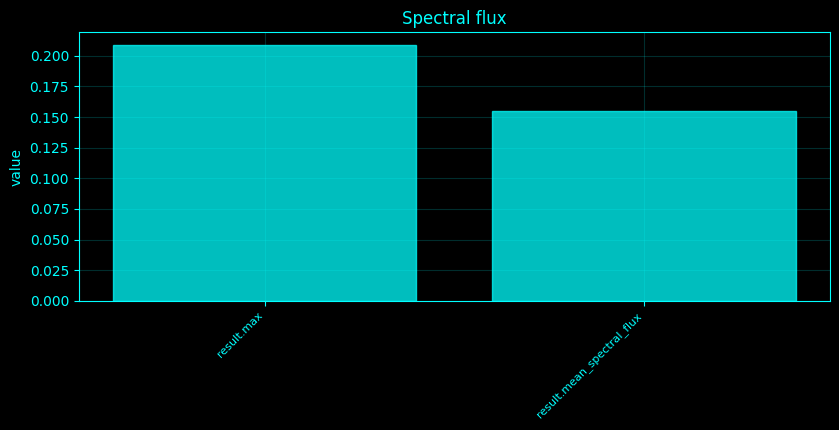

In [158]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _stft_summary():
    if 'stft' in SPEC_CACHE:
        return SPEC_CACHE['stft']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(nper // 2, nper - 1)
    f, t, Z = signal.stft(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, boundary=None, padded=False)
    keep = (f >= 1) & (f <= min(55, 0.49 * _fs))
    SPEC_CACHE['stft'] = (f[keep], t, np.abs(Z[keep]) ** 2, Z[keep])
    return SPEC_CACHE['stft']

# Method-specific calculation.
def _compute_method_158():
    idx = 158
    name = 'Spectral flux'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    _, _, S, _ = _stft_summary()
    Z = np.log(S[:, 0, :] + EPS).T
    Zn = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + EPS)
    flux = np.linalg.norm(np.diff(Zn, axis=0), axis=1)
    return ({'mean_spectral_flux': float(np.mean(flux)), 'max': float(np.max(flux))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_158,_plot_spec=_compute_method_158()
print('Spectral flux')
if isinstance(result_158,dict):
    for _k,_v in result_158.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_158)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_158)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral flux',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral flux',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral flux',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">159. Spectral decrease</h3>
<p>Spectral decrease measures average decline relative to the first spectral bin, normalized by total later-bin energy; the cell reports the explicit finite-bin definition used.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [159]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_159():
    idx = 159
    name = 'Spectral decrease'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    v = p[m]
    k = np.arange(1, len(v) + 1)
    dec = np.sum((v[1:] - v[0]) / (k[1:] - 1 + EPS)) / (np.sum(v[1:]) + EPS)
    return ({'spectral_decrease': float(dec)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_159,_plot_spec=_compute_method_159()
print('Spectral decrease')
if isinstance(result_159,dict):
    for _k,_v in result_159.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_159)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_159)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral decrease',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral decrease',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral decrease',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral decrease
  spectral_decrease: -0.33491990600524374


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">160. Spectral contrast</h3>
<p>Spectral contrast compares local maximum and minimum power within log-spaced subbands, reported in decibels.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral contrast
  band_contrast_db: array(6,), mean=4.72044
  mean: 4.720442629756465


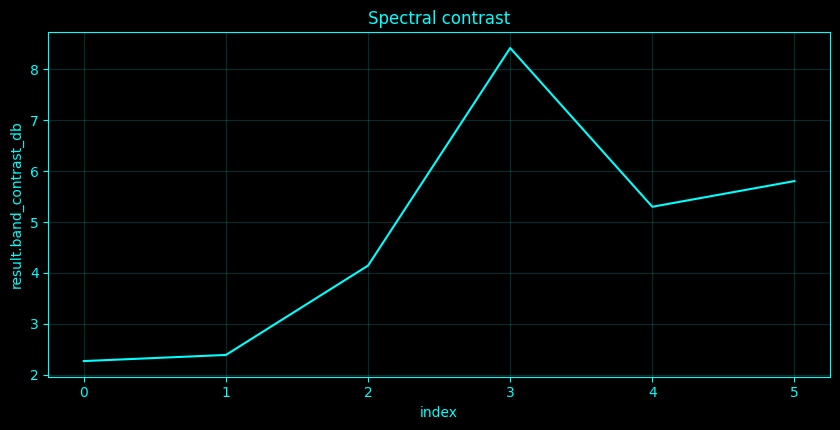

In [160]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_160():
    idx = 160
    name = 'Spectral contrast'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    edges = np.geomspace(2, 45, 7)
    vals = []
    for a, b in zip(edges[:-1], edges[1:]):
        z = p[(f >= a) & (f < b)]
        if len(z):
            vals.append(float(10 * np.log10((np.max(z) + EPS) / (np.min(z) + EPS))))
    return ({'band_contrast_db': vals, 'mean': float(np.mean(vals))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_160,_plot_spec=_compute_method_160()
print('Spectral contrast')
if isinstance(result_160,dict):
    for _k,_v in result_160.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_160)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_160)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral contrast',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral contrast',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral contrast',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">161. Spectral irregularity</h3>
<p>Spectral irregularity is normalized adjacent-bin roughness, \(\sum_k(P_{k+1}-P_k)^2/\sum_kP_k^2\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [161]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_161():
    idx = 161
    name = 'Spectral irregularity'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    v = p[m]
    irr = np.sum(np.diff(v) ** 2) / (np.sum(v ** 2) + EPS)
    return ({'spectral_irregularity': float(irr)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_161,_plot_spec=_compute_method_161()
print('Spectral irregularity')
if isinstance(result_161,dict):
    for _k,_v in result_161.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_161)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_161)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral irregularity',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral irregularity',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral irregularity',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral irregularity
  spectral_irregularity: 0.049015697573241576


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">162. Spectral sharpness</h3>
<p>Spectral sharpness is defined explicitly here as the absolute second derivative of log PSD with respect to frequency at the dominant peak; larger curvature means a sharper peak.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [162]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_162():
    idx = 162
    name = 'Spectral sharpness'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    lp = np.log(p[m] + EPS)
    k = np.argmax(lp)
    sec = np.gradient(np.gradient(lp, ff), ff)
    return ({'peak_sharpness_abs_second_derivative': float(abs(sec[k]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_162,_plot_spec=_compute_method_162()
print('Spectral sharpness')
if isinstance(result_162,dict):
    for _k,_v in result_162.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_162)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_162)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral sharpness',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral sharpness',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral sharpness',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral sharpness
  peak_sharpness_abs_second_derivative: 0.8315197770983878


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">163. Spectral slope moments</h3>
<p>Spectral slope moments summarize the distribution of \(d\log P/d\log f\) across frequency by its mean, standard deviation, and skewness.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral slope moments
  slope_mean: -1.4240025770560143
  slope_sd: 11.568936537801589
  slope_skew: -1.098280560880268


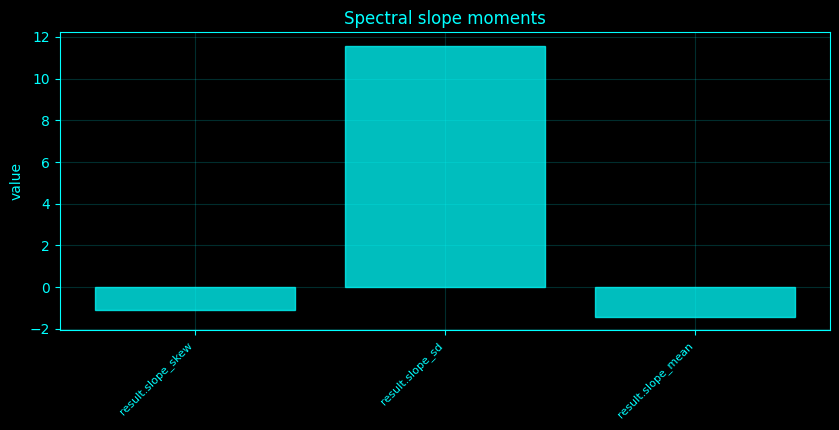

In [163]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

# Method-specific calculation.
def _compute_method_163():
    idx = 163
    name = 'Spectral slope moments'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    slope = np.gradient(np.log(p[m] + EPS), np.log(ff + EPS))
    return ({'slope_mean': float(np.mean(slope)), 'slope_sd': float(np.std(slope)), 'slope_skew': float(stats.skew(slope))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_163,_plot_spec=_compute_method_163()
print('Spectral slope moments')
if isinstance(result_163,dict):
    for _k,_v in result_163.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_163)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_163)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral slope moments',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral slope moments',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral slope moments',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">164. Spectral shape fingerprints</h3>
<p>A spectral shape fingerprint concatenates standardized bandpowers, aperiodic exponent, dominant peak frequency, and entropy into a per-channel descriptor.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Spectral shape fingerprints
  channel_spectral_shape_fingerprints: array(12, 8), mean=2.38235e-16


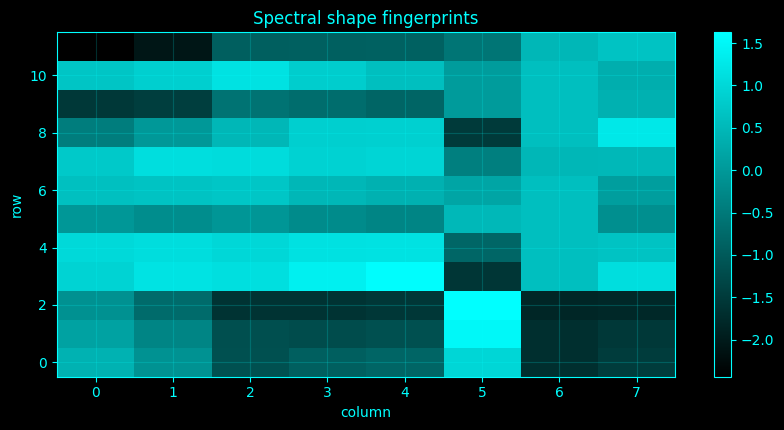

In [164]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _bandpower_matrix():
    if 'bandpower' in SPEC_CACHE:
        return SPEC_CACHE['bandpower']
    f, P = _welch_all()
    M = np.vstack([_band_integral(P, f, b) for b in BANDS.values()]).T
    SPEC_CACHE['bandpower'] = (list(BANDS), M)
    return SPEC_CACHE['bandpower']

def _spectral_features():
    if 'features' in SPEC_CACHE:
        return SPEC_CACHE['features']
    f, P = _welch_all()
    _, BP = _bandpower_matrix()
    m = (f >= 2) & (f <= 45)
    slopes = []
    peaks = []
    entropy = []
    for j in range(C):
        xx = np.log10(f[m] + EPS)
        yy = np.log10(P[m, j] + EPS)
        coef = np.polyfit(xx, yy, 1)
        slopes.append(-coef[0])
        mm = (f >= 6) & (f <= 30)
        peaks.append(float(f[mm][np.argmax(P[mm, j])]))
        pp = P[m, j] / (np.sum(P[m, j]) + EPS)
        entropy.append(float(-np.sum(pp * np.log(pp + EPS))))
    F = np.column_stack([np.log(BP + EPS), slopes, peaks, entropy])
    F = (F - np.mean(F, axis=0)) / (np.std(F, axis=0) + EPS)
    SPEC_CACHE['features'] = (F, np.asarray(slopes), np.asarray(peaks), np.asarray(entropy))
    return SPEC_CACHE['features']

# Method-specific calculation.
def _compute_method_164():
    idx = 164
    name = 'Spectral shape fingerprints'
    __plot_spec = None
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    m = (f >= 1) & (f <= 45)
    ff = f[m]
    q = p[m]
    q = q / (np.trapz(q, ff) + EPS)
    cdf = np.cumsum(q)
    cdf /= cdf[-1] + EPS
    mean = float(np.trapz(ff * q, ff))
    var = float(np.trapz((ff - mean) ** 2 * q, ff))
    sd = np.sqrt(max(var, 0))
    F, sl, pk, en = _spectral_features()
    return ({'channel_spectral_shape_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_164,_plot_spec=_compute_method_164()
print('Spectral shape fingerprints')
if isinstance(result_164,dict):
    for _k,_v in result_164.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_164)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_164)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral shape fingerprints',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral shape fingerprints',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral shape fingerprints',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">165. Reassigned spectrogram</h3>
<p>A reassigned spectrogram uses STFT phase derivatives to move energy from the nominal bin \((t,f)\) to a local instantaneous-frequency estimate, sharpening smeared ridges.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [165]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.


# Method-specific calculation.
def _compute_method_165():
    idx = 165
    name = 'Reassigned spectrogram'
    __plot_spec = None
    n = min(_SPEED['nperseg'], N)
    no = n // 2
    ff, tt, Z = signal.stft(X[:, 0], fs=_fs, nperseg=n, noverlap=no, boundary=None, padded=False)
    ph = np.unwrap(np.angle(Z), axis=1)
    inst = np.gradient(ph, tt, axis=1) / (2 * np.pi) + ff[:, None]
    P = np.abs(Z) ** 2
    keep = (ff >= 1) & (ff <= min(45, 0.49 * _fs))
    grid = ff[keep]
    R = np.zeros((len(grid), P.shape[1]))
    for ti in range(P.shape[1]):
        ids = np.searchsorted(grid, inst[keep, ti])
        ids = np.clip(ids, 0, len(grid) - 1)
        np.add.at(R[:, ti], ids, P[keep, ti])
    __plot_spec = ('summary', np.log(R + EPS), name, None, '', 'value')
    return ({'reassigned_energy_fraction': float(np.sum(R) / (np.sum(P[keep]) + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_165,_plot_spec=_compute_method_165()
print('Reassigned spectrogram')
if isinstance(result_165,dict):
    for _k,_v in result_165.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_165)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_165)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Reassigned spectrogram',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Reassigned spectrogram',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Reassigned spectrogram',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Reassigned spectrogram
  reassigned_energy_fraction: 0.9999999999989231


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">166. Synchrosqueezed STFT</h3>
<p>Synchrosqueezed STFT reallocates STFT energy along the frequency axis according to local phase-derived instantaneous frequency while retaining the time coordinate.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [ ]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.


# Method-specific calculation.
def _compute_method_166():
    idx = 166
    name = 'Synchrosqueezed STFT'
    __plot_spec = None
    n = min(_SPEED['nperseg'], N)
    no = n // 2
    ff, tt, Z = signal.stft(X[:, 0], fs=_fs, nperseg=n, noverlap=no, boundary=None, padded=False)
    ph = np.unwrap(np.angle(Z), axis=1)
    inst = np.gradient(ph, tt, axis=1) / (2 * np.pi) + ff[:, None]
    P = np.abs(Z) ** 2
    keep = (ff >= 1) & (ff <= min(45, 0.49 * _fs))
    grid = ff[keep]
    R = np.zeros((len(grid), P.shape[1]))
    for ti in range(P.shape[1]):
        ids = np.searchsorted(grid, inst[keep, ti])
        ids = np.clip(ids, 0, len(grid) - 1)
        np.add.at(R[:, ti], ids, P[keep, ti])
    __plot_spec = ('summary', np.log(R + EPS), name, None, '', 'value')
    return ({'reassigned_energy_fraction': float(np.sum(R) / (np.sum(P[keep]) + EPS))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_166,_plot_spec=_compute_method_166()
print('Synchrosqueezed STFT')
if isinstance(result_166,dict):
    for _k,_v in result_166.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_166)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_166)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Synchrosqueezed STFT',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Synchrosqueezed STFT',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Synchrosqueezed STFT',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">167. Synchrosqueezed wavelet transform</h3>
<p>Synchrosqueezed wavelet analysis computes a complex Morlet CWT, estimates instantaneous frequency from wavelet phase derivatives, and reallocates wavelet energy to that frequency.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A wavelet transform compares the signal with short oscillatory templates that are shifted in time and stretched or compressed in scale. Small scales correspond roughly to faster oscillations and large scales to slower ones, with the exact scale-frequency conversion depending on the chosen wavelet. This produces a time-frequency representation, which is useful when EEG spectral content changes over time. Near the beginning and end of the recording, estimates are less reliable because the wavelet extends beyond the available data.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Synchrosqueezed wavelet transform
  synchrosqueezed_CWT_shape: array(2,), mean=6700


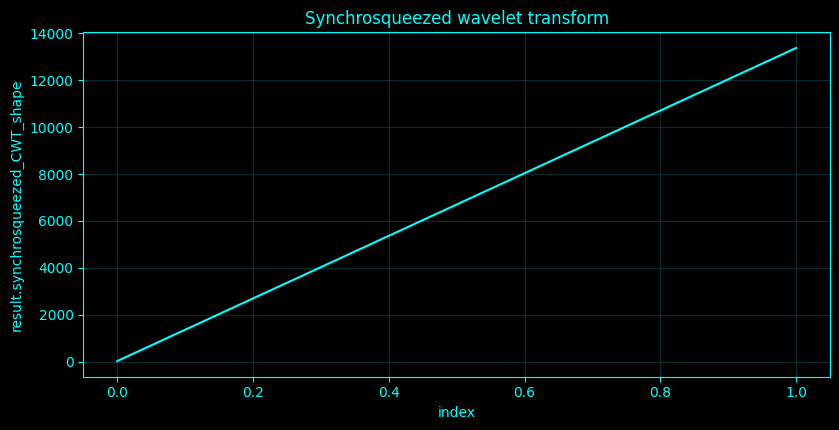

In [1]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

# Method-specific calculation.
def _compute_method_167():
    idx = 167
    name = 'Synchrosqueezed wavelet transform'
    __plot_spec = None
    fre, Cw = _morlet_scalogram()
    ph = np.unwrap(np.angle(Cw), axis=1)
    inst = np.gradient(ph, 1 / _fs, axis=1) / (2 * np.pi)
    P = np.abs(Cw) ** 2
    R = np.zeros_like(P)
    for ti in range(P.shape[1]):
        ids = np.searchsorted(fre, inst[:, ti])
        ids = np.clip(ids, 0, len(fre) - 1)
        np.add.at(R[:, ti], ids, P[:, ti])
    return ({'synchrosqueezed_CWT_shape': R.shape}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_167,_plot_spec=_compute_method_167()
print('Synchrosqueezed wavelet transform')
if isinstance(result_167,dict):
    for _k,_v in result_167.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_167)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_167)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Synchrosqueezed wavelet transform',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Synchrosqueezed wavelet transform',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Synchrosqueezed wavelet transform',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">168. Wigner-Ville distribution</h3>
<p>The Wigner-Ville distribution is \(W_x(t,f)=\int x_a(t+\tau/2)x_a^\ast(t-\tau/2)e^{-i2\pi f\tau}d\tau\). It has high resolution but produces bilinear cross-terms.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Wigner-Ville distribution
  time_frequency_shape: array(2,), mean=1280
  energy: 45804195.45601709


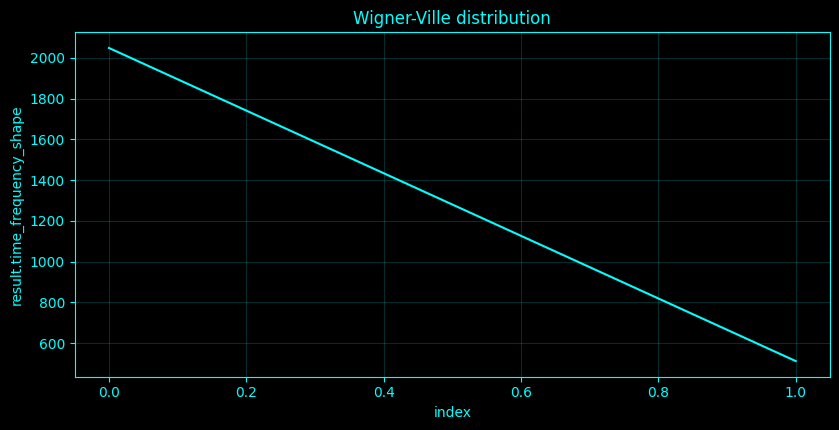

In [2]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.


# Method-specific calculation.
def _compute_method_168():
    idx = 168
    name = 'Wigner-Ville distribution'
    __plot_spec = None
    y = signal.hilbert(X[:min(N, 2048), 0])
    n = len(y)
    L = min(256, n // 2)
    W = np.zeros((n, 2 * L), float)
    lags = np.arange(-L, L)
    for t0 in range(n):
        valid = (t0 + lags >= 0) & (t0 - lags >= 0) & (t0 + lags < n) & (t0 - lags < n)
        r = np.zeros(2 * L, complex)
        lv = lags[valid]
        r[valid] = y[t0 + lv] * np.conj(y[t0 - lv])
        W[t0] = np.real(np.fft.fftshift(np.fft.fft(r)))
    return ({'time_frequency_shape': W.shape, 'energy': float(np.sum(np.abs(W)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_168,_plot_spec=_compute_method_168()
print('Wigner-Ville distribution')
if isinstance(result_168,dict):
    for _k,_v in result_168.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_168)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_168)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wigner-Ville distribution',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wigner-Ville distribution',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wigner-Ville distribution',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">169. Smoothed pseudo-Wigner-Ville distribution</h3>
<p>Smoothed pseudo-Wigner-Ville suppresses WVD cross-terms by smoothing the bilinear distribution in time/frequency, trading resolution for interference reduction.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Smoothed pseudo-Wigner-Ville distribution
  time_frequency_shape: array(2,), mean=1280
  energy: 1977970.2162544266


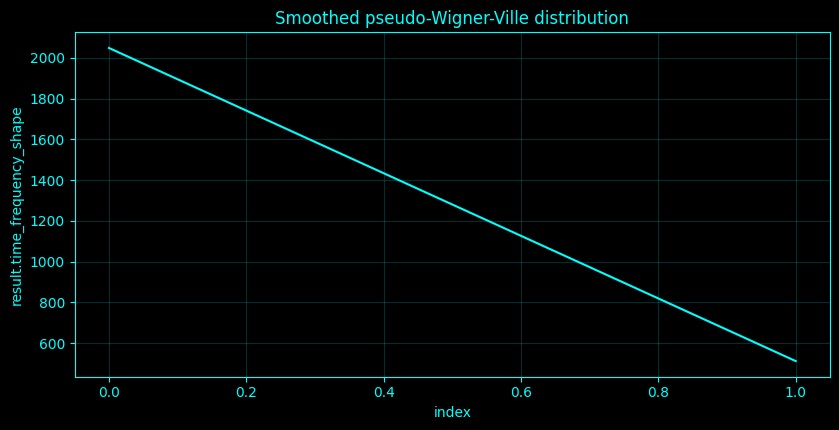

In [3]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.


# Method-specific calculation.
def _compute_method_169():
    idx = 169
    name = 'Smoothed pseudo-Wigner-Ville distribution'
    __plot_spec = None
    y = signal.hilbert(X[:min(N, 2048), 0])
    n = len(y)
    L = min(256, n // 2)
    W = np.zeros((n, 2 * L), float)
    lags = np.arange(-L, L)
    for t0 in range(n):
        valid = (t0 + lags >= 0) & (t0 - lags >= 0) & (t0 + lags < n) & (t0 - lags < n)
        r = np.zeros(2 * L, complex)
        lv = lags[valid]
        r[valid] = y[t0 + lv] * np.conj(y[t0 - lv])
        W[t0] = np.real(np.fft.fftshift(np.fft.fft(r)))
    W = ndimage.gaussian_filter(W, sigma=(2, 2))
    return ({'time_frequency_shape': W.shape, 'energy': float(np.sum(np.abs(W)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_169,_plot_spec=_compute_method_169()
print('Smoothed pseudo-Wigner-Ville distribution')
if isinstance(result_169,dict):
    for _k,_v in result_169.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_169)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_169)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Smoothed pseudo-Wigner-Ville distribution',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Smoothed pseudo-Wigner-Ville distribution',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Smoothed pseudo-Wigner-Ville distribution',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">170. Choi-Williams distribution</h3>
<p>The Choi-Williams Cohen-class kernel damps ambiguity-domain cross-terms with an exponential depending on the product of delay and Doppler variables. The cell applies that kernel numerically in the ambiguity domain.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Choi-Williams distribution
  time_frequency_shape: array(2,), mean=1280
  energy: 35443017.29524283


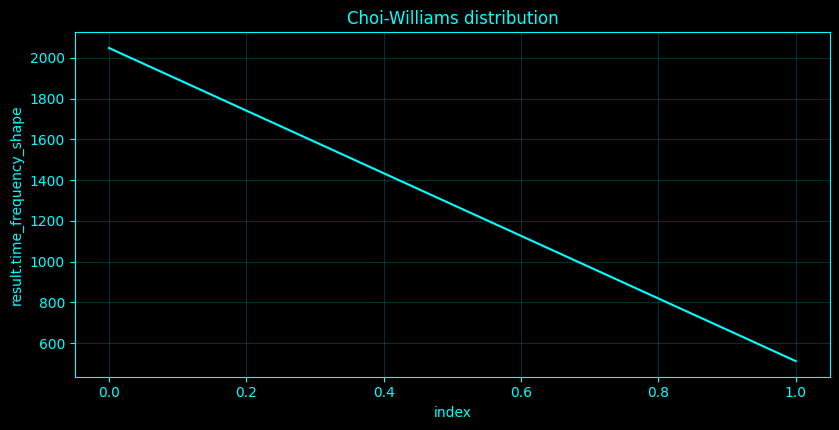

In [4]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.


# Method-specific calculation.
def _compute_method_170():
    idx = 170
    name = 'Choi-Williams distribution'
    __plot_spec = None
    y = signal.hilbert(X[:min(N, 2048), 0])
    n = len(y)
    L = min(256, n // 2)
    W = np.zeros((n, 2 * L), float)
    lags = np.arange(-L, L)
    for t0 in range(n):
        valid = (t0 + lags >= 0) & (t0 - lags >= 0) & (t0 + lags < n) & (t0 - lags < n)
        r = np.zeros(2 * L, complex)
        lv = lags[valid]
        r[valid] = y[t0 + lv] * np.conj(y[t0 - lv])
        W[t0] = np.real(np.fft.fftshift(np.fft.fft(r)))
    A = np.fft.fft2(W)
    u = np.fft.fftfreq(W.shape[0])[:, None]
    v = np.fft.fftfreq(W.shape[1])[None, :]
    ker = np.exp(-(u * v) ** 2 / (0.02 if idx == 170 else 0.05))
    W = np.real(np.fft.ifft2(A * ker))
    return ({'time_frequency_shape': W.shape, 'energy': float(np.sum(np.abs(W)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_170,_plot_spec=_compute_method_170()
print('Choi-Williams distribution')
if isinstance(result_170,dict):
    for _k,_v in result_170.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_170)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_170)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Choi-Williams distribution',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Choi-Williams distribution',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Choi-Williams distribution',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">171. Cohen-class time-frequency distributions</h3>
<p>Cohen-class distributions are 2-D filtered Wigner-Ville distributions; choosing an ambiguity-domain kernel controls the resolution/cross-term tradeoff.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Cohen-class time-frequency distributions
  time_frequency_shape: array(2,), mean=1280
  energy: 40118493.46287528


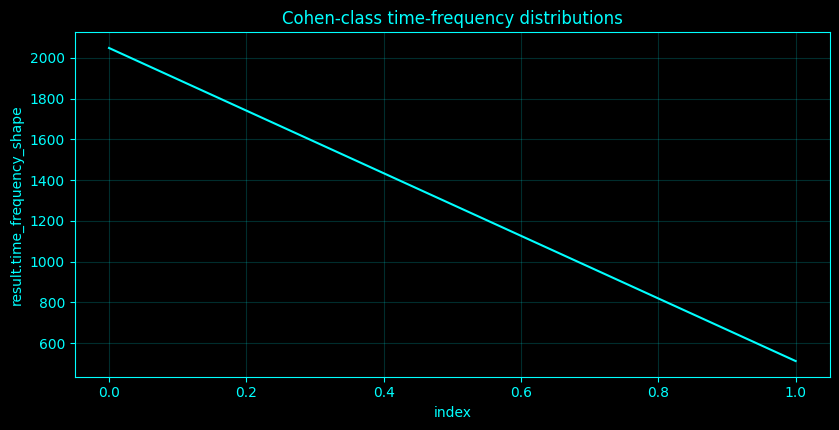

In [5]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.


# Method-specific calculation.
def _compute_method_171():
    idx = 171
    name = 'Cohen-class time-frequency distributions'
    __plot_spec = None
    y = signal.hilbert(X[:min(N, 2048), 0])
    n = len(y)
    L = min(256, n // 2)
    W = np.zeros((n, 2 * L), float)
    lags = np.arange(-L, L)
    for t0 in range(n):
        valid = (t0 + lags >= 0) & (t0 - lags >= 0) & (t0 + lags < n) & (t0 - lags < n)
        r = np.zeros(2 * L, complex)
        lv = lags[valid]
        r[valid] = y[t0 + lv] * np.conj(y[t0 - lv])
        W[t0] = np.real(np.fft.fftshift(np.fft.fft(r)))
    A = np.fft.fft2(W)
    u = np.fft.fftfreq(W.shape[0])[:, None]
    v = np.fft.fftfreq(W.shape[1])[None, :]
    ker = np.exp(-(u * v) ** 2 / (0.02 if idx == 170 else 0.05))
    W = np.real(np.fft.ifft2(A * ker))
    return ({'time_frequency_shape': W.shape, 'energy': float(np.sum(np.abs(W)))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_171,_plot_spec=_compute_method_171()
print('Cohen-class time-frequency distributions')
if isinstance(result_171,dict):
    for _k,_v in result_171.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_171)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_171)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Cohen-class time-frequency distributions',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Cohen-class time-frequency distributions',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Cohen-class time-frequency distributions',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">172. S-transform</h3>
<p>The Stockwell/S-transform uses a frequency-dependent Gaussian window whose width scales approximately as \(1/f\), retaining absolute phase while giving multiresolution time-frequency localization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [6]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.


# Method-specific calculation.
def _compute_method_172():
    idx = 172
    name = 'S-transform'
    __plot_spec = None
    y = X[:, 0]
    freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    rows = []
    tt = np.arange(N) / _fs
    for fc in freqs:
        sigma = max(1 / _fs, 1 / (2 * np.pi * fc))
        half = int(min(N // 4, max(8, 4 * sigma * _fs)))
        tw = np.arange(-half, half + 1) / _fs
        g = np.exp(-tw ** 2 / (2 * sigma ** 2)) * np.exp(2j * np.pi * fc * tw)
        g /= np.sqrt(np.sum(np.abs(g) ** 2) + EPS)
        rows.append(np.abs(signal.fftconvolve(y, g[::-1].conj(), mode='same')) ** 2)
    return ({'Stockwell_like_frequency_rows': len(rows), 'note': 'frequency-dependent Gaussian-window S-transform implementation'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_172,_plot_spec=_compute_method_172()
print('S-transform')
if isinstance(result_172,dict):
    for _k,_v in result_172.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_172)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_172)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'S-transform',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'S-transform',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('S-transform',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


S-transform
  Stockwell_like_frequency_rows: 32
  note: frequency-dependent Gaussian-window S-transform implementation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">173. Stockwell transform</h3>
<p>The Stockwell/S-transform uses a frequency-dependent Gaussian window whose width scales approximately as \(1/f\), retaining absolute phase while giving multiresolution time-frequency localization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [7]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.


# Method-specific calculation.
def _compute_method_173():
    idx = 173
    name = 'Stockwell transform'
    __plot_spec = None
    y = X[:, 0]
    freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    rows = []
    tt = np.arange(N) / _fs
    for fc in freqs:
        sigma = max(1 / _fs, 1 / (2 * np.pi * fc))
        half = int(min(N // 4, max(8, 4 * sigma * _fs)))
        tw = np.arange(-half, half + 1) / _fs
        g = np.exp(-tw ** 2 / (2 * sigma ** 2)) * np.exp(2j * np.pi * fc * tw)
        g /= np.sqrt(np.sum(np.abs(g) ** 2) + EPS)
        rows.append(np.abs(signal.fftconvolve(y, g[::-1].conj(), mode='same')) ** 2)
    return ({'Stockwell_like_frequency_rows': len(rows), 'note': 'frequency-dependent Gaussian-window S-transform implementation'}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_173,_plot_spec=_compute_method_173()
print('Stockwell transform')
if isinstance(result_173,dict):
    for _k,_v in result_173.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_173)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_173)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Stockwell transform',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Stockwell transform',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Stockwell transform',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Stockwell transform
  Stockwell_like_frequency_rows: 32
  note: frequency-dependent Gaussian-window S-transform implementation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">174. Hilbert-Huang transform</h3>
<p>Hilbert-Huang analysis first decomposes the signal into empirical mode functions (IMFs), then obtains each IMF's instantaneous amplitude/frequency from its analytic signal.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Hilbert-Huang transform
  n_IMFs: 4
  median_instantaneous_frequencies_hz: array(4,), mean=24.4381


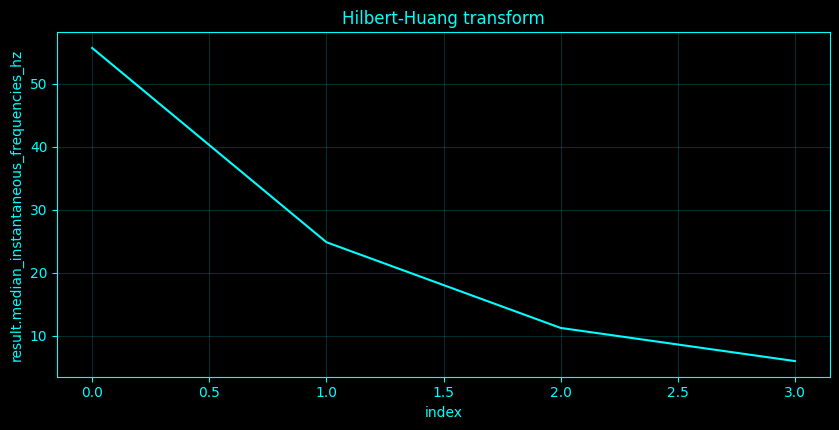

In [8]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _emd_simple(y, max_imfs=5, max_sift=20):
    r = np.asarray(y, float).copy()
    imfs = []
    for _ in range(max_imfs):
        h = r.copy()
        for _s in range(max_sift):
            maxidx = signal.find_peaks(h)[0]
            minidx = signal.find_peaks(-h)[0]
            if len(maxidx) < 2 or len(minidx) < 2:
                break
            x = np.arange(len(h))
            up = np.interp(x, maxidx, h[maxidx])
            lo = np.interp(x, minidx, h[minidx])
            m = (up + lo) / 2
            hnew = h - m
            if np.linalg.norm(hnew - h) / (np.linalg.norm(h) + EPS) < 0.05:
                h = hnew
                break
            h = hnew
        if len(signal.find_peaks(h)[0]) < 2:
            break
        imfs.append(h)
        r = r - h
        if np.std(r) < 0.0001 * np.std(y):
            break
    return (imfs, r)

def _vmd_simple(y, K=4, alpha=2000, tau=0.0, n_iter=120):
    y = np.asarray(y, float)
    N0 = len(y)
    n = min(N0, 4096 if FAST_OPTION == 'ultra' else 8192)
    y = y[:n]
    freqs = np.fft.fftfreq(n)
    fhat = np.fft.fft(y)
    u = np.zeros((K, n), complex)
    omega = np.linspace(0, 0.4, K + 2)[1:-1]
    lam = np.zeros(n, complex)
    pos = freqs >= 0
    for _ in range(n_iter):
        usum = np.sum(u, axis=0)
        for k in range(K):
            rest = usum - u[k]
            denom = 1 + 2 * alpha * (freqs - omega[k]) ** 2
            new = (fhat - rest + lam / 2) / denom
            usum = rest + new
            u[k] = new
            pw = np.abs(new[pos]) ** 2
            omega[k] = np.sum(freqs[pos] * pw) / (np.sum(pw) + EPS)
        if tau:
            lam = lam + tau * (fhat - usum)
    modes = np.real(np.fft.ifft(u, axis=1))
    return (modes, omega * _fs)

# Method-specific calculation.
def _compute_method_174():
    idx = 174
    name = 'Hilbert-Huang transform'
    __plot_spec = None
    y = X[:, 0]
    imfs, r = _emd_simple(y, max_imfs=4 if FAST_OPTION == 'ultra' else 6)
    freqs = []
    for q in imfs:
        z = signal.hilbert(q)
        freqs.append(float(np.median(np.diff(np.unwrap(np.angle(z))) * _fs / (2 * np.pi))))
    return ({'n_IMFs': len(imfs), 'median_instantaneous_frequencies_hz': freqs}, locals().get('__plot_spec', None))
    modes, fc = _vmd_simple(y, K=min(4, _SPEED['rank']))
    return ({'mode_aligned_spectral_energy': np.mean(modes * modes, axis=1).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_174,_plot_spec=_compute_method_174()
print('Hilbert-Huang transform')
if isinstance(result_174,dict):
    for _k,_v in result_174.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_174)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_174)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Hilbert-Huang transform',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Hilbert-Huang transform',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Hilbert-Huang transform',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">175. Empirical mode decomposition spectrum</h3>
<p>Empirical mode decomposition iteratively removes local envelope means to extract IMFs satisfying local symmetry/zero-crossing conditions; IMF Hilbert frequencies form a data-adaptive spectrum.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Empirical mode decomposition spectrum
  n_IMFs: 4
  median_instantaneous_frequencies_hz: array(4,), mean=24.4381


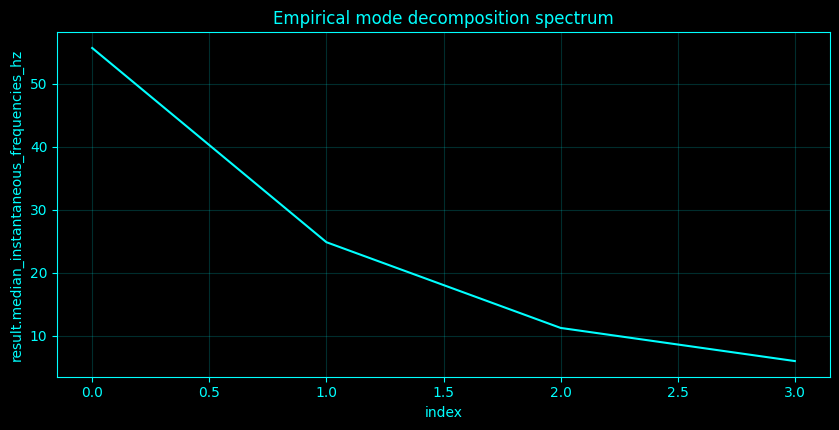

In [9]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _emd_simple(y, max_imfs=5, max_sift=20):
    r = np.asarray(y, float).copy()
    imfs = []
    for _ in range(max_imfs):
        h = r.copy()
        for _s in range(max_sift):
            maxidx = signal.find_peaks(h)[0]
            minidx = signal.find_peaks(-h)[0]
            if len(maxidx) < 2 or len(minidx) < 2:
                break
            x = np.arange(len(h))
            up = np.interp(x, maxidx, h[maxidx])
            lo = np.interp(x, minidx, h[minidx])
            m = (up + lo) / 2
            hnew = h - m
            if np.linalg.norm(hnew - h) / (np.linalg.norm(h) + EPS) < 0.05:
                h = hnew
                break
            h = hnew
        if len(signal.find_peaks(h)[0]) < 2:
            break
        imfs.append(h)
        r = r - h
        if np.std(r) < 0.0001 * np.std(y):
            break
    return (imfs, r)

def _vmd_simple(y, K=4, alpha=2000, tau=0.0, n_iter=120):
    y = np.asarray(y, float)
    N0 = len(y)
    n = min(N0, 4096 if FAST_OPTION == 'ultra' else 8192)
    y = y[:n]
    freqs = np.fft.fftfreq(n)
    fhat = np.fft.fft(y)
    u = np.zeros((K, n), complex)
    omega = np.linspace(0, 0.4, K + 2)[1:-1]
    lam = np.zeros(n, complex)
    pos = freqs >= 0
    for _ in range(n_iter):
        usum = np.sum(u, axis=0)
        for k in range(K):
            rest = usum - u[k]
            denom = 1 + 2 * alpha * (freqs - omega[k]) ** 2
            new = (fhat - rest + lam / 2) / denom
            usum = rest + new
            u[k] = new
            pw = np.abs(new[pos]) ** 2
            omega[k] = np.sum(freqs[pos] * pw) / (np.sum(pw) + EPS)
        if tau:
            lam = lam + tau * (fhat - usum)
    modes = np.real(np.fft.ifft(u, axis=1))
    return (modes, omega * _fs)

# Method-specific calculation.
def _compute_method_175():
    idx = 175
    name = 'Empirical mode decomposition spectrum'
    __plot_spec = None
    y = X[:, 0]
    imfs, r = _emd_simple(y, max_imfs=4 if FAST_OPTION == 'ultra' else 6)
    freqs = []
    for q in imfs:
        z = signal.hilbert(q)
        freqs.append(float(np.median(np.diff(np.unwrap(np.angle(z))) * _fs / (2 * np.pi))))
    return ({'n_IMFs': len(imfs), 'median_instantaneous_frequencies_hz': freqs}, locals().get('__plot_spec', None))
    modes, fc = _vmd_simple(y, K=min(4, _SPEED['rank']))
    return ({'mode_aligned_spectral_energy': np.mean(modes * modes, axis=1).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_175,_plot_spec=_compute_method_175()
print('Empirical mode decomposition spectrum')
if isinstance(result_175,dict):
    for _k,_v in result_175.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_175)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_175)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Empirical mode decomposition spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Empirical mode decomposition spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Empirical mode decomposition spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">176. Ensemble EMD spectrum</h3>
<p>Ensemble EMD repeats EMD after adding independent small noise and averages corresponding IMFs, reducing mode mixing.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Ensemble EMD spectrum
  ensemble_size: 8
  first_IMF_energy: 0.9639253149066813


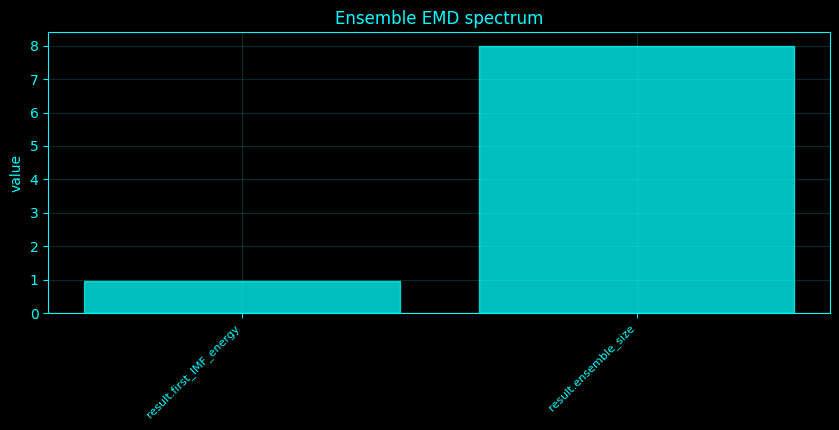

In [10]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _emd_simple(y, max_imfs=5, max_sift=20):
    r = np.asarray(y, float).copy()
    imfs = []
    for _ in range(max_imfs):
        h = r.copy()
        for _s in range(max_sift):
            maxidx = signal.find_peaks(h)[0]
            minidx = signal.find_peaks(-h)[0]
            if len(maxidx) < 2 or len(minidx) < 2:
                break
            x = np.arange(len(h))
            up = np.interp(x, maxidx, h[maxidx])
            lo = np.interp(x, minidx, h[minidx])
            m = (up + lo) / 2
            hnew = h - m
            if np.linalg.norm(hnew - h) / (np.linalg.norm(h) + EPS) < 0.05:
                h = hnew
                break
            h = hnew
        if len(signal.find_peaks(h)[0]) < 2:
            break
        imfs.append(h)
        r = r - h
        if np.std(r) < 0.0001 * np.std(y):
            break
    return (imfs, r)

def _vmd_simple(y, K=4, alpha=2000, tau=0.0, n_iter=120):
    y = np.asarray(y, float)
    N0 = len(y)
    n = min(N0, 4096 if FAST_OPTION == 'ultra' else 8192)
    y = y[:n]
    freqs = np.fft.fftfreq(n)
    fhat = np.fft.fft(y)
    u = np.zeros((K, n), complex)
    omega = np.linspace(0, 0.4, K + 2)[1:-1]
    lam = np.zeros(n, complex)
    pos = freqs >= 0
    for _ in range(n_iter):
        usum = np.sum(u, axis=0)
        for k in range(K):
            rest = usum - u[k]
            denom = 1 + 2 * alpha * (freqs - omega[k]) ** 2
            new = (fhat - rest + lam / 2) / denom
            usum = rest + new
            u[k] = new
            pw = np.abs(new[pos]) ** 2
            omega[k] = np.sum(freqs[pos] * pw) / (np.sum(pw) + EPS)
        if tau:
            lam = lam + tau * (fhat - usum)
    modes = np.real(np.fft.ifft(u, axis=1))
    return (modes, omega * _fs)

# Method-specific calculation.
def _compute_method_176():
    idx = 176
    name = 'Ensemble EMD spectrum'
    __plot_spec = None
    y = X[:, 0]
    ens = max(4, _SPEED['n_sur'])
    acc = []
    for _ in range(ens):
        imfs, _ = _emd_simple(y + 0.1 * np.std(y) * _rng.normal(size=len(y)), max_imfs=4)
        acc.append(imfs[0] if imfs else np.zeros_like(y))
    q = np.mean(acc, axis=0)
    return ({'ensemble_size': ens, 'first_IMF_energy': float(np.mean(q * q))}, locals().get('__plot_spec', None))
    modes, fc = _vmd_simple(y, K=min(4, _SPEED['rank']))
    return ({'mode_aligned_spectral_energy': np.mean(modes * modes, axis=1).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_176,_plot_spec=_compute_method_176()
print('Ensemble EMD spectrum')
if isinstance(result_176,dict):
    for _k,_v in result_176.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_176)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_176)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Ensemble EMD spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Ensemble EMD spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Ensemble EMD spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">177. Complete ensemble EMD spectrum</h3>
<p>Complete-ensemble EMD with adaptive noise extracts an ensemble-mean IMF, subtracts it from the residual, and repeats so the modes plus residual reconstruct the signal.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Complete ensemble EMD spectrum
  CEEMDAN_like_modes: 3
  residual_variance: 0.12459503575389287


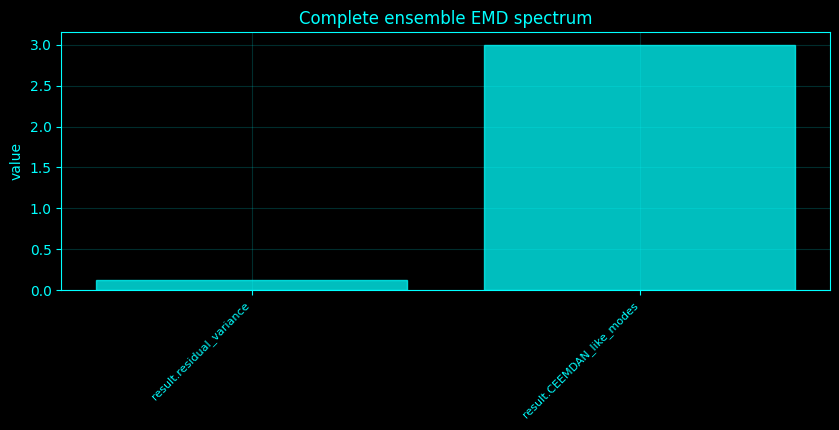

In [11]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _emd_simple(y, max_imfs=5, max_sift=20):
    r = np.asarray(y, float).copy()
    imfs = []
    for _ in range(max_imfs):
        h = r.copy()
        for _s in range(max_sift):
            maxidx = signal.find_peaks(h)[0]
            minidx = signal.find_peaks(-h)[0]
            if len(maxidx) < 2 or len(minidx) < 2:
                break
            x = np.arange(len(h))
            up = np.interp(x, maxidx, h[maxidx])
            lo = np.interp(x, minidx, h[minidx])
            m = (up + lo) / 2
            hnew = h - m
            if np.linalg.norm(hnew - h) / (np.linalg.norm(h) + EPS) < 0.05:
                h = hnew
                break
            h = hnew
        if len(signal.find_peaks(h)[0]) < 2:
            break
        imfs.append(h)
        r = r - h
        if np.std(r) < 0.0001 * np.std(y):
            break
    return (imfs, r)

def _vmd_simple(y, K=4, alpha=2000, tau=0.0, n_iter=120):
    y = np.asarray(y, float)
    N0 = len(y)
    n = min(N0, 4096 if FAST_OPTION == 'ultra' else 8192)
    y = y[:n]
    freqs = np.fft.fftfreq(n)
    fhat = np.fft.fft(y)
    u = np.zeros((K, n), complex)
    omega = np.linspace(0, 0.4, K + 2)[1:-1]
    lam = np.zeros(n, complex)
    pos = freqs >= 0
    for _ in range(n_iter):
        usum = np.sum(u, axis=0)
        for k in range(K):
            rest = usum - u[k]
            denom = 1 + 2 * alpha * (freqs - omega[k]) ** 2
            new = (fhat - rest + lam / 2) / denom
            usum = rest + new
            u[k] = new
            pw = np.abs(new[pos]) ** 2
            omega[k] = np.sum(freqs[pos] * pw) / (np.sum(pw) + EPS)
        if tau:
            lam = lam + tau * (fhat - usum)
    modes = np.real(np.fft.ifft(u, axis=1))
    return (modes, omega * _fs)

# Method-specific calculation.
def _compute_method_177():
    idx = 177
    name = 'Complete ensemble EMD spectrum'
    __plot_spec = None
    y = X[:, 0]
    ens = max(4, _SPEED['n_sur'])
    res = y.copy()
    modes = []
    for k in range(3):
        first = []
        for _ in range(ens):
            imfs, _ = _emd_simple(res + 0.05 * np.std(res) * _rng.normal(size=len(res)), max_imfs=1)
            first.append(imfs[0] if imfs else np.zeros_like(res))
        q = np.mean(first, axis=0)
        modes.append(q)
        res = res - q
    return ({'CEEMDAN_like_modes': len(modes), 'residual_variance': float(np.var(res))}, locals().get('__plot_spec', None))
    modes, fc = _vmd_simple(y, K=min(4, _SPEED['rank']))
    return ({'mode_aligned_spectral_energy': np.mean(modes * modes, axis=1).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_177,_plot_spec=_compute_method_177()
print('Complete ensemble EMD spectrum')
if isinstance(result_177,dict):
    for _k,_v in result_177.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_177)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_177)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Complete ensemble EMD spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Complete ensemble EMD spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Complete ensemble EMD spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">178. Variational mode decomposition spectrum</h3>
<p>Variational mode decomposition solves for band-limited modes whose demodulated analytic bandwidths are jointly minimized under a reconstruction constraint. The implementation uses iterative Fourier-domain updates.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Variational mode decomposition spectrum
  VMD_center_frequencies_hz: array(4,), mean=27.9697
  mode_energies: array(4,), mean=0.07579


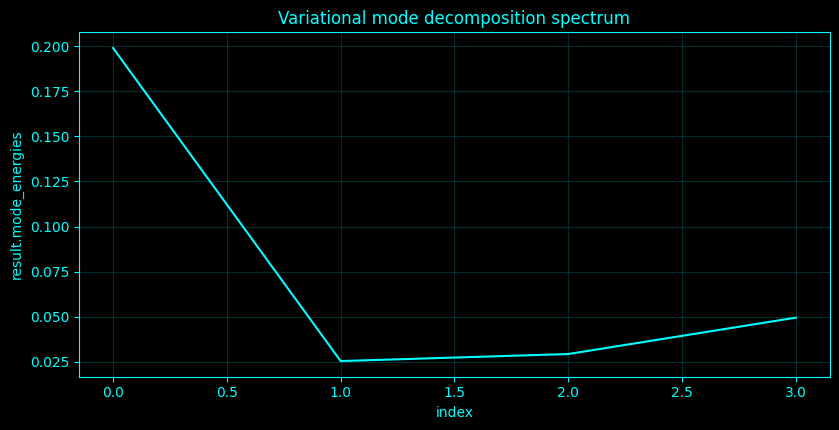

In [12]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _vmd_simple(y, K=4, alpha=2000, tau=0.0, n_iter=120):
    y = np.asarray(y, float)
    N0 = len(y)
    n = min(N0, 4096 if FAST_OPTION == 'ultra' else 8192)
    y = y[:n]
    freqs = np.fft.fftfreq(n)
    fhat = np.fft.fft(y)
    u = np.zeros((K, n), complex)
    omega = np.linspace(0, 0.4, K + 2)[1:-1]
    lam = np.zeros(n, complex)
    pos = freqs >= 0
    for _ in range(n_iter):
        usum = np.sum(u, axis=0)
        for k in range(K):
            rest = usum - u[k]
            denom = 1 + 2 * alpha * (freqs - omega[k]) ** 2
            new = (fhat - rest + lam / 2) / denom
            usum = rest + new
            u[k] = new
            pw = np.abs(new[pos]) ** 2
            omega[k] = np.sum(freqs[pos] * pw) / (np.sum(pw) + EPS)
        if tau:
            lam = lam + tau * (fhat - usum)
    modes = np.real(np.fft.ifft(u, axis=1))
    return (modes, omega * _fs)

# Method-specific calculation.
def _compute_method_178():
    idx = 178
    name = 'Variational mode decomposition spectrum'
    __plot_spec = None
    y = X[:, 0]
    modes, fc = _vmd_simple(y, K=min(4, _SPEED['rank']))
    return ({'VMD_center_frequencies_hz': fc.tolist(), 'mode_energies': np.mean(modes * modes, axis=1).tolist()}, locals().get('__plot_spec', None))
    return ({'mode_aligned_spectral_energy': np.mean(modes * modes, axis=1).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_178,_plot_spec=_compute_method_178()
print('Variational mode decomposition spectrum')
if isinstance(result_178,dict):
    for _k,_v in result_178.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_178)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_178)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Variational mode decomposition spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Variational mode decomposition spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Variational mode decomposition spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">179. Mode-aligned spectral energy</h3>
<p>Mode-aligned spectral energy is the mean squared amplitude of each VMD mode, allowing energy comparison after the modes have been aligned by their center frequencies.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Mode-aligned spectral energy
  mode_aligned_spectral_energy: array(4,), mean=0.07579


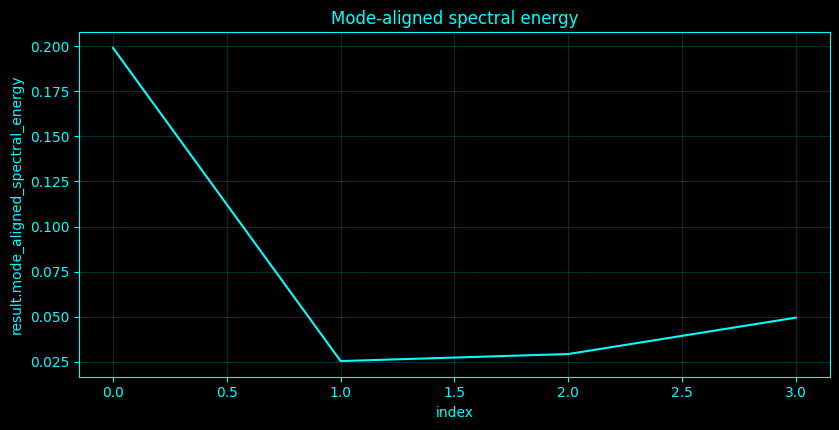

In [13]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _vmd_simple(y, K=4, alpha=2000, tau=0.0, n_iter=120):
    y = np.asarray(y, float)
    N0 = len(y)
    n = min(N0, 4096 if FAST_OPTION == 'ultra' else 8192)
    y = y[:n]
    freqs = np.fft.fftfreq(n)
    fhat = np.fft.fft(y)
    u = np.zeros((K, n), complex)
    omega = np.linspace(0, 0.4, K + 2)[1:-1]
    lam = np.zeros(n, complex)
    pos = freqs >= 0
    for _ in range(n_iter):
        usum = np.sum(u, axis=0)
        for k in range(K):
            rest = usum - u[k]
            denom = 1 + 2 * alpha * (freqs - omega[k]) ** 2
            new = (fhat - rest + lam / 2) / denom
            usum = rest + new
            u[k] = new
            pw = np.abs(new[pos]) ** 2
            omega[k] = np.sum(freqs[pos] * pw) / (np.sum(pw) + EPS)
        if tau:
            lam = lam + tau * (fhat - usum)
    modes = np.real(np.fft.ifft(u, axis=1))
    return (modes, omega * _fs)

# Method-specific calculation.
def _compute_method_179():
    idx = 179
    name = 'Mode-aligned spectral energy'
    __plot_spec = None
    y = X[:, 0]
    modes, fc = _vmd_simple(y, K=min(4, _SPEED['rank']))
    return ({'mode_aligned_spectral_energy': np.mean(modes * modes, axis=1).tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_179,_plot_spec=_compute_method_179()
print('Mode-aligned spectral energy')
if isinstance(result_179,dict):
    for _k,_v in result_179.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_179)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_179)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Mode-aligned spectral energy',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Mode-aligned spectral energy',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Mode-aligned spectral energy',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">180. Instantaneous frequency from Hilbert transform</h3>
<p>For analytic signal \(z(t)=A(t)e^{i\phi(t)}\), instantaneous frequency is \(f_i(t)=(2\pi)^{-1}d\phi/dt\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [14]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

# Method-specific calculation.
def _compute_method_180():
    idx = 180
    name = 'Instantaneous frequency from Hilbert transform'
    __plot_spec = None
    fre, Cw = _morlet_scalogram()
    ridge = np.argmax(np.abs(Cw) ** 2, axis=0)
    z = Cw[ridge, np.arange(Cw.shape[1])]
    phase = np.unwrap(np.angle(z))
    fi = np.gradient(phase) * _fs / (2 * np.pi)
    return ({'median_instantaneous_frequency_hz': float(np.nanmedian(fi))}, locals().get('__plot_spec', None))
    P = np.abs(Cw) ** 2
    P /= np.sum(P, axis=0, keepdims=True) + EPS
    H = -np.sum(P * np.log(P + EPS), axis=0) / np.log(P.shape[0])
    return ({'mean_instantaneous_spectral_entropy': float(np.mean(H))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_180,_plot_spec=_compute_method_180()
print('Instantaneous frequency from Hilbert transform')
if isinstance(result_180,dict):
    for _k,_v in result_180.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_180)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_180)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Instantaneous frequency from Hilbert transform',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Instantaneous frequency from Hilbert transform',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Instantaneous frequency from Hilbert transform',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Instantaneous frequency from Hilbert transform
  median_instantaneous_frequency_hz: 2.4716560447104556


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">181. Instantaneous bandwidth</h3>
<p>Instantaneous bandwidth is represented as \((2\pi)^{-1}|d\log A/dt|\), the amplitude-modulation contribution to local bandwidth in hertz.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [15]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

# Method-specific calculation.
def _compute_method_181():
    idx = 181
    name = 'Instantaneous bandwidth'
    __plot_spec = None
    fre, Cw = _morlet_scalogram()
    ridge = np.argmax(np.abs(Cw) ** 2, axis=0)
    z = Cw[ridge, np.arange(Cw.shape[1])]
    phase = np.unwrap(np.angle(z))
    fi = np.gradient(phase) * _fs / (2 * np.pi)
    amp = np.abs(z)
    bw = np.abs(np.gradient(np.log(amp + EPS)) * _fs / (2 * np.pi))
    return ({'median_instantaneous_bandwidth_hz': float(np.nanmedian(bw))}, locals().get('__plot_spec', None))
    P = np.abs(Cw) ** 2
    P /= np.sum(P, axis=0, keepdims=True) + EPS
    H = -np.sum(P * np.log(P + EPS), axis=0) / np.log(P.shape[0])
    return ({'mean_instantaneous_spectral_entropy': float(np.mean(H))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_181,_plot_spec=_compute_method_181()
print('Instantaneous bandwidth')
if isinstance(result_181,dict):
    for _k,_v in result_181.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_181)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_181)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Instantaneous bandwidth',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Instantaneous bandwidth',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Instantaneous bandwidth',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Instantaneous bandwidth
  median_instantaneous_bandwidth_hz: 0.10279266959021582


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">182. Instantaneous spectral entropy</h3>
<p>Instantaneous spectral entropy normalizes wavelet power across frequencies at each time and computes \(H(t)=-\sum_fp_f(t)\log p_f(t)/\log F\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Spectral entropy treats the normalized power spectrum as a probability distribution over frequency bins and applies Shannon entropy to that distribution. If power is concentrated in only a few frequencies, the distribution is uneven and entropy is low. If power is spread broadly across many frequencies, entropy is higher. The result therefore describes spectral dispersion, not temporal unpredictability in exactly the same sense as Sample Entropy or permutation entropy.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [16]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

# Method-specific calculation.
def _compute_method_182():
    idx = 182
    name = 'Instantaneous spectral entropy'
    __plot_spec = None
    fre, Cw = _morlet_scalogram()
    ridge = np.argmax(np.abs(Cw) ** 2, axis=0)
    z = Cw[ridge, np.arange(Cw.shape[1])]
    phase = np.unwrap(np.angle(z))
    fi = np.gradient(phase) * _fs / (2 * np.pi)
    P = np.abs(Cw) ** 2
    P /= np.sum(P, axis=0, keepdims=True) + EPS
    H = -np.sum(P * np.log(P + EPS), axis=0) / np.log(P.shape[0])
    return ({'mean_instantaneous_spectral_entropy': float(np.mean(H))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_182,_plot_spec=_compute_method_182()
print('Instantaneous spectral entropy')
if isinstance(result_182,dict):
    for _k,_v in result_182.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_182)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_182)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Instantaneous spectral entropy',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Instantaneous spectral entropy',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Instantaneous spectral entropy',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Instantaneous spectral entropy
  mean_instantaneous_spectral_entropy: 0.7881622595625141


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">183. Wavelet packet decomposition</h3>
<p>A wavelet packet recursively splits both low- and high-pass branches. Node energy is \(\sum_n|c_{j,k}[n]|^2\); normalized node energies yield packet entropy \(-\sum p_{j,k}\log p_{j,k}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Wavelet packet decomposition
  packet_nodes: 16
  node_lengths: array(16,), mean=835


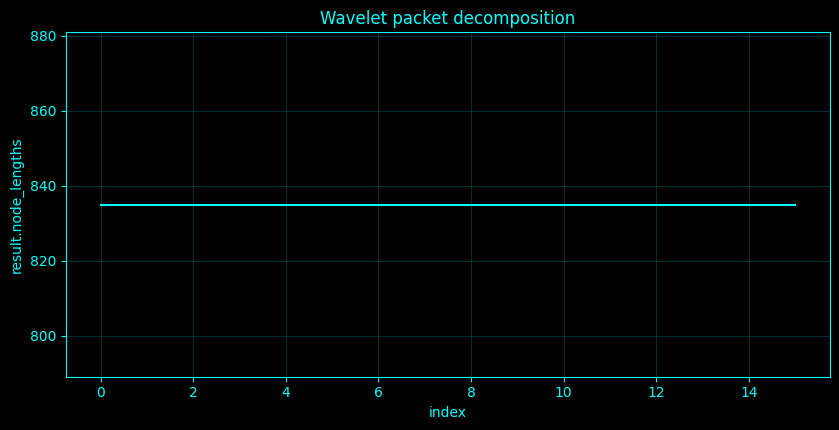

In [17]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_183():
    idx = 183
    name = 'Wavelet packet decomposition'
    __plot_spec = None
    nodes = _haar_packet(X[:, 0], level=4)
    ener = np.array([np.sum(q * q) for q in nodes])
    q = ener / (ener.sum() + EPS)
    return ({'packet_nodes': len(nodes), 'node_lengths': [len(q) for q in nodes]}, locals().get('__plot_spec', None))
    return ({'DWT_bandpower_proxy': ener.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_183,_plot_spec=_compute_method_183()
print('Wavelet packet decomposition')
if isinstance(result_183,dict):
    for _k,_v in result_183.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_183)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_183)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet packet decomposition',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet packet decomposition',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet packet decomposition',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">184. Wavelet packet energy spectrum</h3>
<p>A wavelet packet recursively splits both low- and high-pass branches. Node energy is \(\sum_n|c_{j,k}[n]|^2\); normalized node energies yield packet entropy \(-\sum p_{j,k}\log p_{j,k}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Wavelet packet energy spectrum
  packet_energy_fraction: array(16,), mean=0.0625


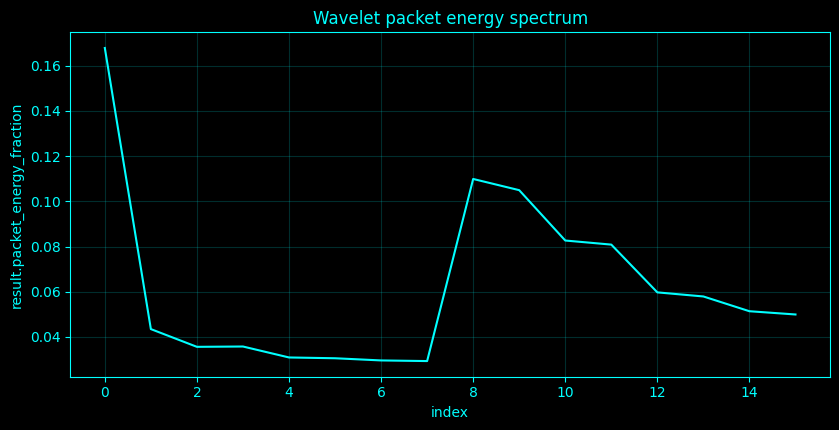

In [18]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_184():
    idx = 184
    name = 'Wavelet packet energy spectrum'
    __plot_spec = None
    nodes = _haar_packet(X[:, 0], level=4)
    ener = np.array([np.sum(q * q) for q in nodes])
    q = ener / (ener.sum() + EPS)
    return ({'packet_energy_fraction': q.tolist()}, locals().get('__plot_spec', None))
    return ({'DWT_bandpower_proxy': ener.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_184,_plot_spec=_compute_method_184()
print('Wavelet packet energy spectrum')
if isinstance(result_184,dict):
    for _k,_v in result_184.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_184)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_184)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet packet energy spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet packet energy spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet packet energy spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">185. Wavelet packet entropy</h3>
<p>A wavelet packet recursively splits both low- and high-pass branches. Node energy is \(\sum_n|c_{j,k}[n]|^2\); normalized node energies yield packet entropy \(-\sum p_{j,k}\log p_{j,k}\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [19]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_185():
    idx = 185
    name = 'Wavelet packet entropy'
    __plot_spec = None
    nodes = _haar_packet(X[:, 0], level=4)
    ener = np.array([np.sum(q * q) for q in nodes])
    q = ener / (ener.sum() + EPS)
    return ({'packet_entropy': float(-np.sum(q * np.log(q + EPS)))}, locals().get('__plot_spec', None))
    return ({'DWT_bandpower_proxy': ener.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_185,_plot_spec=_compute_method_185()
print('Wavelet packet entropy')
if isinstance(result_185,dict):
    for _k,_v in result_185.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_185)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_185)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet packet entropy',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet packet entropy',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet packet entropy',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Wavelet packet entropy
  packet_entropy: 2.6187280162614774


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">186. Discrete wavelet transform bandpower</h3>
<p>Discrete-wavelet bandpower sums squared Haar detail/approximation coefficients at each dyadic level, which partition signal energy across octave-like scales.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A wavelet transform compares the signal with short oscillatory templates that are shifted in time and stretched or compressed in scale. Small scales correspond roughly to faster oscillations and large scales to slower ones, with the exact scale-frequency conversion depending on the chosen wavelet. This produces a time-frequency representation, which is useful when EEG spectral content changes over time. Near the beginning and end of the recording, estimates are less reliable because the wavelet extends beyond the available data.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Discrete wavelet transform bandpower
  DWT_bandpower_proxy: array(16,), mean=800.209


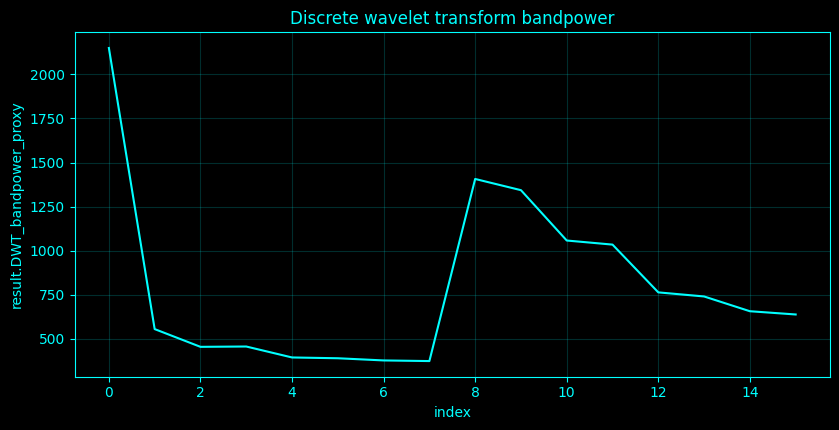

In [20]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_186():
    idx = 186
    name = 'Discrete wavelet transform bandpower'
    __plot_spec = None
    nodes = _haar_packet(X[:, 0], level=4)
    ener = np.array([np.sum(q * q) for q in nodes])
    q = ener / (ener.sum() + EPS)
    return ({'DWT_bandpower_proxy': ener.tolist()}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_186,_plot_spec=_compute_method_186()
print('Discrete wavelet transform bandpower')
if isinstance(result_186,dict):
    for _k,_v in result_186.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_186)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_186)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Discrete wavelet transform bandpower',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Discrete wavelet transform bandpower',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Discrete wavelet transform bandpower',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">187. Wavelet coherence</h3>
<p>Wavelet coherence is \(|S(W_xW_y^\ast)|^2/[S(|W_x|^2)S(|W_y|^2)]\), where \(S\) smooths in time/scale.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [21]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_187():
    idx = 187
    name = 'Wavelet coherence'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    sigt = 5
    Sxy = ndimage.gaussian_filter(np.real(cross), sigma=(1, sigt)) + 1j * ndimage.gaussian_filter(np.imag(cross), sigma=(1, sigt))
    Sxx = ndimage.gaussian_filter(np.abs(Wx) ** 2, sigma=(1, sigt))
    Syy = ndimage.gaussian_filter(np.abs(Wy) ** 2, sigma=(1, sigt))
    wc = np.abs(Sxy) ** 2 / (Sxx * Syy + EPS)
    return ({'mean_wavelet_coherence': float(np.mean(np.clip(wc, 0, 1)))}, locals().get('__plot_spec', None))
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_187,_plot_spec=_compute_method_187()
print('Wavelet coherence')
if isinstance(result_187,dict):
    for _k,_v in result_187.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_187)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_187)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Wavelet coherence
  mean_wavelet_coherence: 0.830099947029942


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">188. Wavelet cross-spectrum</h3>
<p>The cross-wavelet spectrum is \(W_{xy}(s,t)=W_x(s,t)W_y^\ast(s,t)\); magnitude gives shared local energy and angle gives local phase difference.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [22]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_188():
    idx = 188
    name = 'Wavelet cross-spectrum'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    return ({'mean_cross_wavelet_power': float(np.mean(np.abs(cross)))}, locals().get('__plot_spec', None))
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_188,_plot_spec=_compute_method_188()
print('Wavelet cross-spectrum')
if isinstance(result_188,dict):
    for _k,_v in result_188.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_188)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_188)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet cross-spectrum',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet cross-spectrum',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet cross-spectrum',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Wavelet cross-spectrum
  mean_cross_wavelet_power: 0.4088734047759262


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">189. Wavelet phase coherence</h3>
<p>Wavelet phase coherence smooths the unit phasor \(e^{i\arg(W_xW_y^\ast)}\) and summarizes its resultant magnitude.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [23]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_189():
    idx = 189
    name = 'Wavelet phase coherence'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    return ({'wavelet_phase_coherence': float(np.mean(np.abs(ndimage.gaussian_filter(np.exp(1j * np.angle(cross)), sigma=(1, 5)))))}, locals().get('__plot_spec', None))
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_189,_plot_spec=_compute_method_189()
print('Wavelet phase coherence')
if isinstance(result_189,dict):
    for _k,_v in result_189.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_189)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_189)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet phase coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet phase coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet phase coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Wavelet phase coherence
  wavelet_phase_coherence: 0.8633898421810614


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">190. Wavelet ridge extraction</h3>
<p>A wavelet ridge follows the frequency of local/maximal scalogram power over time. Its dispersion measures stability and its second time derivative provides a ridge-curvature diagnostic.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Wavelet ridge extraction
  ridge_hz: array(203,), mean=3.6497


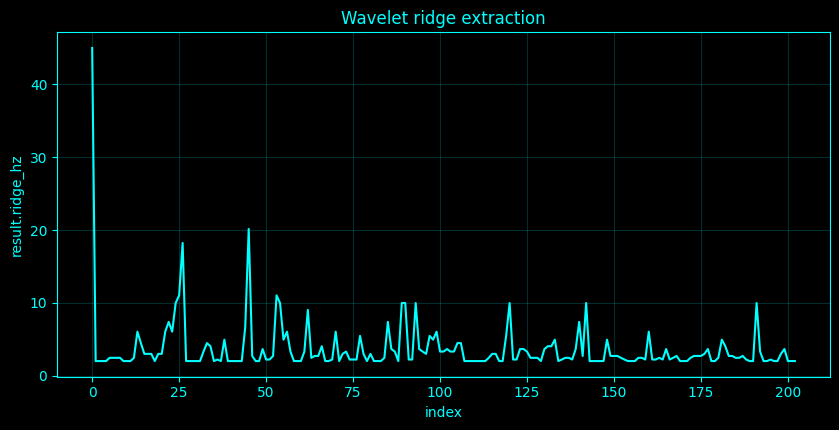

In [24]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_190():
    idx = 190
    name = 'Wavelet ridge extraction'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    return ({'ridge_hz': ridge[::max(1, len(ridge) // 200)].tolist()}, locals().get('__plot_spec', None))
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_190,_plot_spec=_compute_method_190()
print('Wavelet ridge extraction')
if isinstance(result_190,dict):
    for _k,_v in result_190.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_190)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_190)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet ridge extraction',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet ridge extraction',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet ridge extraction',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">191. Wavelet ridge stability</h3>
<p>A wavelet ridge follows the frequency of local/maximal scalogram power over time. Its dispersion measures stability and its second time derivative provides a ridge-curvature diagnostic.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [25]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_191():
    idx = 191
    name = 'Wavelet ridge stability'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    return ({'ridge_SD_hz': float(np.std(ridge))}, locals().get('__plot_spec', None))
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_191,_plot_spec=_compute_method_191()
print('Wavelet ridge stability')
if isinstance(result_191,dict):
    for _k,_v in result_191.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_191)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_191)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet ridge stability',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet ridge stability',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet ridge stability',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Wavelet ridge stability
  ridge_SD_hz: 2.93518878016739


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">192. Wavelet ridge curvature</h3>
<p>A wavelet ridge follows the frequency of local/maximal scalogram power over time. Its dispersion measures stability and its second time derivative provides a ridge-curvature diagnostic.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [26]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_192():
    idx = 192
    name = 'Wavelet ridge curvature'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    return ({'ridge_curvature_RMS_hz_per_s2': float(np.sqrt(np.mean(np.gradient(np.gradient(ridge, 1 / _fs), 1 / _fs) ** 2)))}, locals().get('__plot_spec', None))
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_192,_plot_spec=_compute_method_192()
print('Wavelet ridge curvature')
if isinstance(result_192,dict):
    for _k,_v in result_192.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_192)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_192)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet ridge curvature',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet ridge curvature',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet ridge curvature',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Wavelet ridge curvature
  ridge_curvature_RMS_hz_per_s2: 7093.038932459841


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">193. Wavelet scalogram peak tracking</h3>
<p>A wavelet ridge follows the frequency of local/maximal scalogram power over time. Its dispersion measures stability and its second time derivative provides a ridge-curvature diagnostic.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Wavelet scalogram peak tracking
  scalogram_peak_track_hz: array(203,), mean=3.6497


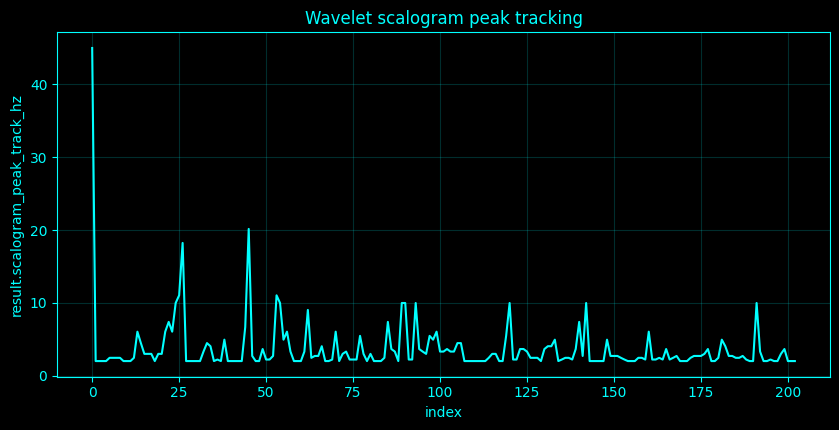

In [27]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_193():
    idx = 193
    name = 'Wavelet scalogram peak tracking'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    return ({'scalogram_peak_track_hz': ridge[::max(1, len(ridge) // 200)].tolist()}, locals().get('__plot_spec', None))
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_193,_plot_spec=_compute_method_193()
print('Wavelet scalogram peak tracking')
if isinstance(result_193,dict):
    for _k,_v in result_193.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_193)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_193)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet scalogram peak tracking',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet scalogram peak tracking',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet scalogram peak tracking',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">194. Wavelet cone-of-influence diagnostics</h3>
<p>The cone of influence marks edge regions where wavelet support overlaps record boundaries. For a Morlet wavelet the e-folding width scales with wavelet scale, so low frequencies lose a larger edge fraction.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Wavelet cone-of-influence diagnostics
  valid_fraction_by_frequency: array(32,), mean=0.995376


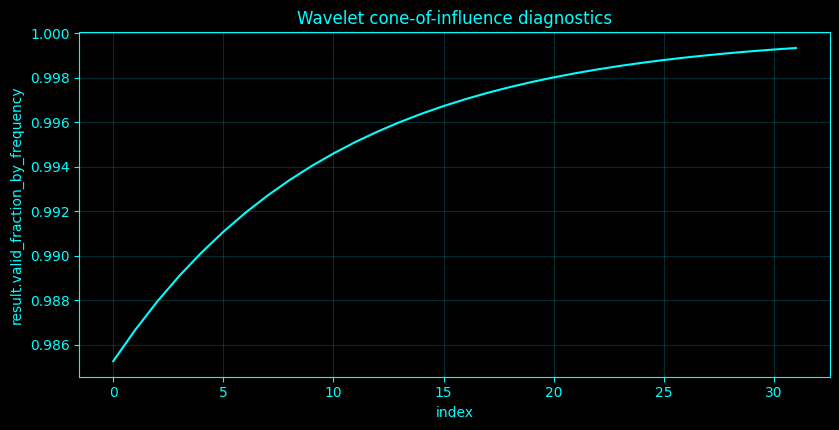

In [28]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_194():
    idx = 194
    name = 'Wavelet cone-of-influence diagnostics'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    coi = np.sqrt(2) * 7 / (2 * np.pi * fre)
    duration = N / _fs
    valid = np.maximum(0, 1 - 2 * coi / duration)
    return ({'valid_fraction_by_frequency': valid.tolist()}, locals().get('__plot_spec', None))
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_194,_plot_spec=_compute_method_194()
print('Wavelet cone-of-influence diagnostics')
if isinstance(result_194,dict):
    for _k,_v in result_194.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_194)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_194)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet cone-of-influence diagnostics',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet cone-of-influence diagnostics',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet cone-of-influence diagnostics',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">195. Wavelet surrogate testing</h3>
<p>Wavelet surrogate testing circularly shifts one channel's wavelet coefficients to destroy stable inter-channel timing while preserving each channel's time-frequency energy.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A surrogate test creates artificial signals that preserve selected simple properties of the original data while deliberately removing the structure being tested. IAAFT surrogates approximately preserve the amplitude distribution and power spectrum, and therefore much of the linear autocorrelation structure, while randomizing nonlinear temporal organization. The observed statistic is then compared with the surrogate distribution. A small surrogate-based p-value means the observed statistic is unusual under that null model; it does not by itself identify the biological mechanism responsible for the difference.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Wavelet surrogate testing
  observed: 0.8633898421810614
  surrogate_p: 0.1111111111111111


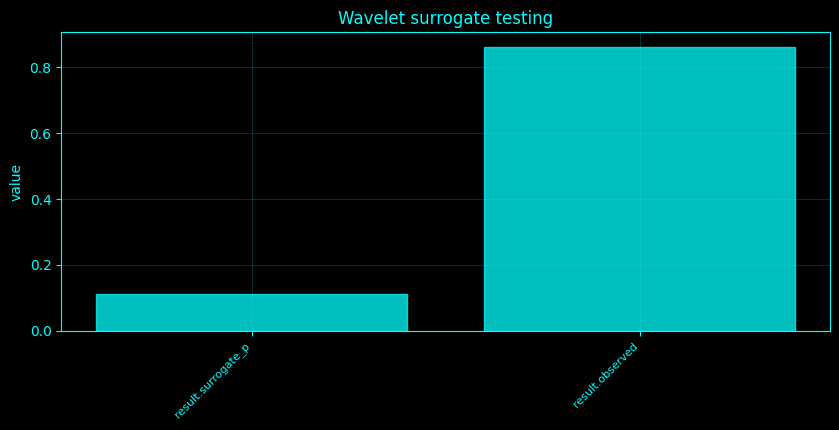

In [29]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_195():
    idx = 195
    name = 'Wavelet surrogate testing'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    obs = float(np.mean(np.abs(ndimage.gaussian_filter(np.exp(1j * np.angle(cross)), sigma=(1, 5)))))
    null = []
    for _ in range(_SPEED['n_sur']):
        sh = int(_rng.integers(int(0.2 * _fs), max(int(0.2 * _fs) + 1, N - int(0.2 * _fs))))
        Wy2 = np.roll(Wy, sh, axis=1)
        cr = Wx * np.conj(Wy2)
        null.append(float(np.mean(np.abs(ndimage.gaussian_filter(np.exp(1j * np.angle(cr)), sigma=(1, 5))))))
    return ({'observed': obs, 'surrogate_p': float((1 + np.sum(np.asarray(null) >= obs)) / (1 + len(null)))}, locals().get('__plot_spec', None))
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_195,_plot_spec=_compute_method_195()
print('Wavelet surrogate testing')
if isinstance(result_195,dict):
    for _k,_v in result_195.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_195)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_195)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet surrogate testing',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet surrogate testing',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet surrogate testing',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">196. Wavelet packet channel fingerprints</h3>
<p>Wavelet-packet channel fingerprints are normalized packet-energy vectors for each sensor.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Wavelet packet channel fingerprints
  wavelet_packet_fingerprints: array(8, 8), mean=0.125


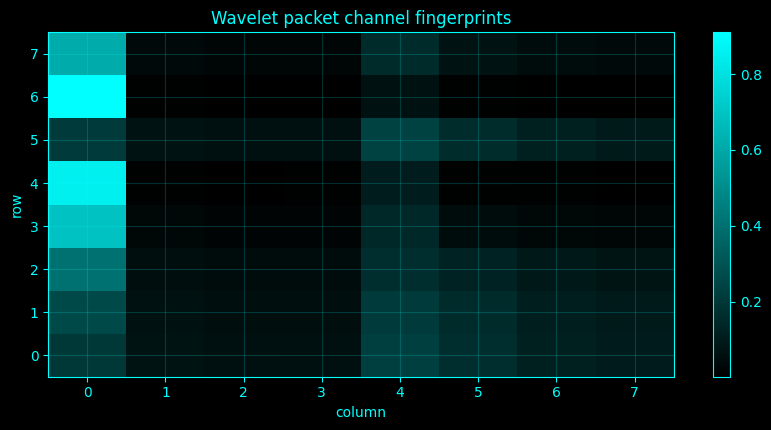

In [30]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _morlet_scalogram(ch=0, freqs=None, n_cycles=7.0):
    if freqs is None:
        freqs = np.geomspace(2, min(45, 0.4 * _fs), 32)
    y = X[:, ch]
    coeff = []
    for ff in freqs:
        sigt = n_cycles / (2 * np.pi * ff)
        half = int(max(8, 4 * sigt * _fs))
        tt = np.arange(-half, half + 1) / _fs
        w = np.exp(2j * np.pi * ff * tt) * np.exp(-tt ** 2 / (2 * sigt ** 2))
        w /= np.sqrt(np.sum(np.abs(w) ** 2) + EPS)
        coeff.append(signal.fftconvolve(y, np.conj(w[::-1]), mode='same'))
    Cw = np.asarray(coeff)
    return (np.asarray(freqs), Cw)

def _haar_packet(y, level=4):
    nodes = [np.asarray(y, float)]
    for _ in range(level):
        nxt = []
        for a in nodes:
            if len(a) % 2:
                a = a[:-1]
            lo = (a[0::2] + a[1::2]) / np.sqrt(2)
            hi = (a[0::2] - a[1::2]) / np.sqrt(2)
            nxt.extend([lo, hi])
        nodes = nxt
    return nodes

# Method-specific calculation.
def _compute_method_196():
    idx = 196
    name = 'Wavelet packet channel fingerprints'
    __plot_spec = None
    fre, Wx = _morlet_scalogram(0)
    _, Wy = _morlet_scalogram(min(1, C - 1))
    cross = Wx * np.conj(Wy)
    power = np.abs(Wx) ** 2
    ridge = fre[np.argmax(power, axis=0)]
    rows = []
    for j in range(min(C, 8 if FAST_OPTION == 'ultra' else C)):
        nds = _haar_packet(X[:, j], level=3)
        e = np.array([np.sum(q * q) for q in nds])
        rows.append(e / (e.sum() + EPS))
    return ({'wavelet_packet_fingerprints': np.asarray(rows)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_196,_plot_spec=_compute_method_196()
print('Wavelet packet channel fingerprints')
if isinstance(result_196,dict):
    for _k,_v in result_196.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_196)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_196)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Wavelet packet channel fingerprints',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Wavelet packet channel fingerprints',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Wavelet packet channel fingerprints',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">197. Filter-bank spectral analysis</h3>
<p>A constant-Q/log-spaced filter bank uses geometrically spaced center frequencies and bandwidth proportional to center frequency, so \(Q=f_c/\Delta f\) is approximately constant.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Filter-bank spectral analysis
  centers_hz: array(12,), mean=14.7026
  power_shape: array(2,), mean=12


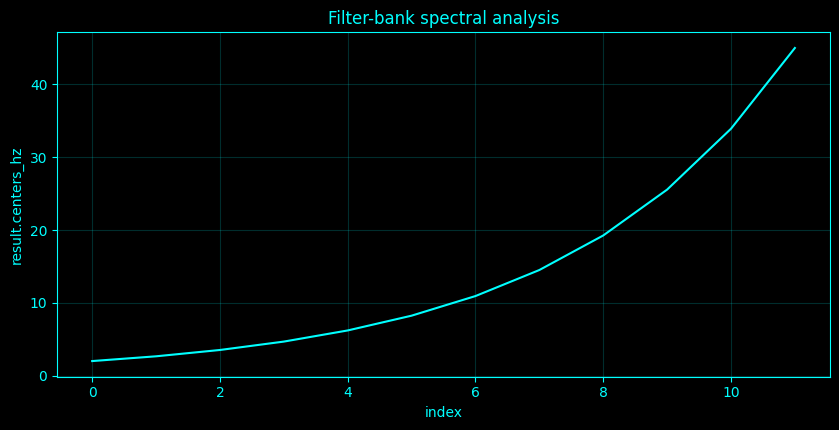

In [31]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_197():
    idx = 197
    name = 'Filter-bank spectral analysis'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    return ({'centers_hz': centers.tolist(), 'power_shape': powers.shape}, locals().get('__plot_spec', None))
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_197,_plot_spec=_compute_method_197()
print('Filter-bank spectral analysis')
if isinstance(result_197,dict):
    for _k,_v in result_197.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_197)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_197)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Filter-bank spectral analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Filter-bank spectral analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Filter-bank spectral analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">198. Log-spaced filter-bank power</h3>
<p>A constant-Q/log-spaced filter bank uses geometrically spaced center frequencies and bandwidth proportional to center frequency, so \(Q=f_c/\Delta f\) is approximately constant.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Log-spaced filter-bank power
  log_spaced_centers_hz: array(12,), mean=14.7026
  mean_power: array(12,), mean=0.571631


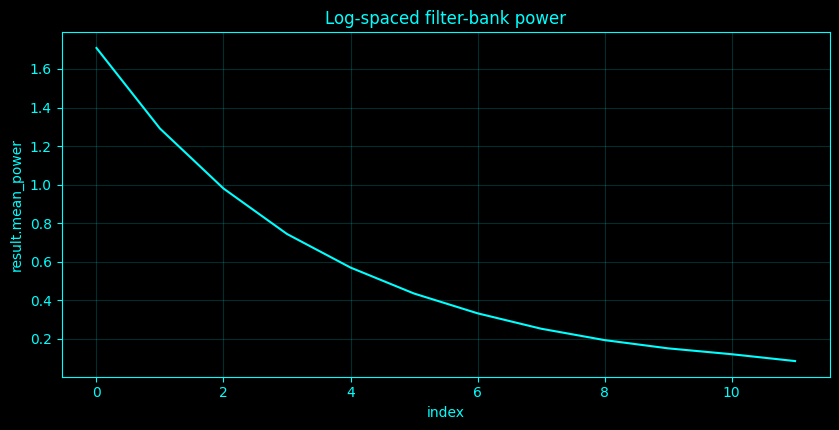

In [32]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_198():
    idx = 198
    name = 'Log-spaced filter-bank power'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    return ({'log_spaced_centers_hz': centers.tolist(), 'mean_power': np.mean(powers, axis=1).tolist()}, locals().get('__plot_spec', None))
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_198,_plot_spec=_compute_method_198()
print('Log-spaced filter-bank power')
if isinstance(result_198,dict):
    for _k,_v in result_198.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_198)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_198)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Log-spaced filter-bank power',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Log-spaced filter-bank power',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Log-spaced filter-bank power',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">199. Constant-Q transform</h3>
<p>A constant-Q/log-spaced filter bank uses geometrically spaced center frequencies and bandwidth proportional to center frequency, so \(Q=f_c/\Delta f\) is approximately constant.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Constant-Q transform
  constant_Q_centers_hz: array(12,), mean=14.7026
  Q_approx: 1.4142135623730947


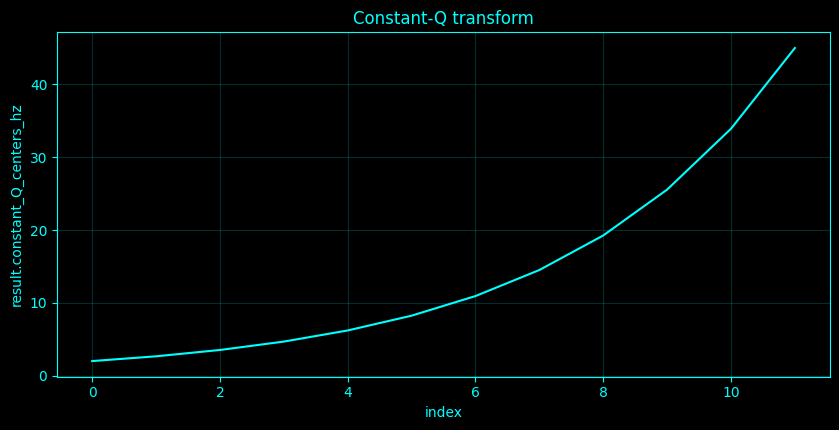

In [33]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_199():
    idx = 199
    name = 'Constant-Q transform'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    return ({'constant_Q_centers_hz': centers.tolist(), 'Q_approx': float(1 / (np.sqrt(2) - 1 / np.sqrt(2)))}, locals().get('__plot_spec', None))
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_199,_plot_spec=_compute_method_199()
print('Constant-Q transform')
if isinstance(result_199,dict):
    for _k,_v in result_199.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_199)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_199)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Constant-Q transform',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Constant-Q transform',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Constant-Q transform',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">200. Mel-like EEG spectral bank</h3>
<p>A mel-like EEG bank spaces spectral bins uniformly on \(m=2595\log_{10}(1+f/700)\), then maps them back to hertz. It is used only as a multiresolution feature bank, not as an auditory claim about EEG.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Mel-like EEG spectral bank
  bank_edges_hz: array(14,), mean=22.794
  bank_power: array(13,), mean=0.00249628


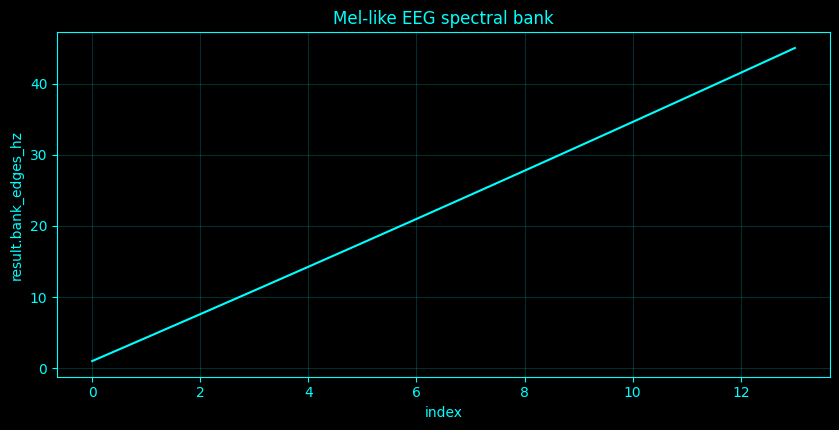

In [34]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_200():
    idx = 200
    name = 'Mel-like EEG spectral bank'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    scale = lambda hz: 2595 * np.log10(1 + hz / 700)
    inv = lambda m: 700 * (10 ** (m / 2595) - 1)
    pts = inv(np.linspace(scale(1), scale(min(45, 0.45 * _fs)), 14))
    vals = []
    for a, b in zip(pts[:-1], pts[1:]):
        vals.append(float(_band_integral(p[:, None], f, (a, b))[0]))
    return ({'bank_edges_hz': pts.tolist(), 'bank_power': vals}, locals().get('__plot_spec', None))
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_200,_plot_spec=_compute_method_200()
print('Mel-like EEG spectral bank')
if isinstance(result_200,dict):
    for _k,_v in result_200.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_200)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_200)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Mel-like EEG spectral bank',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Mel-like EEG spectral bank',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Mel-like EEG spectral bank',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">201. ERB-like EEG spectral bank</h3>
<p>An ERB-like bank uses the equivalent-rectangular-bandwidth scale \(E=21.4\log_{10}(1+0.00437f)\) to define nonuniform spectral bins.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


ERB-like EEG spectral bank
  bank_edges_hz: array(14,), mean=22.4074
  bank_power: array(13,), mean=0.00247459


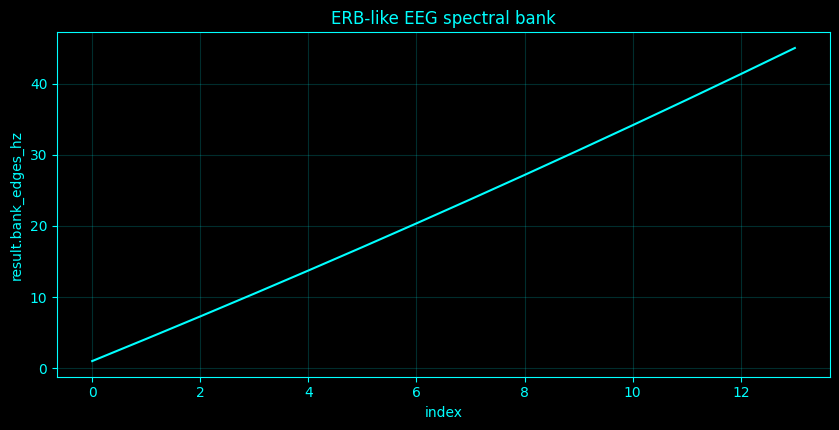

In [35]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _band_integral(P, f, band):
    lo, hi = band
    m = (f >= lo) & (f < hi)
    if not np.any(m):
        return np.full(P.shape[1:], np.nan)
    if np.sum(m) == 1:
        df = np.median(np.diff(f)) if len(f) > 1 else 1.0
        return P[m][0] * df
    return np.trapz(P[m], f[m], axis=0)

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_201():
    idx = 201
    name = 'ERB-like EEG spectral bank'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    scale = lambda hz: 21.4 * np.log10(1 + 0.00437 * hz)
    inv = lambda e: (10 ** (e / 21.4) - 1) / 0.00437
    pts = inv(np.linspace(scale(1), scale(min(45, 0.45 * _fs)), 14))
    vals = []
    for a, b in zip(pts[:-1], pts[1:]):
        vals.append(float(_band_integral(p[:, None], f, (a, b))[0]))
    return ({'bank_edges_hz': pts.tolist(), 'bank_power': vals}, locals().get('__plot_spec', None))
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_201,_plot_spec=_compute_method_201()
print('ERB-like EEG spectral bank')
if isinstance(result_201,dict):
    for _k,_v in result_201.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_201)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_201)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'ERB-like EEG spectral bank',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'ERB-like EEG spectral bank',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('ERB-like EEG spectral bank',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">202. Gabor filter-bank analysis</h3>
<p>A Gabor filter is a complex sinusoid multiplied by a Gaussian window. A Gabor bank measures localized energy at several center frequencies.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Gabor filter-bank analysis
  Gabor_energy: array(12,), mean=7.42237


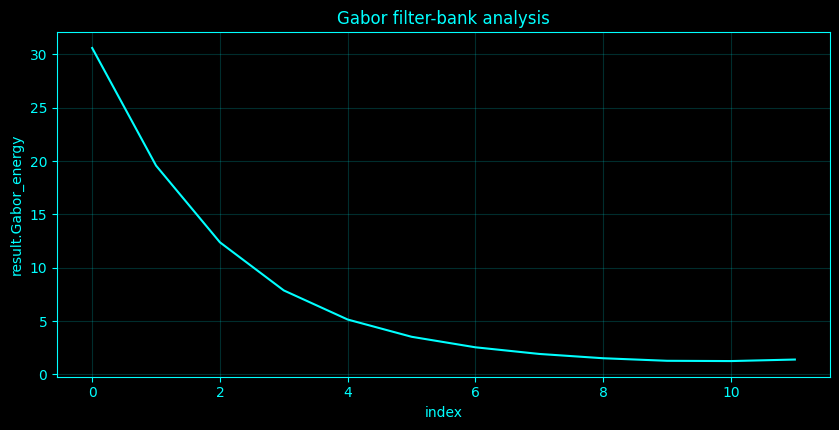

In [36]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_202():
    idx = 202
    name = 'Gabor filter-bank analysis'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    vals = []
    for fc in centers:
        sigma = 2 / (2 * np.pi * fc)
        half = int(max(8, 4 * sigma * _fs))
        tt = np.arange(-half, half + 1) / _fs
        g = np.exp(-tt ** 2 / (2 * sigma ** 2)) * np.exp(2j * np.pi * fc * tt)
        z = signal.fftconvolve(X[:, 0], g, mode='same')
        vals.append(float(np.mean(np.abs(z) ** 2)))
    return ({'Gabor_energy': vals}, locals().get('__plot_spec', None))
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_202,_plot_spec=_compute_method_202()
print('Gabor filter-bank analysis')
if isinstance(result_202,dict):
    for _k,_v in result_202.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_202)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_202)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Gabor filter-bank analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Gabor filter-bank analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Gabor filter-bank analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">203. Multiresolution bandpower</h3>
<p>Multiresolution bandpower integrates energy from a geometric filter bank whose bandwidth grows with center frequency.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Multiresolution bandpower
  multiresolution_bandpower: {2.0: 1.709034056070485, 2.65433466645825: 1.290832865245019, 3.522746260781014: 0.979802441011041, 4.67527376056361: 0.7437311501762688, 6.20487060892331: 0.56


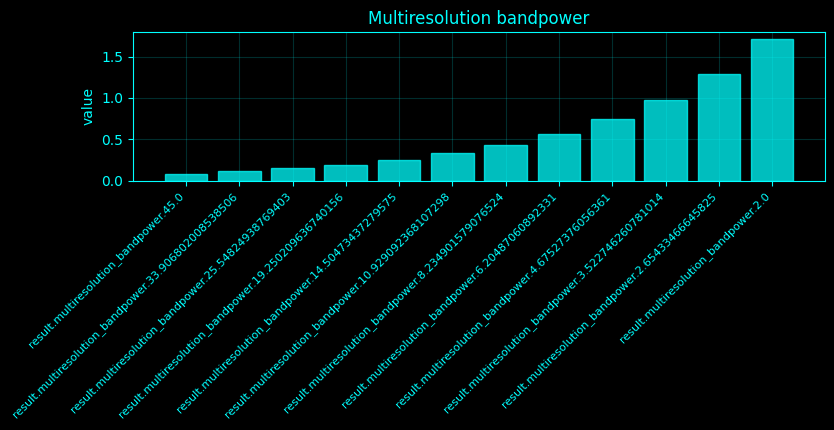

In [37]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_203():
    idx = 203
    name = 'Multiresolution bandpower'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    return ({'multiresolution_bandpower': dict(zip(centers.tolist(), np.mean(powers, axis=1).tolist()))}, locals().get('__plot_spec', None))
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_203,_plot_spec=_compute_method_203()
print('Multiresolution bandpower')
if isinstance(result_203,dict):
    for _k,_v in result_203.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_203)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_203)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Multiresolution bandpower',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Multiresolution bandpower',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Multiresolution bandpower',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">204. Filter-bank coherence</h3>
<p>Filter-bank coherence computes normalized cross-power separately in each narrowband analytic filter output.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Filter-bank coherence
  filterbank_coherence: array(12,), mean=0.999277


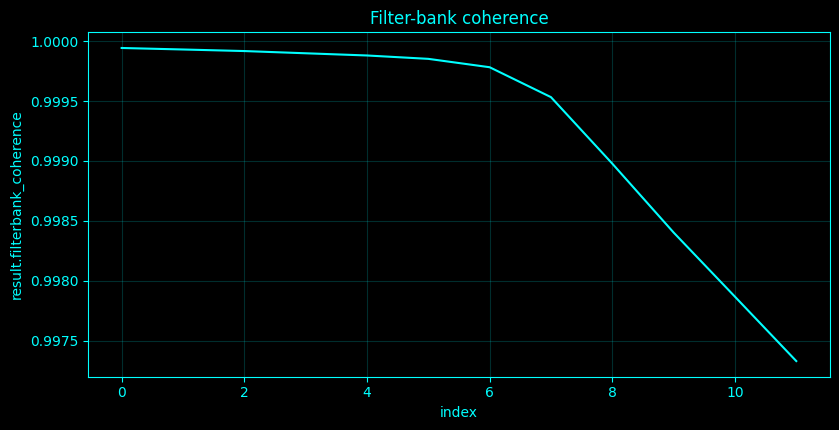

In [38]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_204():
    idx = 204
    name = 'Filter-bank coherence'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    vals = []
    for z in analytic:
        vals.append(float(np.abs(np.mean(z[:, 0] * np.conj(z[:, 1]))) ** 2 / (np.mean(np.abs(z[:, 0]) ** 2) * np.mean(np.abs(z[:, 1]) ** 2) + EPS)))
    return ({'filterbank_coherence': vals}, locals().get('__plot_spec', None))
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_204,_plot_spec=_compute_method_204()
print('Filter-bank coherence')
if isinstance(result_204,dict):
    for _k,_v in result_204.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_204)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_204)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Filter-bank coherence',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Filter-bank coherence',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Filter-bank coherence',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">205. Filter-bank phase locking</h3>
<p>Filter-bank phase locking applies PLV to analytic phases within each filter-bank band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Filter-bank phase locking
  filterbank_PLV: array(12,), mean=0.826492


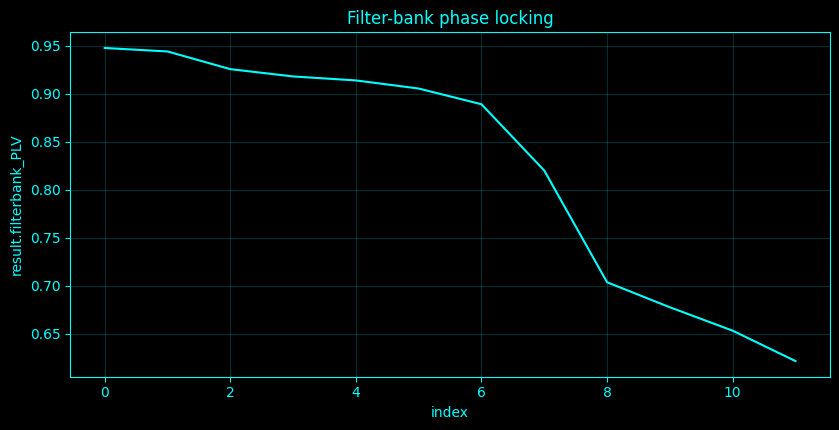

In [39]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_205():
    idx = 205
    name = 'Filter-bank phase locking'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    return ({'filterbank_PLV': [float(np.abs(np.mean(np.exp(1j * (np.angle(z[:, 0]) - np.angle(z[:, 1])))))) for z in analytic]}, locals().get('__plot_spec', None))
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_205,_plot_spec=_compute_method_205()
print('Filter-bank phase locking')
if isinstance(result_205,dict):
    for _k,_v in result_205.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_205)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_205)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Filter-bank phase locking',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Filter-bank phase locking',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Filter-bank phase locking',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">206. Filter-bank entropy</h3>
<p>Filter-bank entropy normalizes a channel's filter-bank powers \(p_k\) and computes \(-\sum_kp_k\log p_k/\log K\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Filter-bank entropy
  channel_filterbank_entropy: array(12,), mean=0.878879


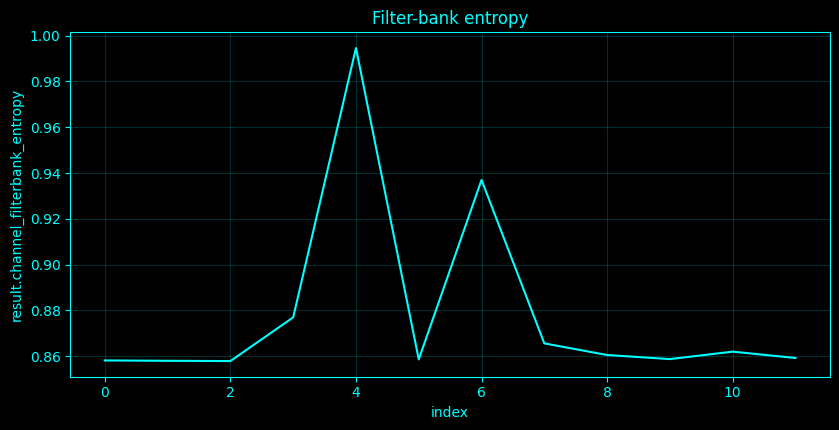

In [40]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_206():
    idx = 206
    name = 'Filter-bank entropy'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    q = powers / (np.sum(powers, axis=0, keepdims=True) + EPS)
    H = -np.sum(q * np.log(q + EPS), axis=0) / np.log(len(q))
    return ({'channel_filterbank_entropy': H.tolist()}, locals().get('__plot_spec', None))
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_206,_plot_spec=_compute_method_206()
print('Filter-bank entropy')
if isinstance(result_206,dict):
    for _k,_v in result_206.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_206)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_206)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Filter-bank entropy',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Filter-bank entropy',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Filter-bank entropy',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">207. Filter-bank feature fingerprints</h3>
<p>Filter-bank feature fingerprints are standardized vectors of multiresolution band powers for each channel.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Filter-bank feature fingerprints
  filterbank_fingerprints: array(12, 12), mean=7.40149e-17


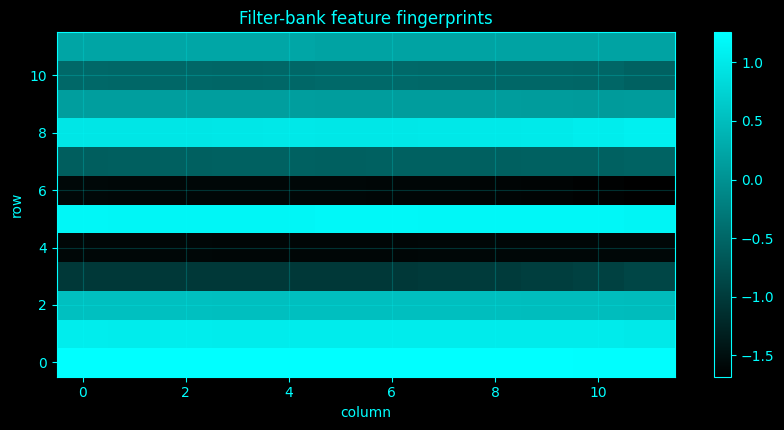

In [41]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _welch_all():
    if 'welch' in SPEC_CACHE:
        return SPEC_CACHE['welch']
    nper = min(int(_SPEED['nperseg']), N)
    nover = min(int(_SPEED['overlap'] * nper), nper - 1)
    f, P = signal.welch(X, fs=_fs, axis=0, nperseg=nper, noverlap=nover, detrend='constant', scaling='density')
    keep = f <= min(55.0, 0.49 * _fs)
    SPEC_CACHE['welch'] = (f[keep], P[keep])
    return SPEC_CACHE['welch']

def _filterbank():
    centers = np.geomspace(2, min(45, 0.4 * _fs), 12)
    powers = []
    analytic = []
    for fc in centers:
        lo = max(0.5, fc / np.sqrt(2))
        hi = min(0.45 * _fs, fc * np.sqrt(2))
        if lo >= hi:
            continue
        sos = signal.butter(3, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
        Y = signal.sosfiltfilt(sos, X, axis=0)
        powers.append(np.mean(Y ** 2, axis=0))
        analytic.append(signal.hilbert(Y, axis=0))
    return (centers[:len(powers)], np.asarray(powers), analytic)

# Method-specific calculation.
def _compute_method_207():
    idx = 207
    name = 'Filter-bank feature fingerprints'
    __plot_spec = None
    centers, powers, analytic = _filterbank()
    f, P = _welch_all()
    p = np.mean(P, axis=1)
    F = powers.T
    F = (F - F.mean(0)) / (F.std(0) + EPS)
    return ({'filterbank_fingerprints': F}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_207,_plot_spec=_compute_method_207()
print('Filter-bank feature fingerprints')
if isinstance(result_207,dict):
    for _k,_v in result_207.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_207)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_207)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Filter-bank feature fingerprints',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Filter-bank feature fingerprints',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Filter-bank feature fingerprints',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">208. Event-related spectral perturbation</h3>
<p>Event-related spectral perturbation averages event-centered spectrogram power and normalizes each frequency to a pre-event baseline, here in decibels: \(\mathrm{ERSP}(f,t)=10\log_{10}[P(f,t)/P_{base}(f)]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [42]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_208():
    idx = 208
    name = 'Event-related spectral perturbation'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)
    __plot_spec = ('summary', ersp_db, name, None, '', 'value')
    return ({'events_used': int(A.shape[0]), 'baseline_normalization': '10log10(P/Pbaseline)'}, locals().get('__plot_spec', None))

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_208,_plot_spec=_compute_method_208()
print('Event-related spectral perturbation')
if isinstance(result_208,dict):
    for _k,_v in result_208.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_208)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_208)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Event-related spectral perturbation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Event-related spectral perturbation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Event-related spectral perturbation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Event-related spectral perturbation
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">209. ERSP analysis</h3>
<p>Event-related spectral perturbation averages event-centered spectrogram power and normalizes each frequency to a pre-event baseline, here in decibels: \(\mathrm{ERSP}(f,t)=10\log_{10}[P(f,t)/P_{base}(f)]\).</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [43]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_209():
    idx = 209
    name = 'ERSP analysis'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)
    __plot_spec = ('summary', ersp_db, name, None, '', 'value')
    return ({'events_used': int(A.shape[0]), 'baseline_normalization': '10log10(P/Pbaseline)'}, locals().get('__plot_spec', None))

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_209,_plot_spec=_compute_method_209()
print('ERSP analysis')
if isinstance(result_209,dict):
    for _k,_v in result_209.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_209)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_209)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'ERSP analysis',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'ERSP analysis',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('ERSP analysis',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


ERSP analysis
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">210. Event-related synchronization</h3>
<p>Event-related synchronization is a positive post-event increase in baseline-normalized spectral power.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [44]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_210():
    idx = 210
    name = 'Event-related synchronization'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    return ({'ERS_peak_db': float(np.nanmax(ersp_db[:, post]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_210,_plot_spec=_compute_method_210()
print('Event-related synchronization')
if isinstance(result_210,dict):
    for _k,_v in result_210.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_210)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_210)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Event-related synchronization',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Event-related synchronization',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Event-related synchronization',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Event-related synchronization
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">211. Event-related desynchronization</h3>
<p>Event-related desynchronization is a negative post-event change in baseline-normalized spectral power.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [45]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_211():
    idx = 211
    name = 'Event-related desynchronization'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    return ({'ERD_min_db': float(np.nanmin(ersp_db[:, post]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_211,_plot_spec=_compute_method_211()
print('Event-related desynchronization')
if isinstance(result_211,dict):
    for _k,_v in result_211.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_211)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_211)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Event-related desynchronization',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Event-related desynchronization',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Event-related desynchronization',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Event-related desynchronization
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">212. Baseline-normalized ERD/ERS</h3>
<p>Percent ERD/ERS is \(100[P(f,t)-P_{base}(f)]/P_{base}(f)\), complementary to the dB ERSP convention.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [46]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_212():
    idx = 212
    name = 'Baseline-normalized ERD/ERS'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    pct = 100 * (meanP - B) / (B + EPS)
    return ({'mean_post_percent_change': float(np.nanmean(pct[:, post]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_212,_plot_spec=_compute_method_212()
print('Baseline-normalized ERD/ERS')
if isinstance(result_212,dict):
    for _k,_v in result_212.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_212)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_212)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Baseline-normalized ERD/ERS',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Baseline-normalized ERD/ERS',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Baseline-normalized ERD/ERS',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Baseline-normalized ERD/ERS
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">213. Event-locked alpha suppression</h3>
<p>Event-locked alpha suppression is the minimum post-event 8–13-Hz ERSP relative to the pre-event baseline.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [47]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_213():
    idx = 213
    name = 'Event-locked alpha suppression'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    return ({'alpha_suppression_db': float(np.nanmin(alpha[post]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_213,_plot_spec=_compute_method_213()
print('Event-locked alpha suppression')
if isinstance(result_213,dict):
    for _k,_v in result_213.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_213)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_213)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Event-locked alpha suppression',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Event-locked alpha suppression',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Event-locked alpha suppression',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Event-locked alpha suppression
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">214. Event-locked beta rebound</h3>
<p>Event-locked beta rebound is the maximum post-event 13–30-Hz ERSP after baseline normalization.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [48]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_214():
    idx = 214
    name = 'Event-locked beta rebound'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    return ({'beta_rebound_db': float(np.nanmax(beta[post]))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_214,_plot_spec=_compute_method_214()
print('Event-locked beta rebound')
if isinstance(result_214,dict):
    for _k,_v in result_214.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_214)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_214)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Event-locked beta rebound',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Event-locked beta rebound',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Event-locked beta rebound',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Event-locked beta rebound
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">215. Event-locked gamma burst detection</h3>
<p>Event-locked gamma burst detection flags high post-event gamma ERSP bins relative to their within-record distribution.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [49]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_215():
    idx = 215
    name = 'Event-locked gamma burst detection'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    th = np.nanquantile(gamma[post], 0.9) if np.any(post) else np.nan
    return ({'gamma_event_bins_above_q90': int(np.sum(gamma[post] >= th))}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_215,_plot_spec=_compute_method_215()
print('Event-locked gamma burst detection')
if isinstance(result_215,dict):
    for _k,_v in result_215.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_215)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_215)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Event-locked gamma burst detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Event-locked gamma burst detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Event-locked gamma burst detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Event-locked gamma burst detection
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">216. Trial-like pseudo-epoch spectral perturbation</h3>
<p>Pseudo-epoch spectral perturbation uses internally detected events only when external event labels are unavailable; the notebook explicitly marks these as demonstration epochs.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [50]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_216():
    idx = 216
    name = 'Trial-like pseudo-epoch spectral perturbation'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    return ({'pseudo_epoch_note': 'events are internally detected unless SPECTRAL_EVENT_INDICES is supplied', 'ERSP_shape': ersp_db.shape}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_216,_plot_spec=_compute_method_216()
print('Trial-like pseudo-epoch spectral perturbation')
if isinstance(result_216,dict):
    for _k,_v in result_216.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_216)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_216)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Trial-like pseudo-epoch spectral perturbation',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Trial-like pseudo-epoch spectral perturbation',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Trial-like pseudo-epoch spectral perturbation',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Trial-like pseudo-epoch spectral perturbation
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">217. Stimulus-locked spectrogram averaging</h3>
<p>Stimulus/event-locked spectrogram averaging is a simple arithmetic mean of time-aligned event spectrograms. It represents stimulus locking only when real event indices are supplied.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [51]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_217():
    idx = 217
    name = 'Stimulus-locked spectrogram averaging'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    return ({'event_source': 'supplied stimulus/event indices' if 'SPECTRAL_EVENT_INDICES' in globals() else 'internal amplitude-event demonstration', 'average_spectrogram': meanP}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_217,_plot_spec=_compute_method_217()
print('Stimulus-locked spectrogram averaging')
if isinstance(result_217,dict):
    for _k,_v in result_217.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_217)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_217)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Stimulus-locked spectrogram averaging',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Stimulus-locked spectrogram averaging',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Stimulus-locked spectrogram averaging',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Stimulus-locked spectrogram averaging
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">218. Burst-locked spectrogram averaging</h3>
<p>Burst-locked spectrogram averaging aligns windows to detected oscillation-burst peaks rather than experimental events.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [52]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _psd_of(data, fs=None, nperseg=None, window='hann', detrend='constant'):
    fs = _fs if fs is None else fs
    nperseg = min(int(nperseg or _SPEED['nperseg']), len(data))
    f, p = signal.welch(data, fs=fs, axis=0, nperseg=nperseg, noverlap=nperseg // 2, window=window, detrend=detrend, scaling='density')
    keep = f <= min(55, 0.49 * fs)
    return (f[keep], p[keep])

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_218():
    idx = 218
    name = 'Burst-locked spectrogram averaging'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    bursts = _burst_table(BANDS['beta'])
    peaks = np.array([r[3] for r in bursts], int)
    if len(peaks) == 0:
        return ({'status': 'no beta bursts'}, locals().get('__plot_spec', None))
    vals = []
    half = int(0.5 * _fs)
    for e in peaks[:_SPEED['n_windows']]:
        if e - half >= 0 and e + half < N:
            ff, pp = _psd_of(X[e - half:e + half, [0]])
            vals.append(pp[:, 0])
    return ({'burst_locked_windows': len(vals)}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_218,_plot_spec=_compute_method_218()
print('Burst-locked spectrogram averaging')
if isinstance(result_218,dict):
    for _k,_v in result_218.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_218)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_218)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst-locked spectrogram averaging',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst-locked spectrogram averaging',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst-locked spectrogram averaging',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Burst-locked spectrogram averaging
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">219. Spectral response latency</h3>
<p>Spectral response latency is the first post-event threshold crossing, duration is the total above-threshold time, and response area is the time integral of the baseline-normalized band response.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [53]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_219():
    idx = 219
    name = 'Spectral response latency'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    y = alpha if idx in (219, 220, 221) else beta
    yp = np.abs(y[post])
    tp = tE[post]
    if len(yp) == 0:
        return ({'status': 'no post-event bins'}, locals().get('__plot_spec', None))
    threshold = 0.2 * np.nanmax(yp)
    mask = yp >= threshold
    return ({'latency_s': float(tp[np.argmax(mask)]) if np.any(mask) else np.nan}, locals().get('__plot_spec', None))
    return ({'response_AUC_db_s': float(np.trapz(y[post], tp)) if len(tp) > 1 else 0.0}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_219,_plot_spec=_compute_method_219()
print('Spectral response latency')
if isinstance(result_219,dict):
    for _k,_v in result_219.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_219)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_219)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral response latency',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral response latency',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral response latency',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral response latency
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">220. Spectral response duration</h3>
<p>Spectral response latency is the first post-event threshold crossing, duration is the total above-threshold time, and response area is the time integral of the baseline-normalized band response.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [54]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_220():
    idx = 220
    name = 'Spectral response duration'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    y = alpha if idx in (219, 220, 221) else beta
    yp = np.abs(y[post])
    tp = tE[post]
    if len(yp) == 0:
        return ({'status': 'no post-event bins'}, locals().get('__plot_spec', None))
    threshold = 0.2 * np.nanmax(yp)
    mask = yp >= threshold
    return ({'duration_s': float(np.sum(mask) * np.median(np.diff(tp))) if len(tp) > 1 else 0.0}, locals().get('__plot_spec', None))
    return ({'response_AUC_db_s': float(np.trapz(y[post], tp)) if len(tp) > 1 else 0.0}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_220,_plot_spec=_compute_method_220()
print('Spectral response duration')
if isinstance(result_220,dict):
    for _k,_v in result_220.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_220)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_220)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral response duration',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral response duration',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral response duration',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral response duration
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">221. Spectral response area under curve</h3>
<p>Spectral response latency is the first post-event threshold crossing, duration is the total above-threshold time, and response area is the time integral of the baseline-normalized band response.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [55]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _event_indices():
    if 'SPECTRAL_EVENT_INDICES' in globals():
        e = np.asarray(globals()['SPECTRAL_EVENT_INDICES'], int)
        return e[(e > int(_fs)) & (e < N - int(_fs))]
    env = np.mean(np.abs(_analytic_band(BANDS['alpha'])), axis=1)
    dist = max(1, int(_fs))
    p, _ = signal.find_peaks(env, distance=dist, prominence=np.std(env) * 0.5)
    return p

def _event_spectra():
    ev = _event_indices()
    pre = 0.75
    post = 1.25
    npre = int(pre * _fs)
    npost = int(post * _fs)
    f_ref = None
    arr = []
    for e in ev[:max(4, _SPEED['n_windows'])]:
        a = e - npre
        b = e + npost
        if a < 0 or b > N:
            continue
        f, t, Z = signal.stft(X[a:b, 0], fs=_fs, nperseg=min(128, b - a), noverlap=min(96, max(0, b - a - 1)), boundary=None)
        keep = (f >= 1) & (f <= min(45, 0.45 * _fs))
        arr.append(np.abs(Z[keep]) ** 2)
        f_ref = f[keep]
        t_ref = t - pre
    if not arr:
        return (None, None, None)
    nt = min((q.shape[1] for q in arr))
    A = np.stack([q[:, :nt] for q in arr])
    return (f_ref, t_ref[:nt], A)

# Method-specific calculation.
def _compute_method_221():
    idx = 221
    name = 'Spectral response area under curve'
    __plot_spec = None
    fE, tE, A = _event_spectra()
    if A is None:
        return ({'status': 'no valid events in the current segment'}, locals().get('__plot_spec', None))
    meanP = np.mean(A, axis=0)
    base = tE < 0
    if not np.any(base):
        base = np.arange(len(tE)) < max(1, len(tE) // 4)
    B = np.mean(meanP[:, base], axis=1, keepdims=True) + EPS
    ersp_db = 10 * np.log10((meanP + EPS) / B)

    def band_curve(band):
        m = (fE >= band[0]) & (fE < min(band[1], 0.49 * _fs))
        return np.mean(ersp_db[m], axis=0) if np.any(m) else np.full(len(tE), np.nan)
    alpha = band_curve(BANDS['alpha'])
    beta = band_curve(BANDS['beta'])
    gamma = band_curve(BANDS['gamma'])
    post = tE >= 0
    y = alpha if idx in (219, 220, 221) else beta
    yp = np.abs(y[post])
    tp = tE[post]
    if len(yp) == 0:
        return ({'status': 'no post-event bins'}, locals().get('__plot_spec', None))
    threshold = 0.2 * np.nanmax(yp)
    mask = yp >= threshold
    return ({'response_AUC_db_s': float(np.trapz(y[post], tp)) if len(tp) > 1 else 0.0}, locals().get('__plot_spec', None))
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_221,_plot_spec=_compute_method_221()
print('Spectral response area under curve')
if isinstance(result_221,dict):
    for _k,_v in result_221.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_221)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_221)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Spectral response area under curve',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Spectral response area under curve',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Spectral response area under curve',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


Spectral response area under curve
  status: no valid events in the current segment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">222. Oscillation burst detection</h3>
<p>Oscillation bursts are contiguous periods where a narrow-band analytic envelope exceeds a channel-specific high quantile for a minimum duration.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Oscillation burst detection
  burst_counts: {'delta': 746, 'theta': 1636, 'alpha': 1416, 'beta': 2917, 'gamma': 3071}


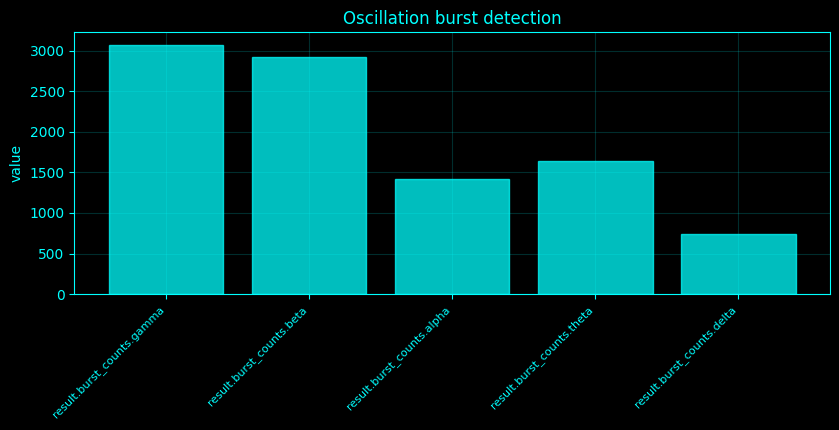

In [56]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_222():
    idx = 222
    name = 'Oscillation burst detection'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    counts = {bn: len(_burst_table(b)) for bn, b in BANDS.items()}
    return ({'burst_counts': counts}, locals().get('__plot_spec', None))
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_222,_plot_spec=_compute_method_222()
print('Oscillation burst detection')
if isinstance(result_222,dict):
    for _k,_v in result_222.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_222)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_222)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Oscillation burst detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Oscillation burst detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Oscillation burst detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">223. Alpha burst detection</h3>
<p>Alpha bursts use the same envelope-threshold/minimum-duration definition applied specifically to the alpha band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Alpha burst detection
  band: array(2,), mean=10.5
  bursts: 1416


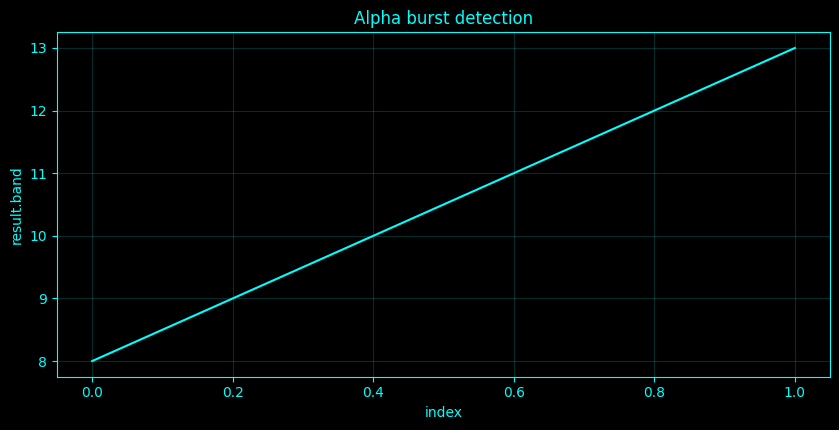

In [57]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_223():
    idx = 223
    name = 'Alpha burst detection'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_223,_plot_spec=_compute_method_223()
print('Alpha burst detection')
if isinstance(result_223,dict):
    for _k,_v in result_223.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_223)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_223)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Alpha burst detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Alpha burst detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Alpha burst detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">224. Beta burst detection</h3>
<p>Beta bursts use the same envelope-threshold/minimum-duration definition applied specifically to the beta band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Beta burst detection
  band: array(2,), mean=21.5
  bursts: 2917


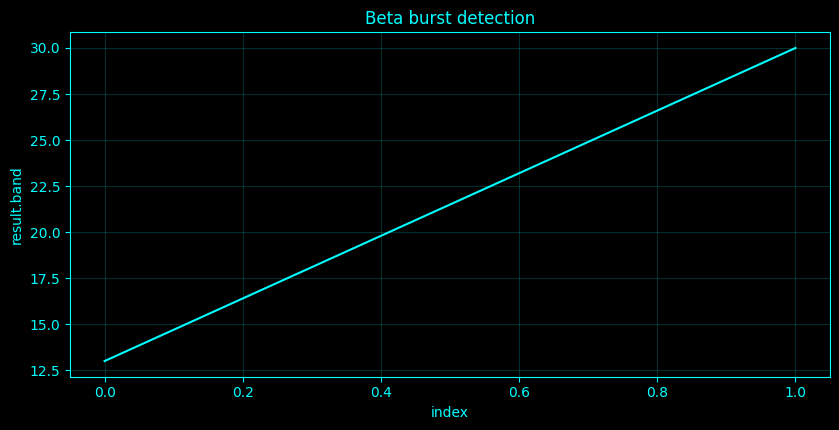

In [58]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_224():
    idx = 224
    name = 'Beta burst detection'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_224,_plot_spec=_compute_method_224()
print('Beta burst detection')
if isinstance(result_224,dict):
    for _k,_v in result_224.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_224)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_224)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Beta burst detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Beta burst detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Beta burst detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">225. Theta burst detection</h3>
<p>Theta bursts use the same envelope-threshold/minimum-duration definition applied specifically to the theta band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Theta burst detection
  band: array(2,), mean=6
  bursts: 1636


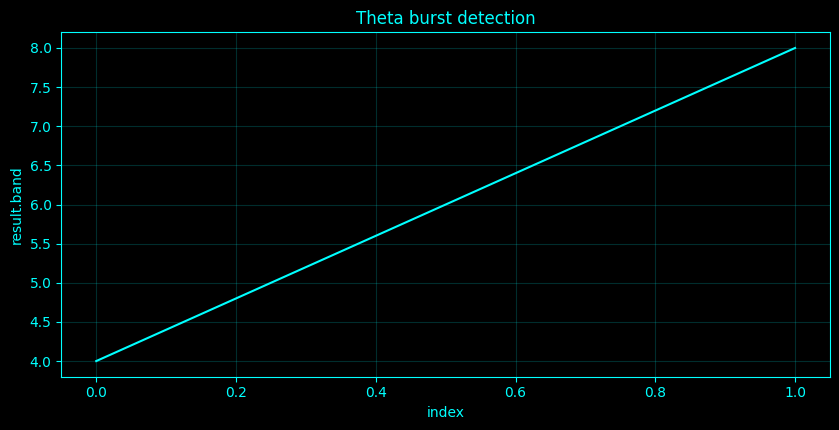

In [59]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_225():
    idx = 225
    name = 'Theta burst detection'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_225,_plot_spec=_compute_method_225()
print('Theta burst detection')
if isinstance(result_225,dict):
    for _k,_v in result_225.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_225)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_225)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Theta burst detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Theta burst detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Theta burst detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">226. Gamma burst detection</h3>
<p>Gamma bursts use the same envelope-threshold/minimum-duration definition applied specifically to the gamma band.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Gamma burst detection
  band: array(2,), mean=37.5
  bursts: 3071


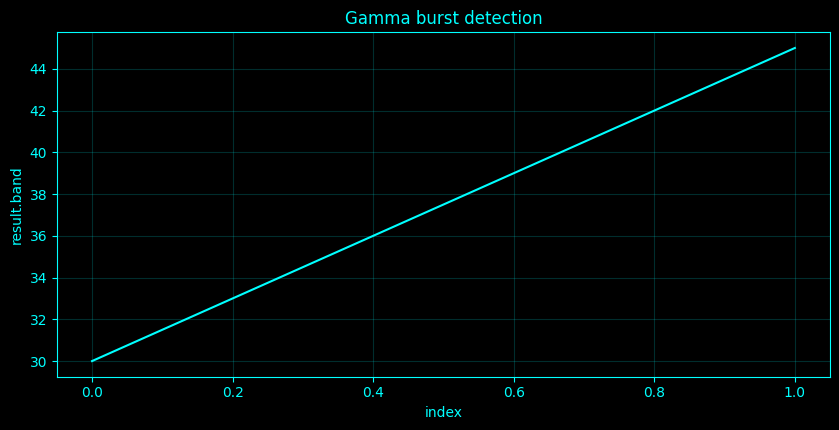

In [60]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_226():
    idx = 226
    name = 'Gamma burst detection'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_226,_plot_spec=_compute_method_226()
print('Gamma burst detection')
if isinstance(result_226,dict):
    for _k,_v in result_226.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_226)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_226)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Gamma burst detection',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Gamma burst detection',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Gamma burst detection',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">227. Burst rate by channel</h3>
<p>Burst rate is burst count divided by analyzed duration for each channel.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Burst rate by channel
  burst_rate_per_s: array(12,), mean=2.273


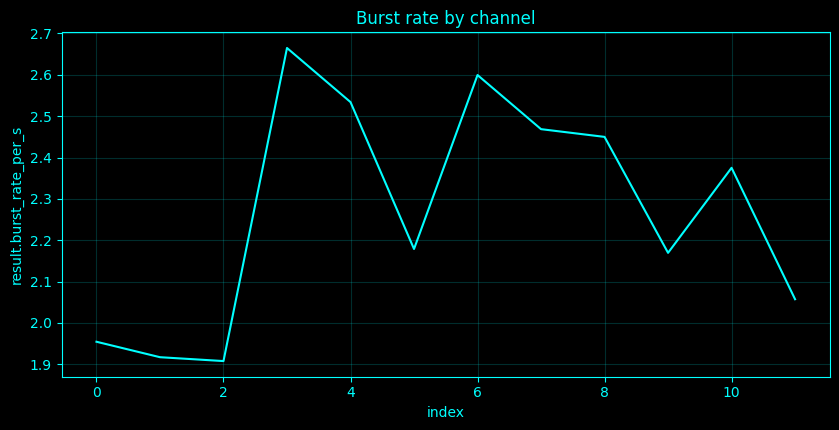

In [61]:
# Standalone spectral-theory implementation: all data preparation and mathematics used by this method are in this cell.
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal, linalg, stats, ndimage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.decomposition import PCA, NMF, FastICA, DictionaryLearning, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLasso
from sklearn.metrics import pairwise_distances
import networkx as nx

EPS=1e-12
BASE_DIR="/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_PATH=os.path.join(BASE_DIR,"eeg_data_with_channels.npy")
SAMPLING_RATE=1000.0
START_TIME,END_TIME=814.571,921.515
EEG_CHANNEL_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
ELECTRODE_XY={
    'Fp1':(-.45,1.00),'Fpz':(0,1.05),'Fp2':(.45,1.00),'F7':(-.95,.55),'F3':(-.45,.55),'Fz':(0,.60),'F4':(.45,.55),'F8':(.95,.55),
    'FC5':(-.70,.25),'FC1':(-.25,.25),'FC2':(.25,.25),'FC6':(.70,.25),'M1':(-1.10,0),'T7':(-.95,0),'C3':(-.45,0),'Cz':(0,0),'C4':(.45,0),'T8':(.95,0),'M2':(1.10,0),
    'CP5':(-.70,-.25),'CP1':(-.25,-.25),'CP2':(.25,-.25),'CP6':(.70,-.25),'P7':(-.95,-.55),'P3':(-.45,-.55),'Pz':(0,-.60),'P4':(.45,-.55),'P8':(.95,-.55),
    'POz':(0,-.82),'O1':(-.35,-1.00),'Oz':(0,-1.05),'O2':(.35,-1.00)}
LEFT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('1','3','5','7'))]
RIGHT=[c for c in EEG_CHANNEL_NAMES if c.endswith(('2','4','6','8'))]
ROI={'frontal':['Fp1','Fpz','Fp2','F3','Fz','F4'],'central':['C3','Cz','C4'],'posterior':['P3','Pz','P4','O1','Oz','O2']}
BANDS={'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,45)}
ACCENT,BG='#00FFFF','#000000'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}:
    raise ValueError('FAST_OPTION must be one of: full, balanced, fast, ultra')
_SPEED={
    'full':dict(down=1,max_samples=100000,max_channels=32,nperseg=2048,overlap=.75,n_windows=180,var_order=10,n_sur=80,graph_k=10,rank=8),
    'balanced':dict(down=2,max_samples=60000,max_channels=24,nperseg=1024,overlap=.70,n_windows=120,var_order=8,n_sur=40,graph_k=8,rank=6),
    'fast':dict(down=4,max_samples=30000,max_channels=16,nperseg=768,overlap=.65,n_windows=80,var_order=6,n_sur=20,graph_k=6,rank=5),
    'ultra':dict(down=8,max_samples=16000,max_channels=12,nperseg=512,overlap=.50,n_windows=48,var_order=5,n_sur=8,graph_k=5,rank=4)}[FAST_OPTION]
if 'SPECTRAL_DATA_OVERRIDE' in globals():
    _raw=np.asarray(globals()['SPECTRAL_DATA_OVERRIDE']);_fs0=float(globals().get('SPECTRAL_FS_OVERRIDE',SAMPLING_RATE))
else:
    _raw=np.asarray(np.load(EEG_PATH,allow_pickle=True));_fs0=SAMPLING_RATE
if _raw.ndim!=2: raise ValueError(f'Expected 2-D EEG array, got {_raw.shape}')
if _raw.shape[1]==len(EEG_CHANNEL_NAMES): pass
elif _raw.shape[0]==len(EEG_CHANNEL_NAMES) or (_raw.shape[0]<_raw.shape[1] and _raw.shape[0]<=64): _raw=_raw.T
if 'SPECTRAL_DATA_OVERRIDE' not in globals():
    _s0,_e0=int(START_TIME*_fs0),int(END_TIME*_fs0)
    if _e0<=_raw.shape[0]: _raw=_raw[_s0:_e0]
_names=EEG_CHANNEL_NAMES[:_raw.shape[1]]
_sel_ch=min(_SPEED['max_channels'],_raw.shape[1]);_raw=_raw[:,:_sel_ch];_names=_names[:_sel_ch]
_down=max(1,int(_SPEED['down']))
if _down>1: _raw=signal.resample_poly(_raw,1,_down,axis=0)
_fs=_fs0/_down
if _raw.shape[0]>_SPEED['max_samples']: _raw=_raw[:_SPEED['max_samples']]
X=signal.detrend(np.asarray(_raw,float),axis=0,type='constant')
X=(X-np.mean(X,axis=0,keepdims=True))/(np.std(X,axis=0,keepdims=True)+EPS)
N,C=X.shape;CH_NAMES=_names;SPEC_CACHE={}
_rng=np.random.default_rng(20260914)

# Mathematical definitions used by this method.
def _analytic_band(band):
    key = ('analytic', band)
    if key in SPEC_CACHE:
        return SPEC_CACHE[key]
    lo, hi = band
    hi = min(hi, 0.45 * _fs)
    sos = signal.butter(4, [lo / (0.5 * _fs), hi / (0.5 * _fs)], btype='bandpass', output='sos')
    A = signal.hilbert(signal.sosfiltfilt(sos, X, axis=0), axis=0)
    SPEC_CACHE[key] = A
    return A

def _burst_table(band=(13, 30)):
    A = _analytic_band(band)
    env = np.abs(A)
    rows = []
    min_len = max(1, int(0.05 * _fs))
    for j in range(C):
        th = np.quantile(env[:, j], 0.75)
        above = env[:, j] > th
        lab, nlab = ndimage.label(above)
        for k in range(1, nlab + 1):
            ii = np.where(lab == k)[0]
            if len(ii) >= min_len:
                peak = ii[np.argmax(env[ii, j])]
                rows.append((j, ii[0], ii[-1], peak, float(np.max(env[ii, j]))))
    return rows

# Method-specific calculation.
def _compute_method_227():
    idx = 227
    name = 'Burst rate by channel'
    __plot_spec = None
    band_by_idx = {223: BANDS['alpha'], 224: BANDS['beta'], 225: BANDS['theta'], 226: BANDS['gamma']}
    if idx in band_by_idx:
        rows = _burst_table(band_by_idx[idx])
        return ({'band': list(band_by_idx[idx]), 'bursts': len(rows)}, locals().get('__plot_spec', None))
    rows = _burst_table(BANDS['beta'])
    dur = N / _fs
    counts = np.zeros(C, int)
    for r in rows:
        counts[r[0]] += 1
    return ({'burst_rate_per_s': (counts / dur).tolist()}, locals().get('__plot_spec', None))
    peaks = np.array([r[3] for r in rows], int)
    half = int(0.5 * _fs)
    valid = [e for e in peaks if e - half >= 0 and e + half < N][:_SPEED['n_windows']]
    raise KeyError(f'Early spectral catalogue method {idx}: {name} has no implementation')

result_227,_plot_spec=_compute_method_227()
print('Burst rate by channel')
if isinstance(result_227,dict):
    for _k,_v in result_227.items():
        if np.isscalar(_v) or isinstance(_v,str): print(f"  {_k}: {_v}")
        else:
            try:
                _a=np.asarray(_v)
                if np.issubdtype(_a.dtype,np.number):
                    _r=np.real(_a);_ok=np.isfinite(_r);_mean=float(np.mean(_r[_ok])) if np.any(_ok) else np.nan
                    print(f"  {_k}: array{_a.shape}, mean={_mean:.6g}")
                else: print(f"  {_k}: {str(_v)[:160]}")
            except Exception: print(f"  {_k}: {str(_v)[:160]}")
else: print(result_227)

# Plot only when the result contains at least two finite numerical values.
_numeric_arrays=[];_scalar_labels=[];_scalar_values=[];_stack=[('result',result_227)]
while _stack:
    _key,_val=_stack.pop()
    if isinstance(_val,dict):
        _stack.extend((str(_key)+'.'+str(_k),_v) for _k,_v in _val.items());continue
    if isinstance(_val,(str,bytes)) or _val is None: continue
    if np.isscalar(_val):
        try:
            _z=complex(_val)
            if np.isfinite(_z.real) and np.isfinite(_z.imag):
                _scalar_labels.append(str(_key));_scalar_values.append(float(abs(_z) if abs(_z.imag)>0 else _z.real))
        except Exception: pass
        continue
    try:
        _a=np.asarray(_val)
        if np.issubdtype(_a.dtype,np.number):
            _b=np.abs(_a) if np.iscomplexobj(_a) else _a.astype(float)
            if np.sum(np.isfinite(_b))>0: _numeric_arrays.append((str(_key),_b))
        elif isinstance(_val,(list,tuple)):
            _stack.extend((f'{_key}[{_j}]',_vv) for _j,_vv in enumerate(_val))
    except Exception: pass
_numeric_count=len(_scalar_values)+sum(int(np.sum(np.isfinite(_a))) for _,_a in _numeric_arrays)
if _numeric_count>=2:
    _cm=LinearSegmentedColormap.from_list('black_cyan',[BG,ACCENT]);_shown=False
    if _plot_spec is not None:
        _kind,_pdata,_ptitle,_px,_pxlabel,_pylabel=_plot_spec
        _pdata=np.asarray(_pdata);_pdata=np.abs(_pdata) if np.iscomplexobj(_pdata) else np.asarray(_pdata,float)
        if np.sum(np.isfinite(_pdata))>=2:
            if _kind=='scalp':
                _xy=np.array([ELECTRODE_XY.get(_ch,(np.nan,np.nan)) for _ch in CH_NAMES],float);_vals=np.ravel(_pdata)
                _good=np.isfinite(_xy).all(1)&np.isfinite(_vals[:len(_xy)])
                if np.sum(_good)>=2:
                    _fig,_ax=plt.subplots(figsize=(5.2,4.8),facecolor=BG);_sc=_ax.scatter(_xy[_good,0],_xy[_good,1],c=_vals[:len(_xy)][_good],s=95,cmap=_cm)
                    _cb=_fig.colorbar(_sc,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT)
                    _th=np.linspace(0,2*np.pi,240);_ax.plot(1.15*np.cos(_th),1.15*np.sin(_th),color=ACCENT,lw=1.2);_ax.set_aspect('equal');_ax.set_xticks([]);_ax.set_yticks([]);_ax.set_title(_ptitle or 'Burst rate by channel',color=ACCENT);_ax.set_facecolor(BG)
                    for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                    _fig.tight_layout();plt.show();plt.close(_fig);_shown=True
            else:
                _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
                for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
                if _pdata.ndim==1:
                    _x=np.arange(len(_pdata)) if _px is None else np.asarray(_px);_ok=np.isfinite(_pdata)&np.isfinite(_x)
                    if np.sum(_ok)>=2: _ax.plot(_x[_ok],_pdata[_ok],color=ACCENT,lw=1.5);_shown=True
                else:
                    _m=np.squeeze(_pdata);_m=_m.reshape(_m.shape[0],-1) if _m.ndim>2 else _m
                    if _m.ndim==2 and np.sum(np.isfinite(_m))>=2:
                        _im=_ax.imshow(_m,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_shown=True
                _ax.set_title(_ptitle or 'Burst rate by channel',color=ACCENT);_ax.set_xlabel(_pxlabel,color=ACCENT);_ax.set_ylabel(_pylabel,color=ACCENT)
                if _shown: _fig.tight_layout();plt.show()
                plt.close(_fig)
    if not _shown:
        _candidate=None
        for _label,_arr in sorted(_numeric_arrays,key=lambda kv:np.asarray(kv[1]).size,reverse=True):
            if np.sum(np.isfinite(_arr))>=2: _candidate=(_label,np.squeeze(_arr));break
        _fig,_ax=plt.subplots(figsize=(8.5,4.4),facecolor=BG);_ax.set_facecolor(BG);_ax.tick_params(colors=ACCENT);_ax.grid(True,color=ACCENT,alpha=.18)
        for _sp in _ax.spines.values(): _sp.set_color(ACCENT)
        if _candidate is not None:
            _label,_arr=_candidate
            if _arr.ndim==1:
                _ok=np.isfinite(_arr);_ax.plot(np.arange(len(_arr))[_ok],_arr[_ok],color=ACCENT,lw=1.5);_ax.set_xlabel('index',color=ACCENT);_ax.set_ylabel(_label,color=ACCENT)
            else:
                if _arr.ndim>2: _arr=_arr.reshape(_arr.shape[0],-1)
                _im=_ax.imshow(_arr,aspect='auto',origin='lower',cmap=_cm,interpolation='nearest');_cb=_fig.colorbar(_im,ax=_ax);_cb.ax.tick_params(colors=ACCENT);_cb.outline.set_edgecolor(ACCENT);_ax.set_xlabel('column',color=ACCENT);_ax.set_ylabel('row',color=ACCENT)
        elif len(_scalar_values)>=2:
            _xx=np.arange(len(_scalar_values));_ax.bar(_xx,_scalar_values,color=ACCENT,edgecolor=ACCENT,alpha=.75);_ax.set_xticks(_xx);_ax.set_xticklabels(_scalar_labels,rotation=45,ha='right',fontsize=8);_ax.set_ylabel('value',color=ACCENT)
        _ax.set_title('Burst rate by channel',color=ACCENT);_fig.tight_layout();plt.show();plt.close(_fig)


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">228. Burst duration distribution</h3>
<p>Burst duration is \((n_{end}-n_{start}+1)/f_s\) for each contiguous detected burst.</p>
<p><b>Implementation.</b> The following cell applies this definition to the shared EEG data with the notebook's existing cyan-on-black visualization conventions and speed-mode controls.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>
